In [1]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy import interpolate
from scipy.signal import savgol_filter
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [1006]:
# Functions I am adding
import modin.pandas as mpd
import ray
import scipy.signal as signal
import statsmodels.api as sm
import umap

from scipy.fft import fft
from scipy.signal import periodogram
from scipy.stats import skew, kurtosis, entropy
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, acf
ray.init(ignore_reinit_error=True, num_cpus=os.cpu_count()-1)

2025-11-01 23:59:52,756	INFO worker.py:1718 -- Calling ray.init() again after it has already been called.


Python version:,3.11.11
Ray version:,2.46.0


# Read raw data

In [3]:
# Load label names    
label_names = loadmat('label_names.mat', squeeze_me=True)
activity_names_indexed = label_names['activity_names_indexed']

In [4]:
# Set constant variables
SAMPLE_RATE = 32
WINDOW_SIZE = 4 * 128
TIME_EXCLUDE = 2
CHUNK = 128
my_netid = "lol404"

# Loading and Processing Helper Functions
def load_label_info():
    """Load label names and create mapping from name→number."""
    label_data = loadmat("label_names.mat", squeeze_me=True)
    activity_names = label_data["activity_names_indexed"]
    mapping = {name: idx for idx, name in enumerate(activity_names, start=1)}
    return activity_names, mapping

def parse_filename(file_name, dir_name):
    """Extract user ID, file prefix, and activity name from filename."""
    substr = dir_name[dir_name.find("allData/") + 8:]
    prefix_cut = 11 + len(substr)
    if file_name.startswith("null"):
        activity_name = file_name[25:-prefix_cut]
    else:
        activity_name = file_name[36:-prefix_cut]
    file_common = file_name[:-(10)]
    return substr, file_common, activity_name

def load_accel_data(file_path):
    """Load and clean accelerometer data."""
    data = np.loadtxt(file_path, delimiter=",")
    ts = data[:, 0]
    dup_idx = np.where(ts[:-1] == ts[1:])[0]
    data = np.delete(data, dup_idx, axis=0)
    df = pd.DataFrame(data, columns=["ts", "accel_x", "accel_y", "accel_z"])
    df = df.sort_values("ts").interpolate(method="spline", order=2)
    return df

def load_baro_data(file_path, target_len):
    """Load, deduplicate, interpolate, and smooth barometer data."""
    bar_data = np.loadtxt(file_path, delimiter=",")
    ts_bar = bar_data[:, 0]
    dup_idx = np.where(ts_bar[:-1] == ts_bar[1:])[0]
    bar_data = np.delete(bar_data, dup_idx, axis=0)
    interp_idx = np.linspace(0, len(bar_data) - 1, target_len)
    interp_func = interp1d(np.arange(len(bar_data)), bar_data[:, 1],
                           kind="linear", fill_value="extrapolate")
    y_bar = interp_func(interp_idx)
    y_bar_smoothed = savgol_filter(y_bar, WINDOW_SIZE, 1, mode="nearest")
    return y_bar_smoothed

def trim_data(df, y_bar):
    """Trim first/last few seconds from both accel and barometer."""
    start = int(TIME_EXCLUDE * SAMPLE_RATE)
    end = -start if start > 0 else None
    df_trim = df.iloc[start:end]
    y_bar_trim = y_bar[start:end]
    return df_trim, y_bar_trim

def prepare_fixed_blocks(df_accel, y_bar, activity, user, label):
    """Ensure dataset is multiple of CHUNK=128 samples."""
    usable_len = CHUNK * (len(y_bar) // CHUNK)
    if usable_len <= 0:
        return pd.DataFrame()
    df_accel = df_accel.iloc[:usable_len].copy()
    df_accel["y_bar"] = y_bar[:usable_len]
    df_accel["activity"] = activity
    df_accel["user"] = user
    df_accel["label"] = label
    return df_accel

# Parallel Worker
@ray.remote
def process_file(file_name, dir_name, activity_names, mapping):
    """Process one accel file (and its matching pressure file)."""
    substr, file_common, activity_name = parse_filename(file_name, dir_name)
    if activity_name not in activity_names:
        return pd.DataFrame()
    accel_path = os.path.join(dir_name, file_name)
    baro_path = os.path.join(dir_name, file_common + "-pressure.txt")
    df_accel = load_accel_data(accel_path)
    y_bar = load_baro_data(baro_path, len(df_accel))
    df_accel, y_bar = trim_data(df_accel, y_bar)
    df_out = prepare_fixed_blocks(df_accel, y_bar,
                                  activity_name, substr, mapping[activity_name])
    return df_out

# Main per-user computation
def compute_raw_data_parallel(dir_name):
    """Parallelized raw data extraction for a single user directory."""
    activity_names, mapping = load_label_info()
    files = [f for f in os.listdir(dir_name) if f.endswith("-accel.txt")]
    tasks = [process_file.remote(f, dir_name, activity_names, mapping) for f in files]
    results = ray.get(tasks)
    if not results:
        return pd.DataFrame()
    return pd.concat(results, ignore_index=True)

# Iterate over all user directories
def build_full_dataset(base_dir):
    """Iterate over all user directories under 'allData/' and combine results."""
    col_names = ['ts', 'accel_x', 'accel_y', 'accel_z', 'y_bar', 'label', 'user', 'activity']
    df_raw = pd.DataFrame(columns=col_names)

    for data_dir_name in os.listdir(base_dir):
        user_path = os.path.join(base_dir, data_dir_name)
        if os.path.isdir(user_path) and not data_dir_name.startswith("."):
            print(f"Processing directory: {data_dir_name}")
            df_temp = compute_raw_data_parallel(user_path)

            # Only sort/append if non-empty and contains expected columns
            if not df_temp.empty and all(col in df_temp.columns for col in ['label', 'ts']):
                df_temp = df_temp.sort_values(by=['label', 'ts'], ignore_index=True)
                df_raw = pd.concat([df_raw, df_temp], ignore_index=True)
            else:
                print(f"⚠️ Skipping {data_dir_name}: no valid data found")

    return df_raw

# Main Pipeline
def compute_raw_data_parallel(dir_name):
    """Parallelized and modularized raw data extraction pipeline."""
    activity_names, mapping = load_label_info()
    files = [f for f in os.listdir(dir_name) if f.endswith("-accel.txt")]

    tasks = [
        process_file.remote(f, dir_name, activity_names, mapping)
        for f in files
    ]
    results = ray.get(tasks)
    return pd.concat(results, ignore_index=True)

In [9]:
# Run the full pipeline
data_dir = os.path.join(os.getcwd(), "allData")
df_raw = build_full_dataset(data_dir)

# Keep only the desired columns (and ensure order)
col_names_raw = ['ts', 'accel_x', 'accel_y', 'accel_z', 'y_bar', 'label', 'user', 'activity']
df_raw = df_raw[[col for col in col_names_raw if col in df_raw.columns]]

print(f"Final dataset shape: {df_raw.shape}")
df_raw

Processing directory: vbagdi
Processing directory: ahs264
Processing directory: cyt25
⚠️ Skipping cyt25: no valid data found
Processing directory: xl549
Processing directory: jl2855
Processing directory: xz278
Processing directory: johnsweeney
⚠️ Skipping johnsweeney: no valid data found
Processing directory: Grack
Processing directory: mmill
Processing directory: mrossman
Processing directory: cstewie
Processing directory: sutreja
Processing directory: s1n1
Processing directory: yinuoinno
Processing directory: jao57
⚠️ Skipping jao57: no valid data found
Processing directory: jude
Processing directory: aaleksanyan
Processing directory: yaw006
Processing directory: aks249
Processing directory: mmb289
Processing directory: av452
Processing directory: sp2333
Processing directory: nbw32
Processing directory: nk428
Processing directory: mlc299
Processing directory: cgp46
Processing directory: wh298
Processing directory: s3chowdhury
Processing directory: jps394
Processing directory: shrek16

,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.761522e+12,-0.443601,-0.537366,9.946635,1001.999464,1,vbagdi,Stationary
1,1.761522e+12,-0.381671,-0.494507,10.008340,1001.999263,1,vbagdi,Stationary
2,1.761522e+12,-0.415024,-0.532604,9.908663,1001.999056,1,vbagdi,Stationary
3,1.761522e+12,-0.395971,-0.513556,9.908663,1001.998843,1,vbagdi,Stationary
4,1.761522e+12,-0.386446,-0.513557,9.918155,1001.998624,1,vbagdi,Stationary
...,...,...,...,...,...,...,...,...
7091067,1.760986e+12,2.644069,-0.965504,7.988439,1004.050420,7,xichen,Elevator-down
7091068,1.760986e+12,2.654238,-0.922433,7.983055,1004.051759,7,xichen,Elevator-down
7091069,1.760986e+12,2.673979,-0.869791,8.021339,1004.053094,7,xichen,Elevator-down
7091070,1.760986e+12,2.674577,-0.816551,8.044670,1004.054423,7,xichen,Elevator-down


# Visualize raw data

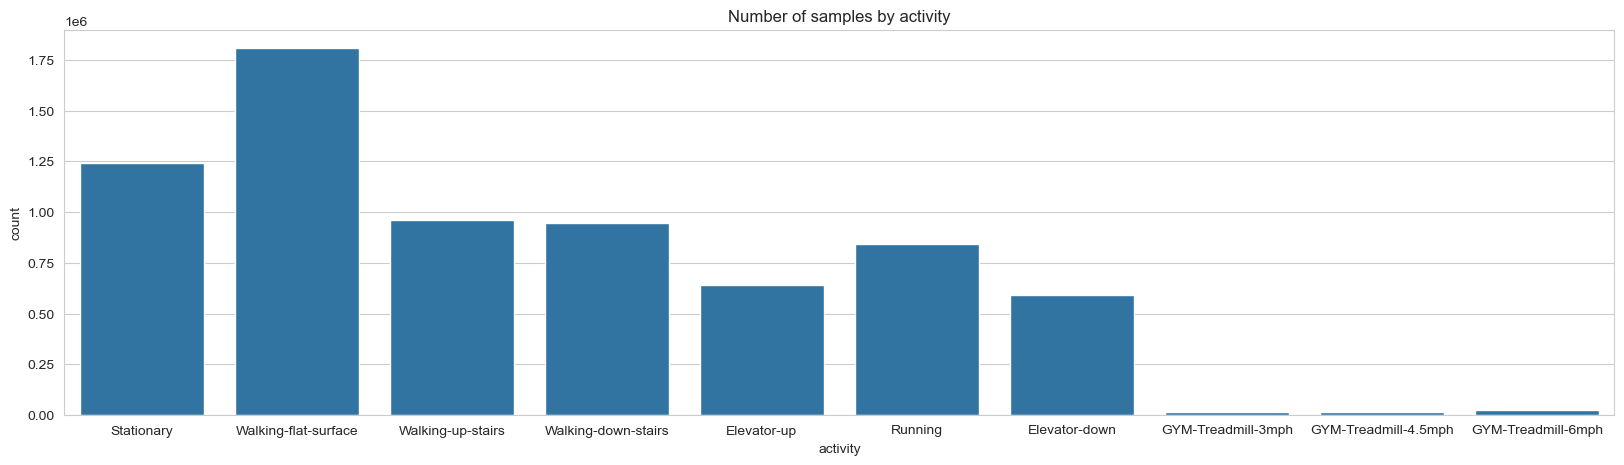

In [10]:
# Distribution of activities 
sns.set_style("whitegrid")
plt.figure(figsize = (20, 5))
sns.countplot(x = "activity", data = df_raw)
plt.title("Number of samples by activity")
plt.show()

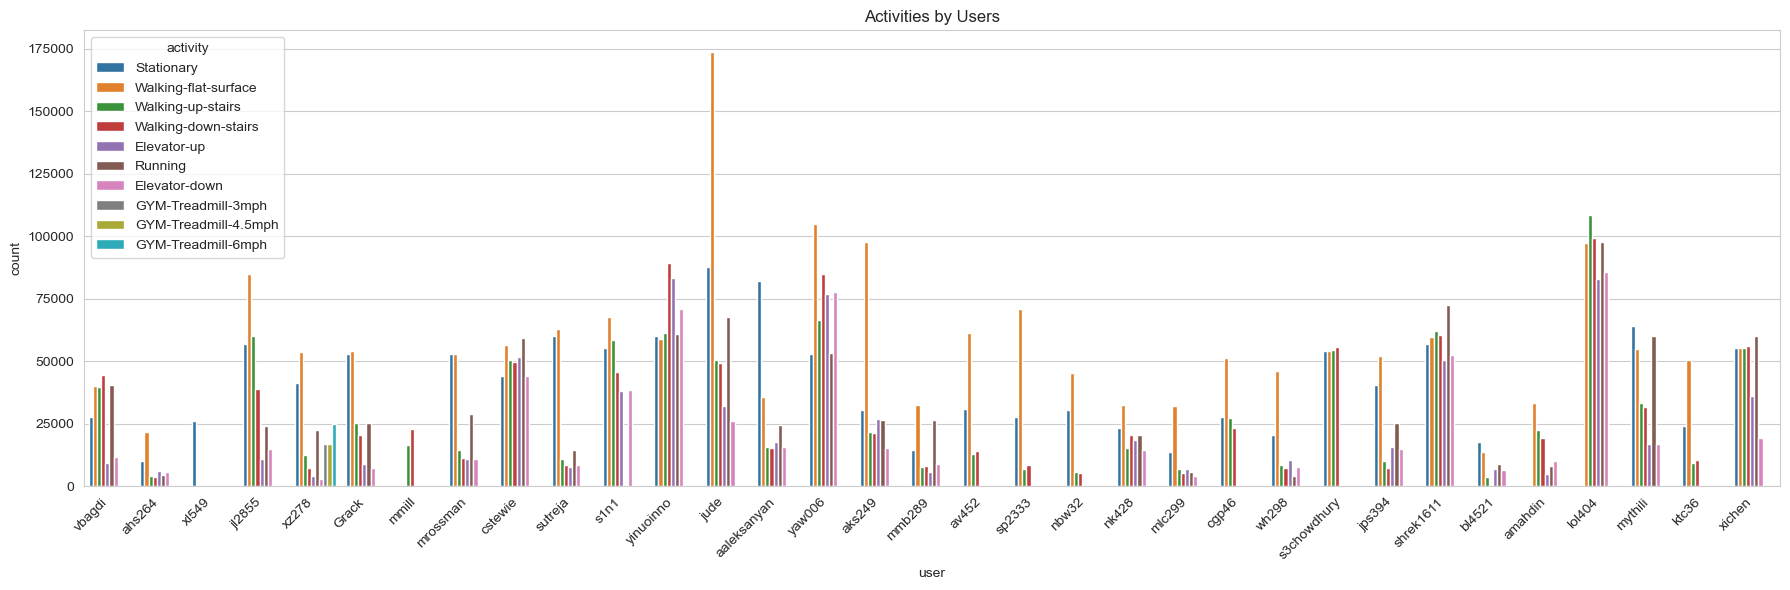

In [12]:
# Distribution of activities among different users
plt.figure(figsize=(18, 6))
sns.countplot(x="user", hue="activity", data=df_raw)
plt.title("Activities by Users")
plt.xticks(rotation=45, ha='right')  # 🔹 rotate labels and align right
plt.tight_layout()  # 🔹 adjust spacing to prevent cutoff
plt.show()

In [13]:
# splitting train data and test data 
df_train = df_raw[df_raw['user'] != my_netid]
df_test = df_raw[df_raw['user'] == my_netid]

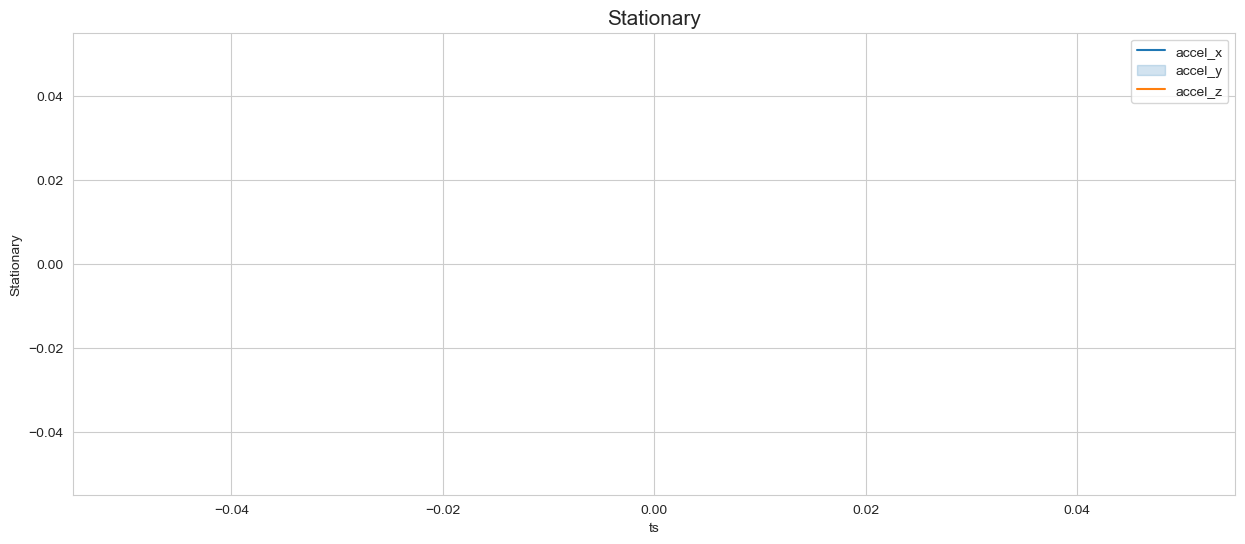

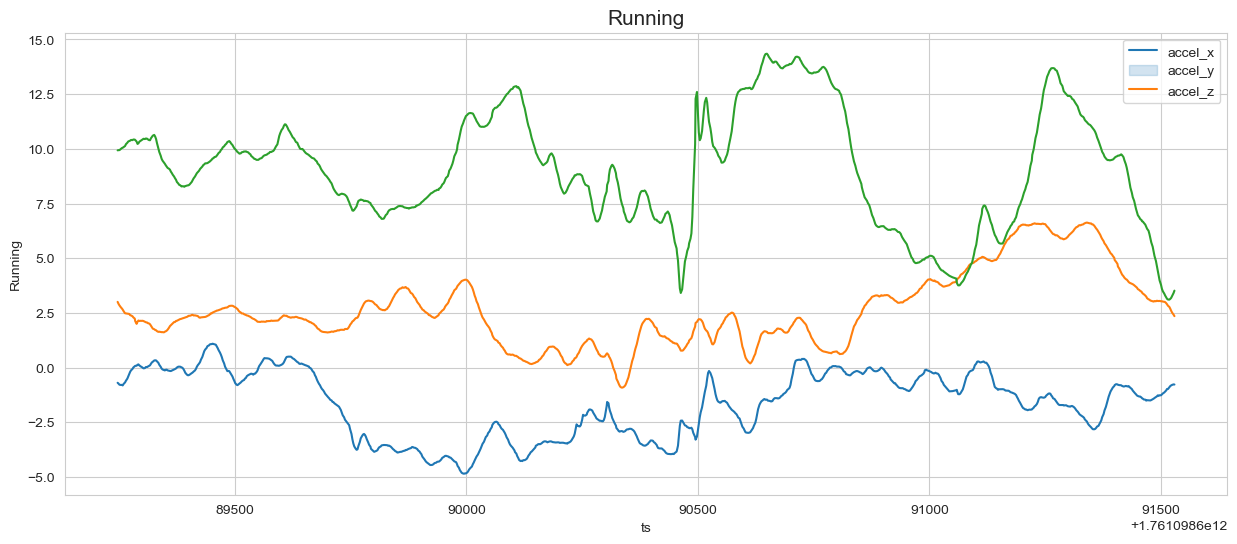

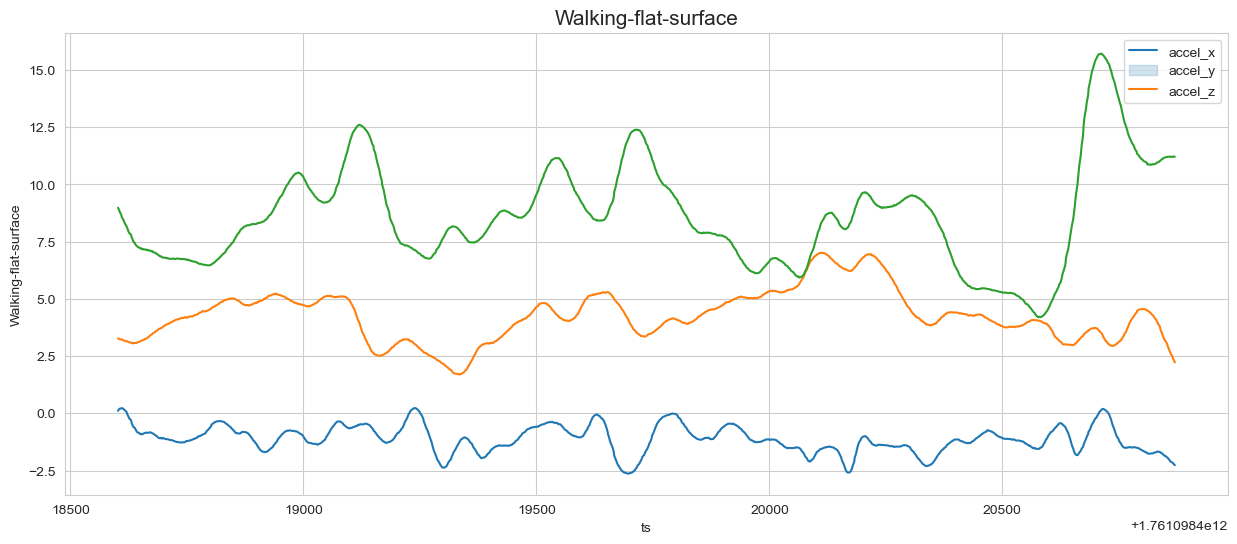

In [14]:
# Visual representation of raw data
# Note how the magnitudes and signal varies for each activity

for i in ["Stationary", "Running", "Walking-flat-surface"]:
    data_x = df_raw[(df_raw["user"] == my_netid) & (df_raw["activity"] == i)][:1000]
    plt.figure(figsize = (15, 6))
    sns.lineplot(y = "accel_x", x = "ts", data = data_x)
    sns.lineplot(y = "accel_y", x = "ts", data = data_x)
    sns.lineplot(y = "accel_z", x = "ts", data = data_x)
    plt.legend(["accel_x", "accel_y", "accel_z"])
    plt.ylabel(i)
    plt.title(i, fontsize = 15)
    plt.show()

In [389]:
# --- Build dataframes ---
df_train_windows = windows_to_dataframe(train_result)
df_test_windows = windows_to_dataframe(test_result)

# --- Combine into one master DataFrame ---
df_windows_all = pd.concat([df_train_windows, df_test_windows], ignore_index=True)

df_windows_all

,user,label,ts_start,ts_end,accel_x,accel_y,accel_z,y_bar,set
0,vbagdi,1,1.761522e+12,1.761522e+12,"[-0.4436013, -0.3816712, -0.41502357, -0.39597...","[-0.5373656, -0.4945072, -0.5326041, -0.513556...","[9.946635, 10.00834, 9.908663, 9.908663, 9.918...","[1001.9994642575144, 1001.9992632181882, 1001....",train
1,vbagdi,1,1.761522e+12,1.761522e+12,"[-0.45330125, -0.4151919, -0.4294876, -0.40567...","[-0.5611921, -0.54214406, -0.53262025, -0.5421...","[9.932384, 9.92289, 9.932384, 9.937129, 10.008...","[1001.9888634688094, 1001.988659832066, 1001.9...",train
2,vbagdi,1,1.761522e+12,1.761522e+12,"[-0.4296559, -0.37248993, -0.439191, -0.453486...","[-0.49930152, -0.5183501, -0.49454015, -0.5088...","[9.96085, 9.918132, 9.94661, 9.899144, 9.87541...","[1001.9767912092564, 1001.9765119436063, 1001....",train
3,vbagdi,1,1.761522e+12,1.761522e+12,"[-0.42029935, -0.45841578, -0.49176803, -0.434...","[-0.5517004, -0.58027315, -0.5802735, -0.56122...","[9.884893, 9.880146, 9.946598, 9.913371, 9.956...","[1001.9650532552037, 1001.9648426794869, 1001....",train
4,vbagdi,1,1.761522e+12,1.761522e+12,"[-0.45381987, -0.439531, -0.48717573, -0.47288...","[-0.53266823, -0.4802858, -0.4659999, -0.45647...","[9.870642, 9.894374, 9.941838, 9.956078, 9.965...","[1001.9547192782265, 1001.9545467688555, 1001....",train
...,...,...,...,...,...,...,...,...,...
141814,lol404,7,1.761099e+12,1.761099e+12,"[-3.0939198, -3.0987053, -3.0897322, -3.099303...","[5.580661, 5.580661, 5.5519466, 5.523233, 5.53...","[7.938189, 7.966903, 7.9908314, 8.014161, 8.00...","[1002.6069473070337, 1002.6061259618702, 1002....",test
141815,lol404,7,1.761099e+12,1.761099e+12,"[-3.3702908, -3.365505, -3.3559337, -3.3607194...","[5.54417, 5.54417, 5.548956, 5.5537415, 5.5489...","[7.2502527, 7.1694946, 7.0839515, 7.0414786, 7...","[1002.5729640392408, 1002.5723195531115, 1002....",test
141816,lol404,7,1.761099e+12,1.761099e+12,"[-4.3112683, -4.3208394, -4.330411, -4.325027,...","[5.7924256, 5.7924256, 5.8073807, 5.8217373, 5...","[6.7184477, 6.689734, 6.6514487, 6.613762, 6.5...","[1002.5517744701326, 1002.5518262533452, 1002....",test
141817,lol404,7,1.761099e+12,1.761099e+12,"[-3.964309, -3.9649072, -3.9511483, -3.955934,...","[5.8097734, 5.7762737, 5.761917, 5.757131, 5.7...","[6.7848487, 6.789634, 6.8039913, 6.8129644, 6....","[1002.5527393588654, 1002.552931790506, 1002.5...",test


In [ ]:
arma_stationarity_user(df_windows_all, activity_name="Walking-flat-surface", user_id=my_netid)


# Check ARMA assumptions

## Stationarity

### Visualize user process

In [ ]:
def plot_user_activity(df, user_id=None, activity_name="Walking-flat-surface", random=True):
    """
    Plot accel_x, accel_y, accel_z, and barometric pressure for a given user and activity.
    If random=True, picks a random user who performed that activity.
    
    Parameters:
        df (pd.DataFrame): The full dataset (df_raw)
        user_id (str): Specific user ID (ignored if random=True)
        activity_name (str): Activity name (e.g. 'Walking-flat-surface')
        random (bool): Whether to pick a random user instead of specifying one
    """
    # Pick random user if requested
    if random:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"Randomly selected user: {user_id}")

    # Filter
    df_user = df[(df["user"] == user_id) & (df["activity"] == activity_name)]

    # Extract signals
    accel_x = df_user["accel_x"].dropna().reset_index(drop=True)
    accel_y = df_user["accel_y"].dropna().reset_index(drop=True)
    accel_z = df_user["accel_z"].dropna().reset_index(drop=True)
    baro = df_user["y_bar"].dropna().reset_index(drop=True)

    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(accel_x, color='tab:blue')
    axes[0].set_title(f"Accel_x for {user_id} ({activity_name})")
    axes[0].set_ylabel("Accel X")

    axes[1].plot(accel_y, color='tab:orange')
    axes[1].set_title("Accel_y")
    axes[1].set_ylabel("Accel Y")

    axes[2].plot(accel_z, color='tab:green')
    axes[2].set_title("Accel_z")
    axes[2].set_ylabel("Accel Z")

    axes[3].plot(baro, color='tab:red')
    axes[3].set_title("Barometric Pressure")
    axes[3].set_xlabel("Time index")
    axes[3].set_ylabel("Pressure")

    plt.tight_layout()
    plt.show()

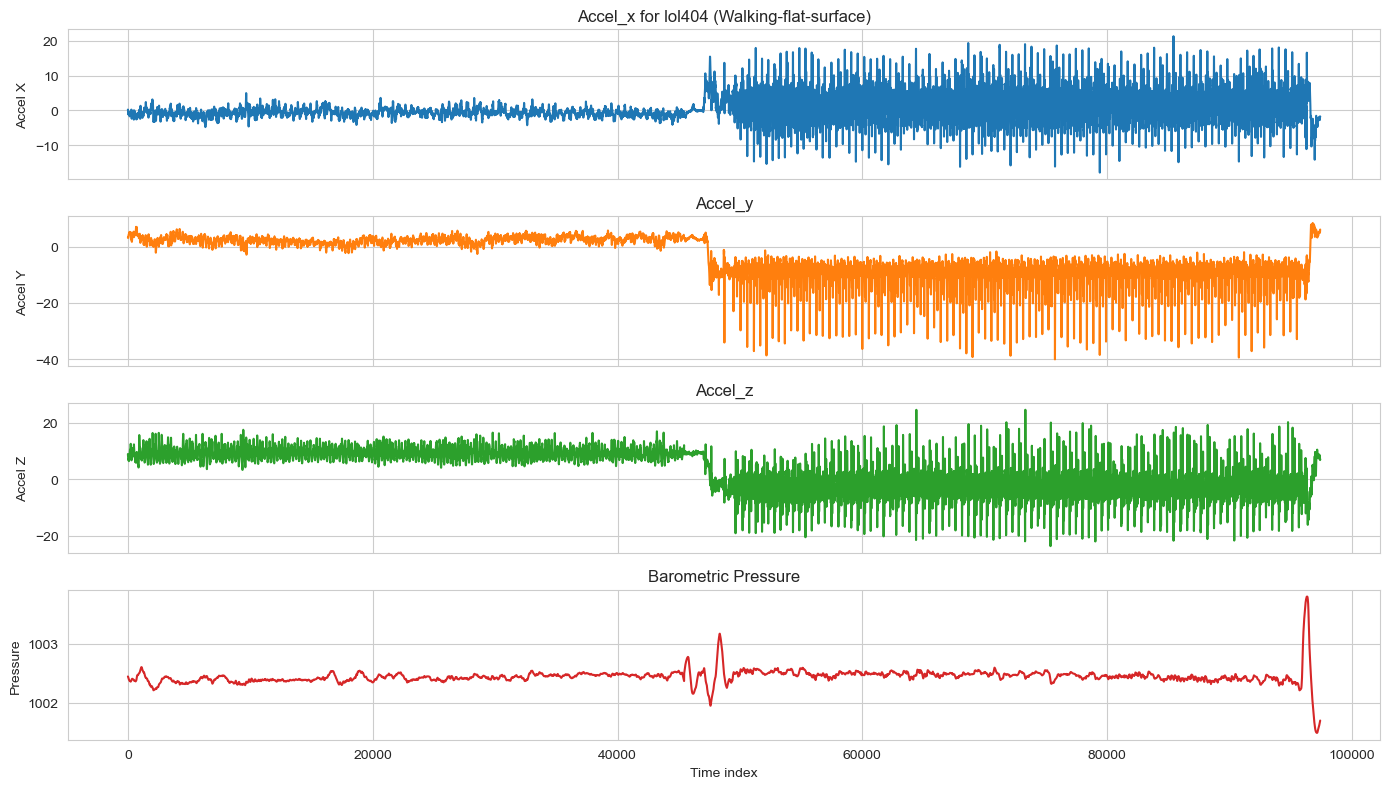

In [100]:
activity_walk = "Walking-flat-surface"
plot_user_activity(df_raw, my_netid, activity_walk, random = False)

🎲 Randomly selected user: cgp46


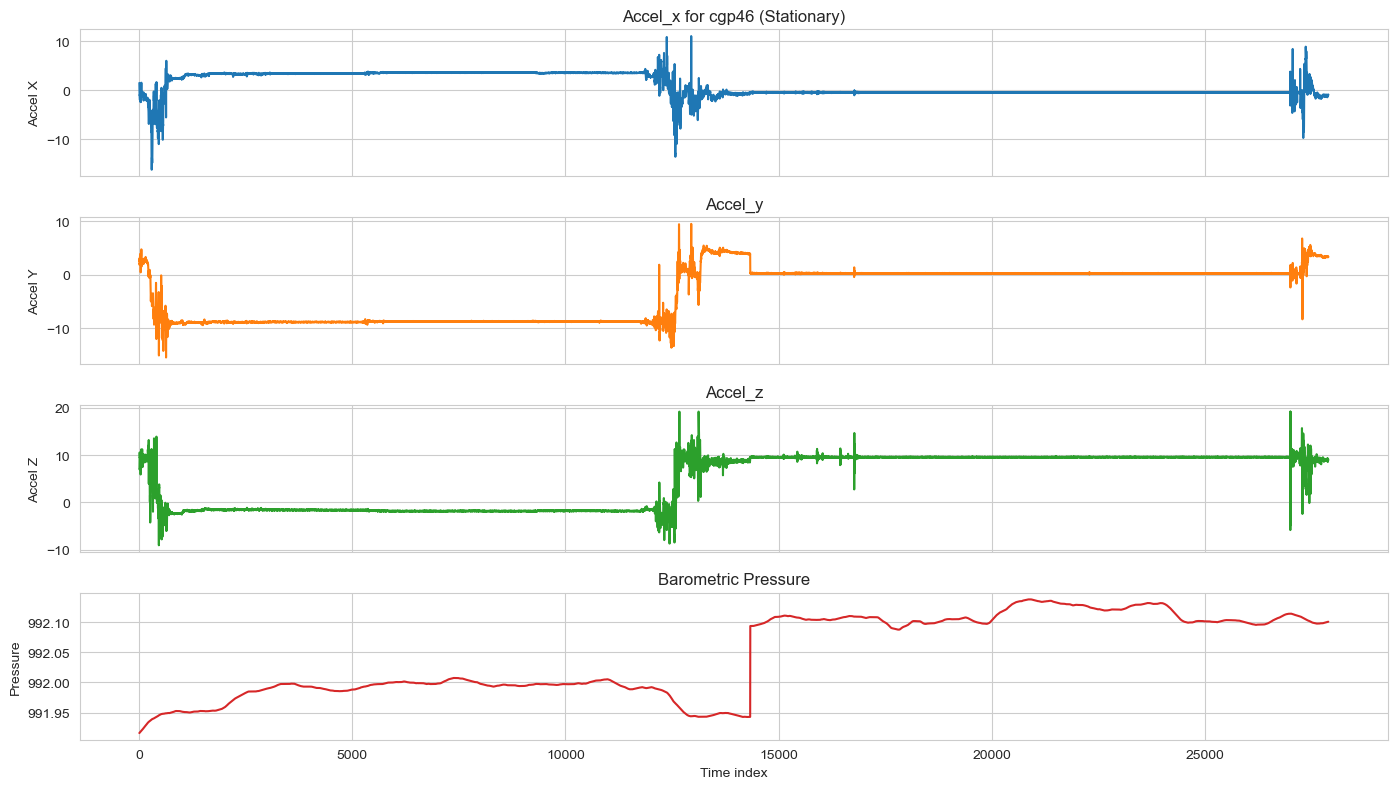

In [ ]:
plot_user_activity(df_raw, activity_walk, random=True)

🎲 Randomly selected user: ahs264


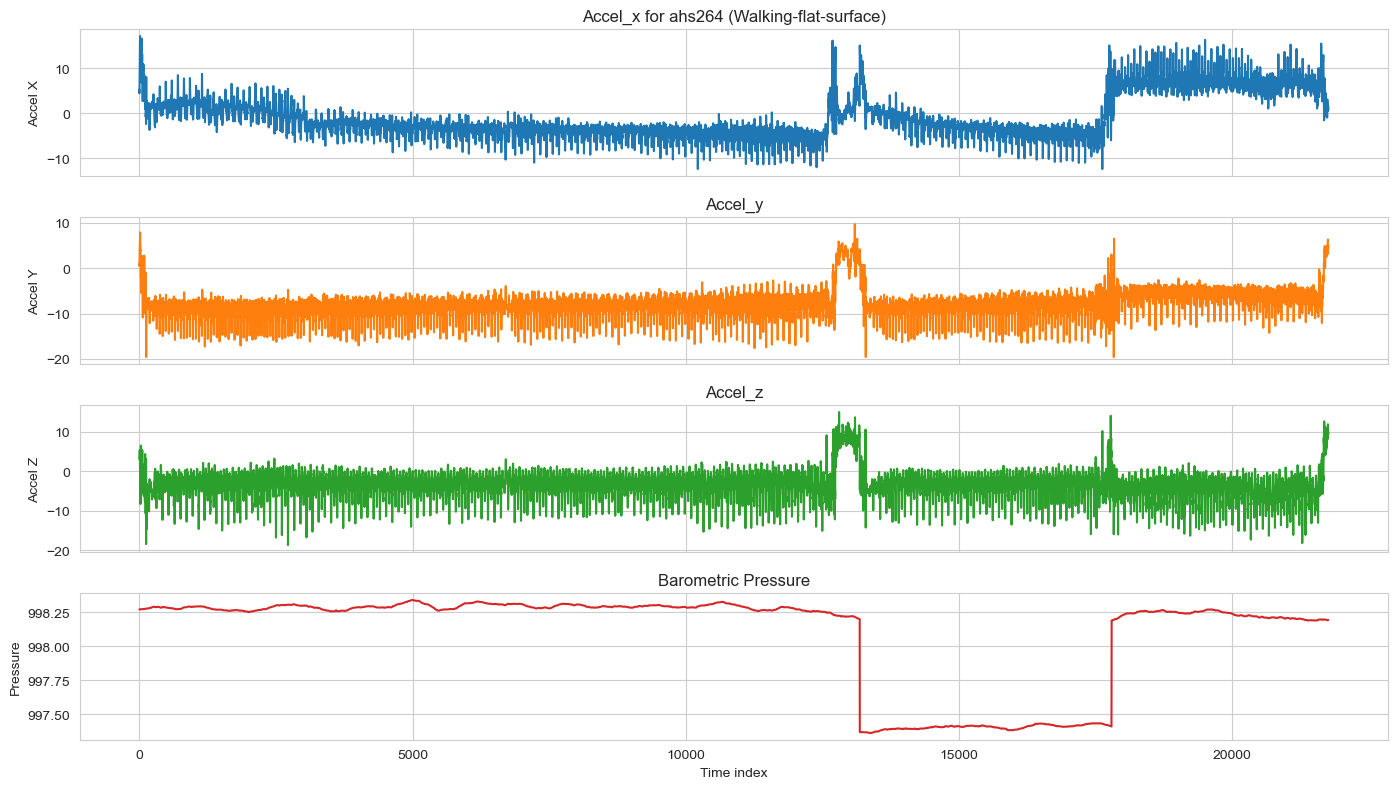

In [ ]:
plot_user_activity(df_raw, activity_walk, random=True)

# Processing

# Split by sessions and trim

In [721]:
# ===============================================================
# 1. Adaptive threshold calculation
# ===============================================================
def get_adaptive_gap_thresholds(df):
    """
    Build per-(user,activity) gap thresholds based on Δt.
    Caps to [100, 10000] ms (0.1–10 seconds).
    """
    summary = []
    for uid in df["user"].unique():
        for act in df["activity"].unique():
            d = df[(df["user"] == uid) & (df["activity"] == act)]
            if len(d) < 10:
                continue
            ts = d["ts"].astype(float).values
            dt = np.diff(ts)
            if len(dt) == 0:
                continue

            med = np.median(dt)
            max_dt = np.max(dt)
            thr = np.clip(50 * med, 100, 10000)  # 50× median capped 0.1–10 s
            summary.append({
                "user": uid,
                "activity": act,
                "median_dt": med,
                "max_dt": max_dt,
                "gap_threshold_ms": thr
            })

    thresholds = pd.DataFrame(summary)
    print(f"Adaptive thresholds for {len(thresholds)} user-activity pairs")
    return thresholds


# ===============================================================
# 2. Find sessions based on timestamp gaps
# ===============================================================
def find_sessions(df_user, gap_threshold_ms=5000):
    """Split into sessions based on large timestamp gaps."""
    df_user = df_user.sort_values("ts").reset_index(drop=True)
    ts = df_user["ts"].astype(float).values
    dt = np.diff(ts)

    cut_idx = np.where(dt > gap_threshold_ms)[0]
    starts = np.r_[0, cut_idx + 1]
    ends = np.r_[cut_idx + 1, len(df_user)]
    return list(zip(starts, ends))


# ===============================================================
# 3. Trim sessions (10% each side)
# ===============================================================
def trim_session(session_df, trim_frac=0.10):
    """Trim a fraction of samples off each side of one session."""
    n = len(session_df)
    if n < 200:
        return pd.DataFrame()

    start = int(n * trim_frac)
    end = int(n * (1 - trim_frac))
    trimmed = session_df.iloc[start:end].reset_index(drop=True)

    # Drop empty or all-NaN sessions
    if trimmed.empty or trimmed.isna().all().any():
        return pd.DataFrame()

    return trimmed


# ===============================================================
# 4. Ray worker: process one user/activity
# ===============================================================
@ray.remote
def process_user_activity(df, user_id, activity, threshold_map, trim_frac=0.10):
    d = df[(df["user"] == user_id) & (df["activity"] == activity)].copy()
    if d.empty:
        return pd.DataFrame()

    gap_thr = threshold_map.get((user_id, activity), 3000)
    session_ranges = find_sessions(d, gap_threshold_ms=gap_thr)
    if not session_ranges:
        return pd.DataFrame()

    all_sessions = []
    for i, (s, e) in enumerate(session_ranges, 1):
        seg = trim_session(d.iloc[s:e], trim_frac)
        if not seg.empty and len(seg) > 200:
            seg["session_id"] = f"{user_id}_{activity}_session{i}"
            all_sessions.append(seg)

    return pd.concat(all_sessions, ignore_index=True) if all_sessions else pd.DataFrame()


# ===============================================================
# 5. Combine across all users & activities
# ===============================================================
def split_and_trim_all_sessions(df, trim_frac=0.10):
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)

    thresholds_df = get_adaptive_gap_thresholds(df)
    threshold_map = {
        (r.user, r.activity): r.gap_threshold_ms
        for _, r in thresholds_df.iterrows()
    }

    all_users = df["user"].unique()
    all_activities = df["activity"].unique()

    tasks = [
        process_user_activity.remote(df, uid, act, threshold_map, trim_frac)
        for uid in all_users
        for act in all_activities
    ]

    results = ray.get(tasks)
    valid = [r for r in results if not r.empty and "session_id" in r.columns]

    if not valid:
        print("No valid sessions found.")
        return pd.DataFrame()

    df_combined = pd.concat(valid, ignore_index=True)
    df_combined = df_combined[df_combined["session_id"].notna()]
    df_combined = df_combined.groupby("session_id").filter(lambda x: len(x) > 200)

    print(f"Combined DataFrame: {len(df_combined)} samples, "
          f"{df_combined['session_id'].nunique()} sessions, "
          f"{df_combined['user'].nunique()} users, "
          f"{df_combined['activity'].nunique()} activities")

    return df_combined


In [722]:
df_trimmedSessions = split_and_trim_all_sessions(df_raw)
df_trimmedSessions

Adaptive thresholds for 201 user-activity pairs
Combined DataFrame: 5671614 samples, 499 sessions, 33 users, 10 activities


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity,session_id
0,1.761522e+12,-0.410129,-0.595393,9.893749,1001.991366,1,vbagdi,Stationary,vbagdi_Stationary_session1
1,1.761522e+12,-0.424429,-0.619204,9.960200,1001.991455,1,vbagdi,Stationary,vbagdi_Stationary_session1
2,1.761522e+12,-0.448254,-0.595394,9.912735,1001.991545,1,vbagdi,Stationary,vbagdi_Stationary_session1
3,1.761522e+12,-0.438729,-0.547774,9.884255,1001.991635,1,vbagdi,Stationary,vbagdi_Stationary_session1
4,1.761522e+12,-0.433973,-0.585871,9.907987,1001.991725,1,vbagdi,Stationary,vbagdi_Stationary_session1
...,...,...,...,...,...,...,...,...,...
5671609,1.760986e+12,2.286940,-9.455837,-0.574277,1004.803224,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671610,1.760986e+12,2.355136,-9.322437,-0.665803,1004.803822,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671611,1.760986e+12,2.401796,-9.395418,-0.736989,1004.804398,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671612,1.760986e+12,2.440081,-9.372088,-0.775274,1004.804954,7,xichen,Elevator-down,xichen_Elevator-down_session2


In [723]:
df_trimmedSessions.loc[
                        (df_trimmedSessions["user"] == "lol404") &
                        (df_trimmedSessions["activity"] == "Walking-flat-surface"),
                        "session_id"
].unique()

array(['lol404_Walking-flat-surface_session1',
       'lol404_Walking-flat-surface_session2'], dtype=object)

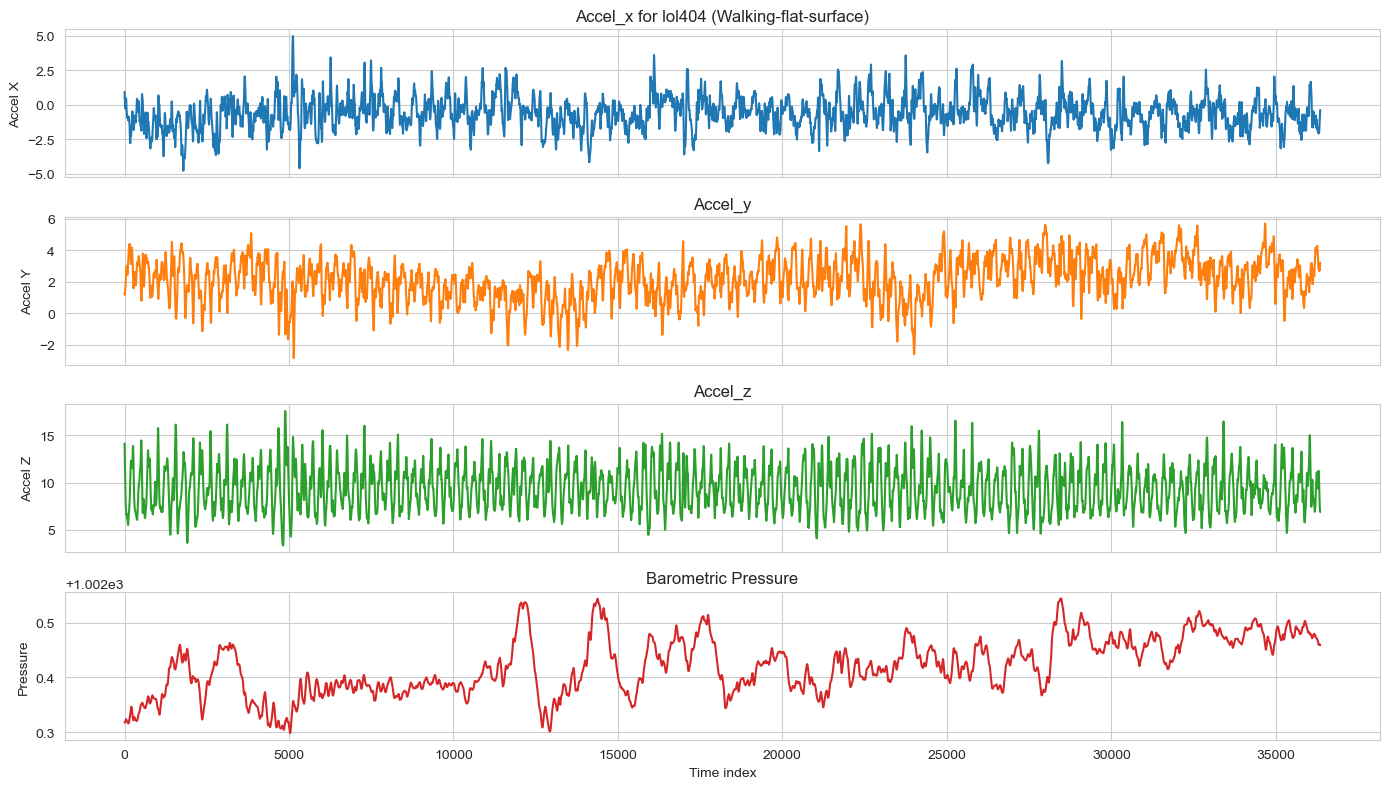

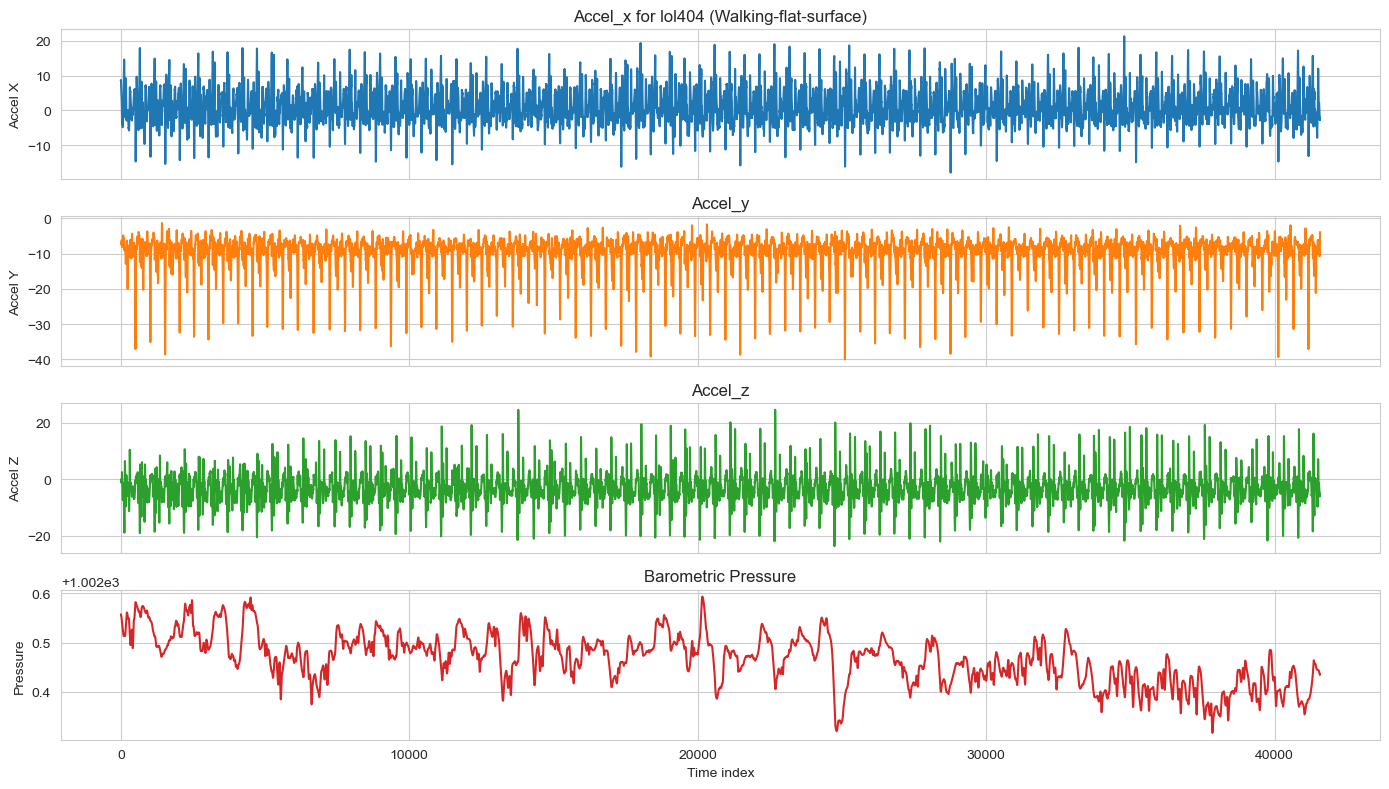

In [724]:
sessions = [s for s in df_trimmedSessions[df_trimmedSessions["user"]=="lol404"]["session_id"].unique()[:2]]
for s in sessions: plot_user_activity(df_trimmedSessions[df_trimmedSessions["session_id"]==s], "lol404", random=False)

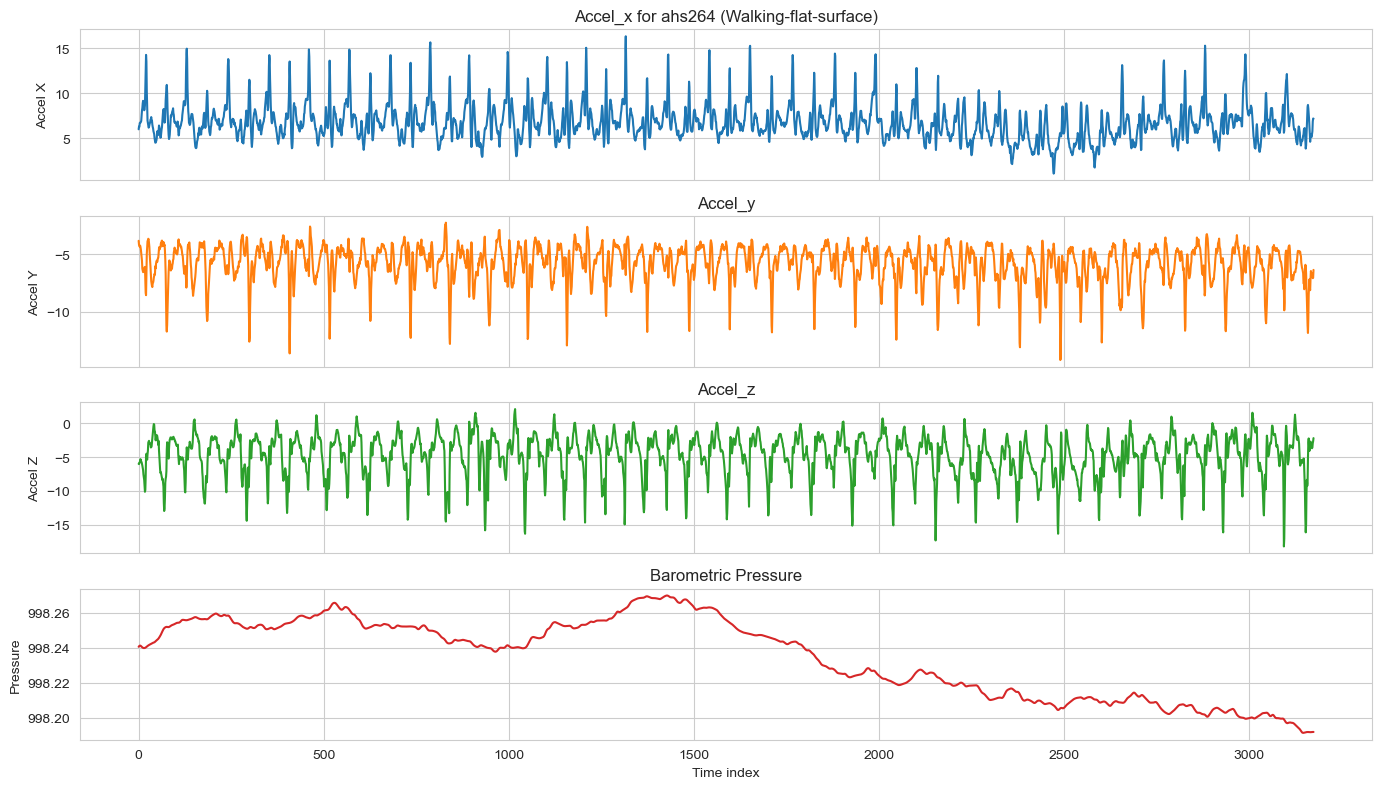

In [735]:
session_rand = np.random.choice(df_trimmedSessions["session_id"].unique())
df_rand = df_trimmedSessions[df_trimmedSessions["session_id"] == session_rand]
plot_user_activity(df_rand, user_id=df_rand["user"].iloc[0], random=False)

In [736]:
df_trimmedSessions["session_id"].nunique()

499

In [737]:
df_trimmedSessions["activity"].value_counts()

activity
Walking-flat-surface    1446646
Stationary               994158
Walking-up-stairs        767129
Walking-down-stairs      756722
Running                  673688
Elevator-up              512714
Elevator-down            473656
GYM-Treadmill-6mph        20071
GYM-Treadmill-3mph        13415
GYM-Treadmill-4.5mph      13415
Name: count, dtype: int64

In [738]:
def inspect_user_timestamps(df, user_id, activity):
    d = df[(df["user"] == user_id) & (df["activity"] == activity)].sort_values("ts")
    ts = d["ts"].astype(float).values
    dt = np.diff(ts)
    print(f"\nΔt summary for {user_id} – {activity}")
    print(pd.Series(dt).describe(percentiles=[.25, .5, .75, .9, .99]))
    print("Median:", np.median(dt), "ms")
    print("Max gap:", np.max(dt), "ms")
    return dt

dt_walk = inspect_user_timestamps(df_raw, "lol404", "Walking-flat-surface")


Δt summary for lol404 – Walking-flat-surface
count    97407.000000
mean         2.333415
std         23.164973
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
90%          3.000000
99%          3.000000
max       7230.000000
dtype: float64
Median: 2.0 ms
Max gap: 7230.0 ms


In [739]:
def inspect_all_timestamps(df):
    """Inspect Δt stats across all users & activities."""
    summary = []
    for uid in df["user"].unique():
        for act in df["activity"].unique():
            d = df[(df["user"] == uid) & (df["activity"] == act)]
            if len(d) < 10:
                continue
            ts = d["ts"].astype(float).values
            dt = np.diff(ts)
            if len(dt) == 0:
                continue

            summary.append({
                "user": uid,
                "activity": act,
                "count": len(dt),
                "median_dt": np.median(dt),
                "max_dt": np.max(dt),
                "mean_dt": np.mean(dt),
                "std_dt": np.std(dt)
            })

    df_summary = pd.DataFrame(summary)
    print(f"Summaries computed: {len(df_summary)} user-activity pairs")
    return df_summary
df_dt_summary = inspect_all_timestamps(df_raw)
df_dt_summary.sort_values("max_dt", ascending=False).head(15)


Summaries computed: 201 user-activity pairs


,user,activity,count,median_dt,max_dt,mean_dt,std_dt
17,jl2855,Walking-up-stairs,60159,5.0,231462944.0,3855.575176,9.436862e+05
18,jl2855,Walking-down-stairs,39039,5.0,231417016.0,5940.982530,1.171226e+06
16,jl2855,Walking-flat-surface,84863,5.0,231259584.0,2737.362820,7.938518e+05
15,jl2855,Stationary,56703,5.0,231215455.0,4110.533534,9.710016e+05
142,wh298,Walking-up-stairs,8447,10.0,179681851.0,21301.912277,1.954913e+06
140,wh298,Stationary,20607,10.0,179675569.0,8771.465861,1.251630e+06
143,wh298,Walking-down-stairs,7295,10.0,179558713.0,24631.348321,2.102152e+06
141,wh298,Walking-flat-surface,46207,10.0,179127950.0,3900.180709,8.333078e+05
22,xz278,Stationary,41215,7.0,20767480.0,511.365838,1.022941e+05
96,aks249,Stationary,30463,5.0,2660827.0,93.628402,1.524547e+04


In [788]:
def drop_short_or_flat_sessions(df, drop_percentile=0.4, min_std=0.01):
    """Drop the shortest X% and low-variance sessions dynamically."""
    before = df["session_id"].nunique()
    sensors = ["accel_x", "accel_y", "accel_z", "y_bar"]

    # compute session lengths
    session_lengths = df.groupby("session_id").size()
    length_threshold = np.percentile(session_lengths, drop_percentile * 100)

    print(f"Dropping sessions shorter than {int(length_threshold)} samples")

    def valid_session(x):
        if len(x) < length_threshold:
            return False
        if x.isna().all().any():
            return False
        return any(x[s].std(skipna=True) > min_std for s in sensors if s in x.columns)

    df = df.groupby("session_id").filter(valid_session)
    after = df["session_id"].nunique()
    print(f"Dropped {before - after} short or flat sessions ({after} remaining)")
    return df

In [789]:
df_trimmedSessionsCleaned = drop_empty_sessions(df_trimmedSessions)
df_trimmedSessionsCleaned

Dropped 12 short or flat sessions (487 remaining)


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity,session_id
0,1.761522e+12,-0.410129,-0.595393,9.893749,1001.991366,1,vbagdi,Stationary,vbagdi_Stationary_session1
1,1.761522e+12,-0.424429,-0.619204,9.960200,1001.991455,1,vbagdi,Stationary,vbagdi_Stationary_session1
2,1.761522e+12,-0.448254,-0.595394,9.912735,1001.991545,1,vbagdi,Stationary,vbagdi_Stationary_session1
3,1.761522e+12,-0.438729,-0.547774,9.884255,1001.991635,1,vbagdi,Stationary,vbagdi_Stationary_session1
4,1.761522e+12,-0.433973,-0.585871,9.907987,1001.991725,1,vbagdi,Stationary,vbagdi_Stationary_session1
...,...,...,...,...,...,...,...,...,...
5671609,1.760986e+12,2.286940,-9.455837,-0.574277,1004.803224,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671610,1.760986e+12,2.355136,-9.322437,-0.665803,1004.803822,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671611,1.760986e+12,2.401796,-9.395418,-0.736989,1004.804398,7,xichen,Elevator-down,xichen_Elevator-down_session2
5671612,1.760986e+12,2.440081,-9.372088,-0.775274,1004.804954,7,xichen,Elevator-down,xichen_Elevator-down_session2


In [813]:
bad_sessions = []
for sid, g in df_trimmedSessions.groupby("session_id"):
    if g["ts"].nunique() < 5 or g["accel_x"].std() < 1e-3:
        bad_sessions.append(sid)

print(f"{len(bad_sessions)} sessions with constant timestamps or nearly flat accel_x")

0 sessions with constant timestamps or nearly flat accel_x


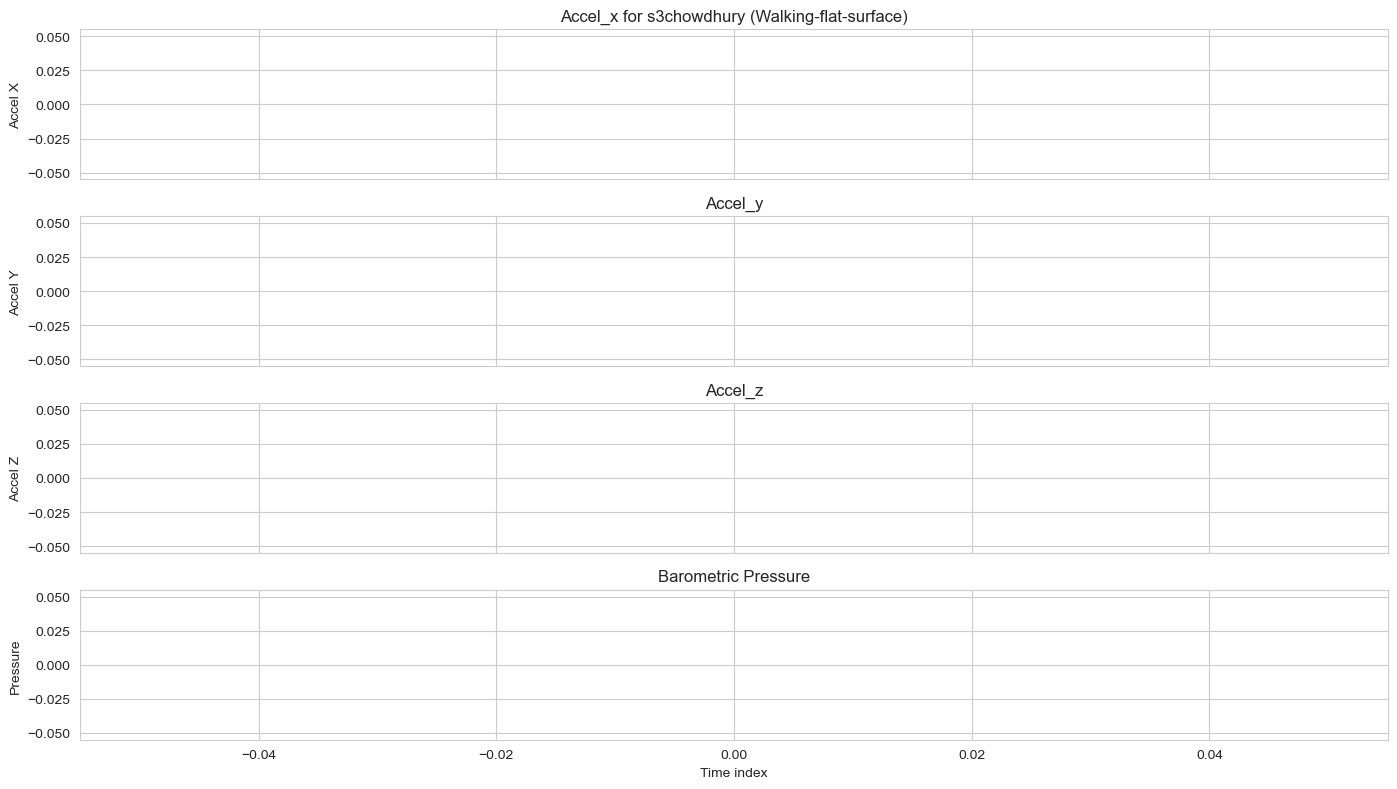

In [827]:
session_rand = np.random.choice(df_trimmedSessionsCleaned["session_id"].unique())
df_rand = df_trimmedSessionsCleaned[df_trimmedSessionsCleaned["session_id"] == session_rand]
plot_user_activity(df_rand, user_id=df_rand["user"].iloc[0], random=False)

In [814]:
session_lengths = df_trimmedSessions.groupby("session_id").size().sort_values()
print(session_lengths.describe(percentiles=[.1, .25, .5, .75, .9, .95]))

count       499.000000
mean      11365.959920
std       13389.528394
min         226.000000
10%        1945.000000
25%        3891.000000
50%        6041.000000
75%       13600.500000
90%       25896.200000
95%       43315.000000
max      138855.000000
dtype: float64


In [817]:
df_trimmedSessionsSnip= (
    df_trimmedSessions
    .groupby("session_id")
    .filter(lambda x: len(x) >= 300)
    .reset_index(drop=True)
)
print(f"Remaining: {df_trimmedSessionsSnip['session_id'].nunique()} sessions")
print(df_trimmedSessions.groupby("session_id").size().describe())


Remaining: 487 sessions
count       499.000000
mean      11365.959920
std       13389.528394
min         226.000000
25%        3891.000000
50%        6041.000000
75%       13600.500000
max      138855.000000
dtype: float64


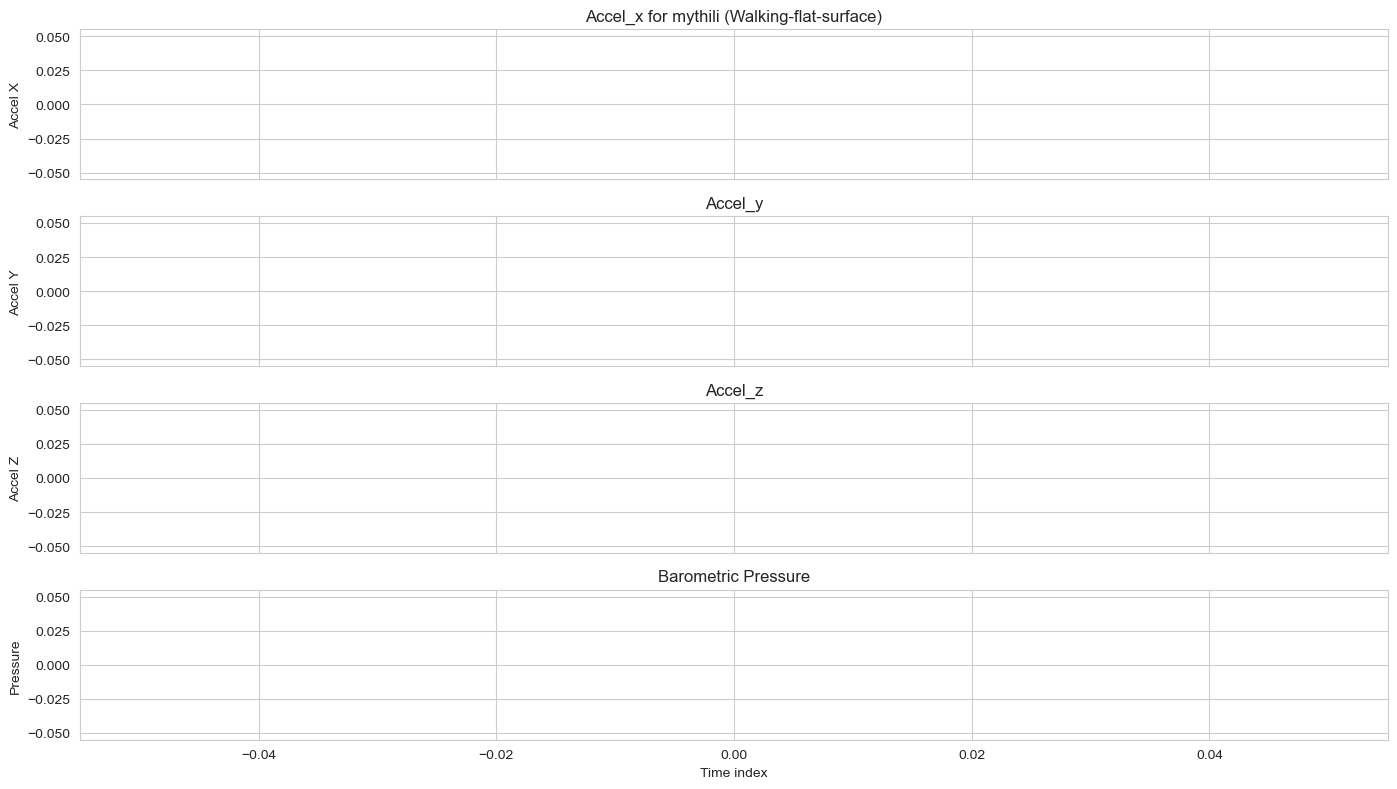

In [825]:
session_rand = np.random.choice(df_trimmedSessionsSnip["session_id"].unique())
df_rand = df_trimmedSessionsSnip[df_trimmedSessionsSnip["session_id"] == session_rand]
plot_user_activity(df_rand, user_id=df_rand["user"].iloc[0], random=False)

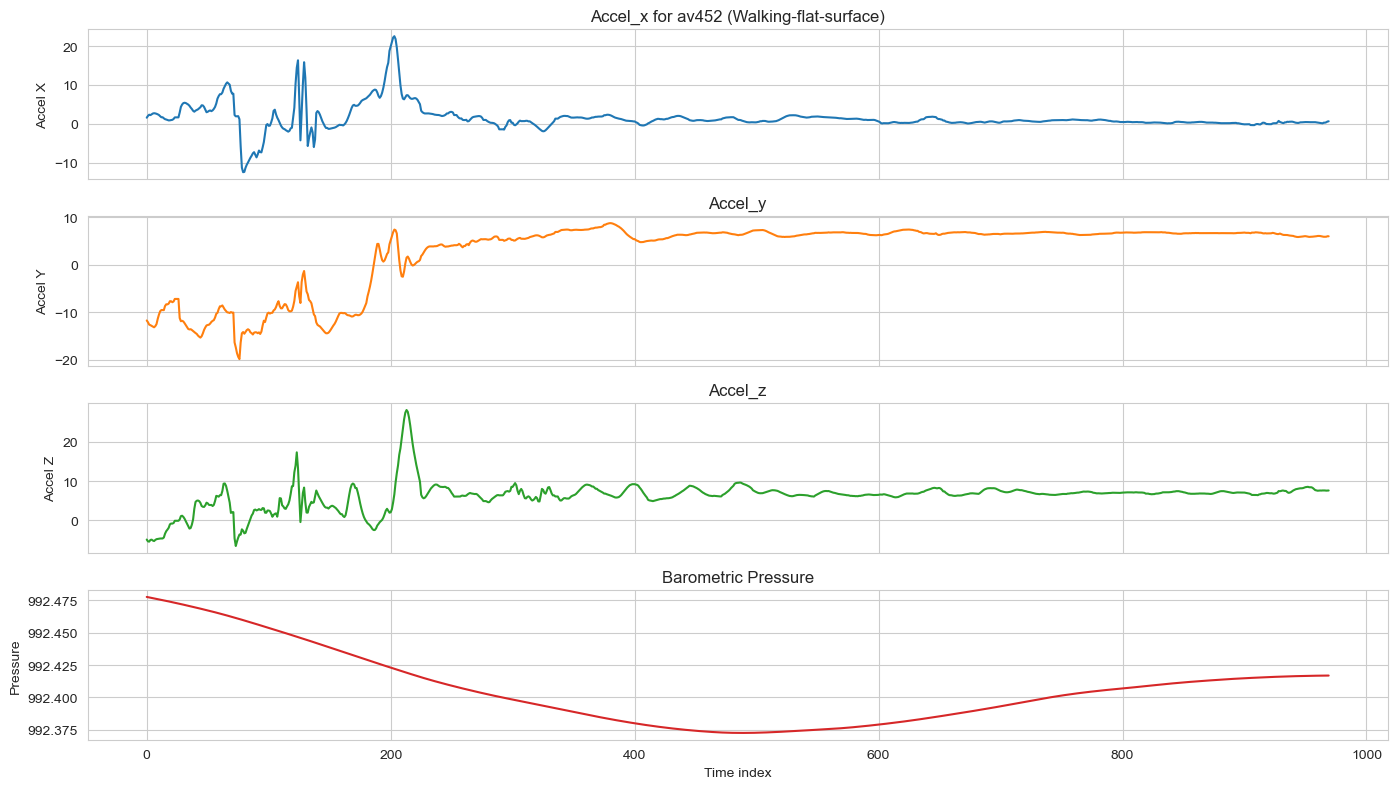

Randomly selected: Walking-flat-surface | av452_Walking-flat-surface_session3


In [894]:
# Choose a random activity
activity_rand = np.random.choice(df_trimmedSessions["activity"].unique())

# Choose a random session from that activity
sessions_in_activity = df_trimmedSessions.loc[
    df_trimmedSessions["activity"] == activity_rand, "session_id"
].unique()

session_rand = np.random.choice(sessions_in_activity)

# Extract and plot
df_rand = df_trimmedSessions[df_trimmedSessions["session_id"] == session_rand]
plot_user_activity(
    df_rand,
    user_id=df_rand["user"].iloc[0],
    activity_name=activity_rand,
    random=False
)

print(f"Randomly selected: {activity_rand} | {df_rand['session_id'].iloc[0]}")


# Windowing

In [895]:
# 1️⃣ Create overlapping windows (per session)
def create_overlapping_windows(df, window_size=100, step_size=50):
    """
    Create overlapping windows (with timestamps) for accel_x, accel_y, accel_z, y_bar.
    Works on trimmed sessions — keeps user, activity, and session_id context.
    """
    x_list, y_list, z_list, b_list = [], [], [], []
    labels, participants, timestamps, activities, sessions = [], [], [], [], []

    for i in range(0, df.shape[0] - window_size, step_size):
        window = df.iloc[i:i + window_size]

        # Core sensor arrays
        x_list.append(window['accel_x'].values)
        y_list.append(window['accel_y'].values)
        z_list.append(window['accel_z'].values)
        b_list.append(window['y_bar'].values)

        # Metadata
        timestamps.append((window['ts'].iloc[0], window['ts'].iloc[-1]))
        labels.append(window['label'].mode(dropna=True).iloc[0] if not window['label'].mode(dropna=True).empty else None)
        participants.append(window['user'].mode(dropna=True).iloc[0] if not window['user'].mode(dropna=True).empty else None)
        activities.append(window['activity'].mode(dropna=True).iloc[0] if not window['activity'].mode(dropna=True).empty else None)
        sessions.append(window['session_id'].mode(dropna=True).iloc[0] if 'session_id' in window.columns and not window['session_id'].mode(dropna=True).empty else None)

    return {
        "x": x_list, "y": y_list, "z": z_list, "b": b_list,
        "labels": labels, "participants": participants,
        "timestamps": timestamps, "activities": activities, "sessions": sessions
    }


# 2️⃣ Ray remote worker
@ray.remote
def make_windows_remote(df, window_size=100, step_size=50):
    return create_overlapping_windows(df, window_size, step_size)


# 3️⃣ Parallel window generation across all sessions
def generate_windows_all_sessions(df, window_size=100, step_size=50):
    """
    Generate overlapping windows for all sessions in parallel using Ray.
    Returns combined DataFrame of all windows.
    """
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)

    session_ids = df["session_id"].unique()
    tasks = [make_windows_remote.remote(df[df["session_id"] == sid], window_size, step_size)
             for sid in session_ids]

    results = ray.get(tasks)
    all_results = [r for r in results if len(r["x"]) > 0]

    # Combine into single DataFrame
    df_all = pd.concat([windows_to_dataframe(r) for r in all_results], ignore_index=True)
    print(f"✅ Generated {len(df_all)} windows from {len(session_ids)} sessions.")
    return df_all


# 4️⃣ Convert to structured DataFrame
def windows_to_dataframe(result_dict):
    """
    Convert windowed sensor data into a structured DataFrame for modeling or stationarity tests.
    """
    df = pd.DataFrame({
        "user": result_dict["participants"],
        "activity": result_dict["activities"],
        "session_id": result_dict["sessions"],
        "label": result_dict["labels"],
        "ts_start": [t[0] for t in result_dict["timestamps"]],
        "ts_end": [t[1] for t in result_dict["timestamps"]],
        "accel_x": result_dict["x"],
        "accel_y": result_dict["y"],
        "accel_z": result_dict["z"],
        "y_bar": result_dict["b"],
    })
    return df

In [896]:
df_windows = generate_windows_all_sessions(df_trimmedSessions, window_size=100, step_size=50)
df_windows

✅ Generated 112685 windows from 499 sessions.
(112685, 10)


,user,activity,session_id,label,ts_start,ts_end,accel_x,accel_y,accel_z,y_bar
0,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.41012898, -0.42442918, -0.4482537, -0.4387...","[-0.59539276, -0.6192039, -0.59539396, -0.5477...","[9.893749, 9.9602, 9.912735, 9.884255, 9.90798...","[1001.991366052565, 1001.9914551359675, 1001.9..."
1,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.49138388, -0.45327488, -0.46757117, -0.453...","[-0.5620831, -0.5858938, -0.571608, -0.6097048...","[9.9744215, 9.926955, 9.917462, 9.950687, 9.92...","[1001.9945016363172, 1001.9945955960554, 1001...."
2,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.43917343, -0.4963468, -0.4344172, -0.44394...","[-0.62877035, -0.5668639, -0.5621022, -0.55257...","[9.941181, 9.88897, 9.898462, 9.96966, 10.0028...","[1001.9990209678789, 1001.9991344709576, 1001...."
3,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.46320048, -0.45844033, -0.43462363, -0.425...","[-0.6145036, -0.62402815, -0.51926285, -0.5716...","[9.874716, 9.903194, 9.926927, 9.960152, 9.912...","[1002.0028448795376, 1002.002887665007, 1002.0..."
4,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.51043534, -0.5104379, -0.48185563, -0.4913...","[-0.5430344, -0.57160705, -0.5668452, -0.53351...","[9.888985, 9.888985, 9.92221, 9.893729, 9.9317...","[1002.0050782423136, 1002.0051123518765, 1002...."
...,...,...,...,...,...,...,...,...,...,...
112680,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.641078, 2.6464617, 2.6799614, 2.7038896, 2....","[-9.415757, -9.410972, -9.387043, -9.387043, -...","[-0.20279172, -0.13100705, -0.083748795, -0.02...","[1004.4823946348376, 1004.482649566673, 1004.4..."
112681,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[5.5262237, 6.1944194, 6.1770716, 5.624928, 4....","[-9.863813, -9.635299, -9.369097, -9.134601, -...","[2.324029, 1.2903296, 0.401396, -0.36729828, -...","[1004.5333368729985, 1004.5343228713247, 1004...."
112682,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.5674987, 2.772085, 3.0921252, 2.7625136, 2....","[-9.714262, -9.058628, -7.9908314, -8.016554, ...","[0.6628119, 1.1659029, 1.8005991, 1.6151553, 1...","[1004.5673750930287, 1004.5677514785841, 1004...."
112683,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.7511477, 2.7469604, 2.742773, 2.7332017, 2....","[-9.809975, -9.785448, -9.812965, -9.807582, -...","[-0.12023934, 0.19501504, 0.50069815, 0.681954...","[1004.5872392553915, 1004.5892310460314, 1004...."


🎲 Random window from aks249 | Walking-flat-surface | aks249_Walking-flat-surface_session2


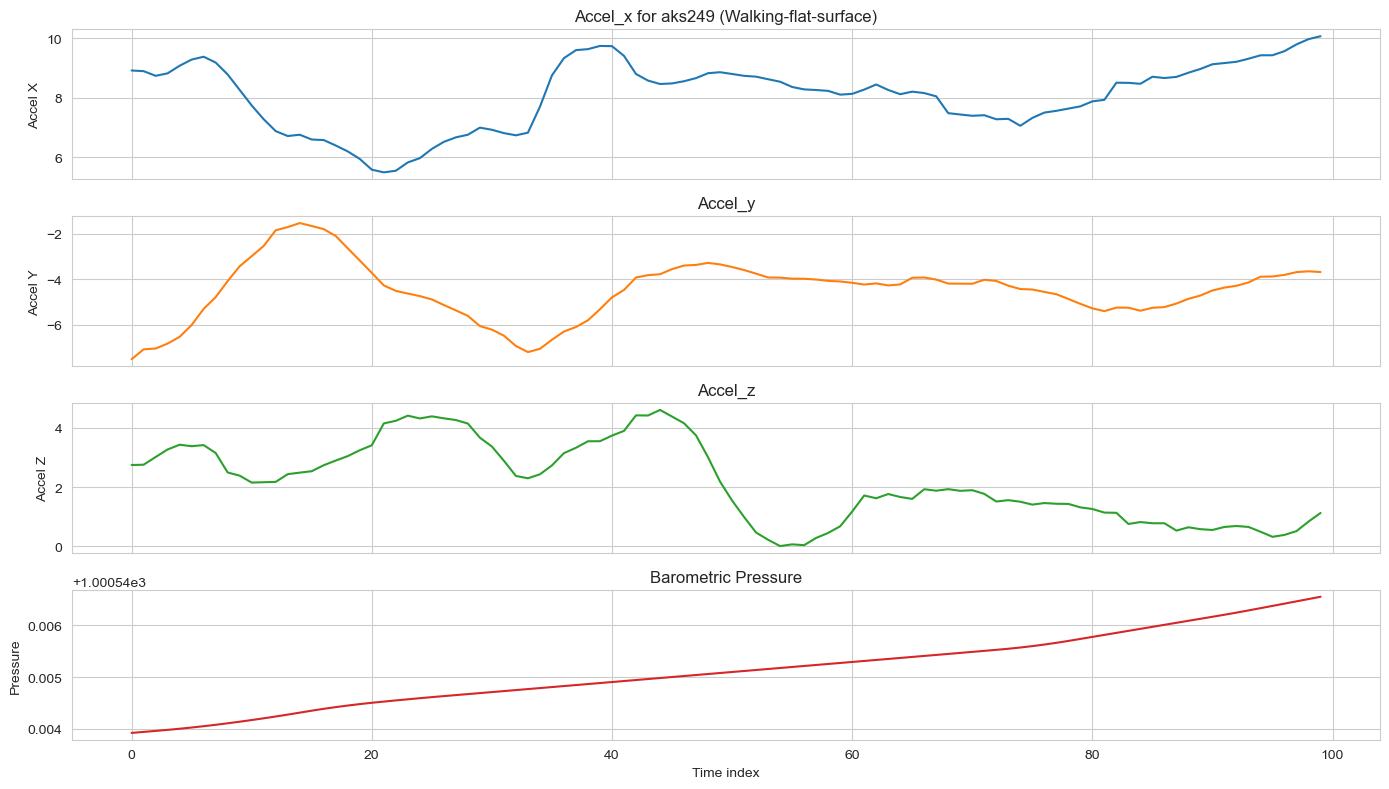

In [924]:
# Pick a random window
window_rand = df_windows.sample(1).iloc[0]

# Extract metadata
user_rand = window_rand["user"]
activity_rand = window_rand["activity"]
session_rand = window_rand["session_id"]

print(f"🎲 Random window from {user_rand} | {activity_rand} | {session_rand}")

# Rebuild it into a DataFrame with same structure as your plotting function expects
df_window = pd.DataFrame({
    "ts": np.linspace(window_rand["ts_start"], window_rand["ts_end"], len(window_rand["accel_x"])),
    "accel_x": window_rand["accel_x"],
    "accel_y": window_rand["accel_y"],
    "accel_z": window_rand["accel_z"],
    "y_bar": window_rand["y_bar"],
    "user": user_rand,
    "activity": activity_rand,
    "session_id": session_rand
})

# Plot using your existing function
plot_user_activity(df_window, user_id=user_rand, random=False)

# Stationarity tests

In [222]:
# Automatically compute lags farom number of samples and sample rate
def choose_lags(n_samples, sample_rate=32, seconds=2):
    """Compute recommended number of lags based on sample count and time horizon."""
    lags_boxjenkins = int(10 * np.log10(n_samples))
    lags_physical = int(seconds * sample_rate)
    return max(lags_boxjenkins, lags_physical)

# Visual method – choose p by ACF
def plot_acf_(series, sig_name, lags=20):
    """Plot ACF to visually inspect AR order p."""
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_acf(series, lags=lags, ax=ax)
    ax.set_title(f"{sig_name} ACF")
    plt.show()

#  Pure Brockwell root condition 
def brockwell_root_condition(phi):
    """
    Apply Brockwell & Davis (Ch.3) stationarity condition:
    Given AR coefficients φ₁...φ_p, check if all roots of
    1 - φ₁z - ... - φ_p z^p = 0 satisfy |z| > 1.
    """
    phi = np.asarray(phi, float)
    coeffs = np.concatenate(([1], -phi))
    roots = np.roots(coeffs)
    moduli = np.abs(roots)
    stationary = np.all(moduli > 1)

    print(f"φ = {np.round(phi, 4)}")
    for i, (r, m) in enumerate(zip(roots, moduli), 1):
        print(f"  Root {i}: {r:.4f} | |z|={m:.4f}")
    print("✅ Stationary" if stationary else "⚠️ Non-stationary")

    return {"phi": phi, "roots": roots, "moduli": moduli, "stationary": stationary}

#Estimate φ̂ from data if not provided
def estimate_phi_from_data(series, p=2):
    """Estimate AR(p) coefficients from data using least squares."""
    series = np.asarray(series, float)
    model = AutoReg(series, lags=p).fit()
    phi = model.params[1:]  # skip intercept
    print(f"Estimated φ̂ = {np.round(phi, 4)}")
    return phi

# Main Function: Run Brockwell test per user/activity/signal
def arma_stationarity_user(df, activity_name="Walking-flat-surface",
                           user_id=None, random=True, p=2,
                           phi_dict=None, sample_rate=32, seconds=2):
    """
    Test for accel_x, accel_y, accel_z, and y_bar.
    - If phi_dict is provided, uses those φ values directly (no fitting).
    - Otherwise, estimates φ̂ from data (least squares) for each signal.
    - Automatically determines lags from sample count and sampling rate.
    """
    # Pick user
    if random or user_id is None:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"🎲 Randomly selected user: {user_id}")
    else:
        print(f"👤 Using specified user: {user_id}")

    results = {}
    for sig in ["accel_x", "accel_y", "accel_z", "y_bar"]:
        series = df[(df["user"] == user_id) &
                    (df["activity"] == activity_name)][sig].dropna()

        if len(series) < p + 5:
            print(f"⚠️ Not enough data for {sig}")
            continue

        # Automatically choose number of lags
        lags = choose_lags(len(series), sample_rate=sample_rate, seconds=seconds)
        print(f"\n📈 ACF for {sig.upper()} | {lags} lags (auto)")

        # Plot ACF
        plot_acf_(series, sig_name=sig, lags=lags)

        # Estimate or use provided φ
        if phi_dict and sig in phi_dict:
            phi = phi_dict[sig]
            print(f"\n📘 {sig.upper()} | Using provided φ = {phi} | User: {user_id}")
        else:
            print(f"\n📘 {sig.upper()} | Estimating φ̂ | AR({p}) | User: {user_id}")
            phi = estimate_phi_from_data(series, p=p)

        # Brockwell root condition
        results[sig] = brockwell_root_condition(phi)

    return results

## Test one window of at a time

In [931]:
def arma_stationarity_random_window(df_windows, p=2, sample_rate=32, seconds=2):
    """
    Pick a random window and use the existing arma_stationarity_user() 
    to print φ estimates, ACFs, and full Brockwell root output.
    """
    # Randomly select one window
    win = df_windows.sample(1).iloc[0]
    activity = win["activity"]

    # Build temp df for arma_stationarity_user
    df_tmp = pd.DataFrame({
        "ts": np.linspace(win["ts_start"], win["ts_end"], len(win["accel_x"])),
        "accel_x": win["accel_x"],
        "accel_y": win["accel_y"],
        "accel_z": win["accel_z"],
        "y_bar": win["y_bar"],
        "user": win["user"],
        "activity": activity
    })

    # Force arma_stationarity_user() to pick a random user from the same activity
    print(f"\n🎲 Random window selected from activity: {activity}")
    results = arma_stationarity_user(
        df_tmp,
        activity_name=activity,
        user_id=None,   # forces random user selection + prints "Randomly selected user"
        random=True,
        p=p,
        sample_rate=sample_rate,
        seconds=seconds
    )

    return results


🎲 Random window selected from activity: Elevator-up
🎲 Randomly selected user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


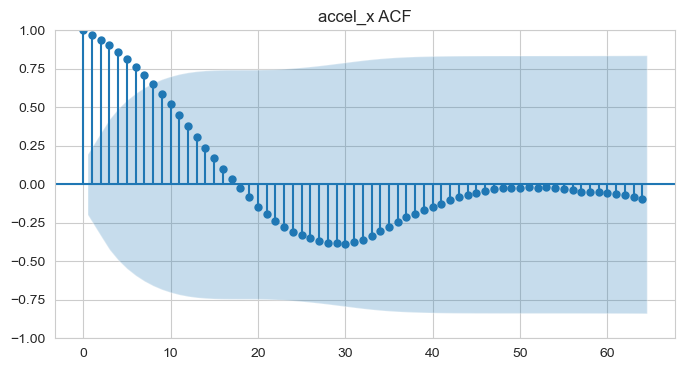


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.0084 -0.0313]

📈 ACF for ACCEL_Y | 64 lags (auto)


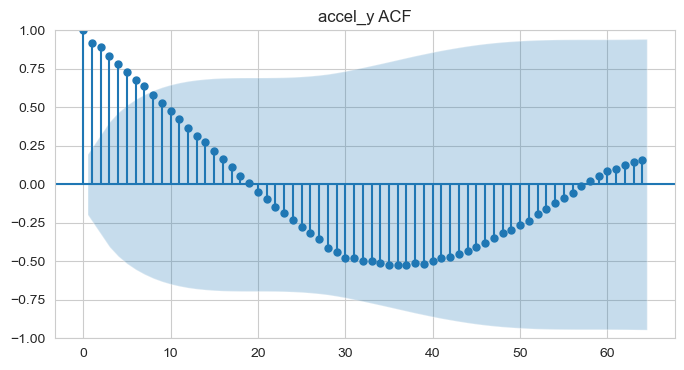


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [0.6786 0.2712]

📈 ACF for ACCEL_Z | 64 lags (auto)


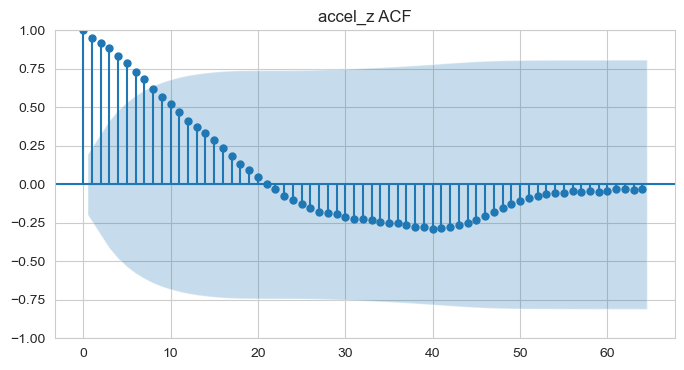


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [0.7445 0.2257]

📈 ACF for Y_BAR | 64 lags (auto)


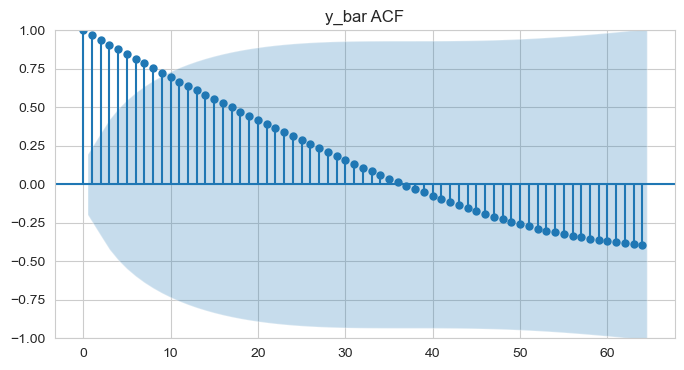


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9634 -0.9632]


{'accel_x': {'roots': array([0.97636522, 0.03202952]),
  'moduli': array([0.97636522, 0.03202952]),
  'stationary': False},
 'accel_y': {'roots': array([ 0.96088567, -0.28227648]),
  'moduli': array([0.96088567, 0.28227648]),
  'stationary': False},
 'accel_z': {'roots': array([ 0.97582633, -0.23133798]),
  'moduli': array([0.97582633, 0.23133798]),
  'stationary': False},
 'y_bar': {'roots': array([1.0054127 , 0.95797755]),
  'moduli': array([1.0054127 , 0.95797755]),
  'stationary': False}}

In [936]:
results = arma_stationarity_random_window(df_windows, p=2)
results

🎲 Randomly selected user: wh298

📈 ACF for ACCEL_X | 64 lags (auto)


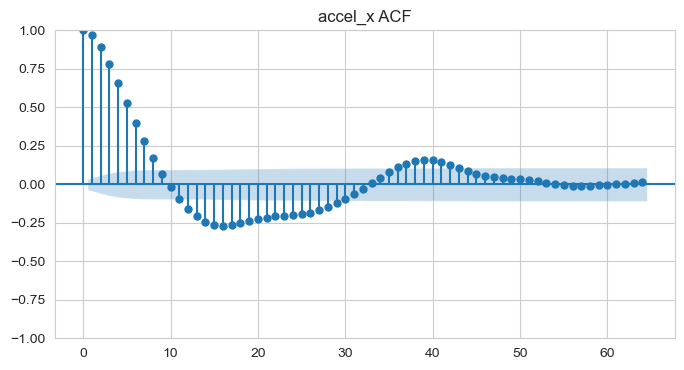


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: wh298
Estimated φ̂ = [ 1.7426 -0.798 ]
φ = [ 1.7426 -0.798 ]
  Root 1: 0.8713+0.1971j | |z|=0.8933
  Root 2: 0.8713-0.1971j | |z|=0.8933
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


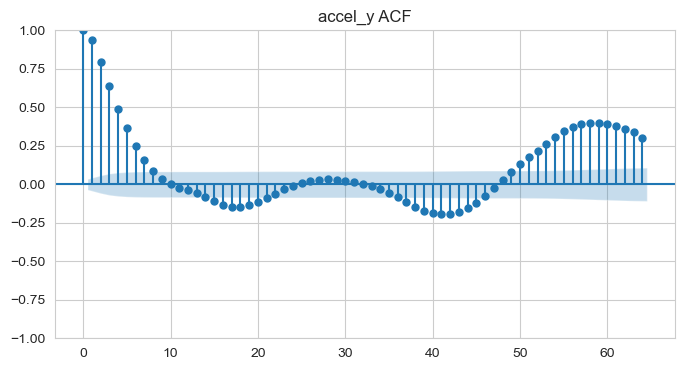


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: wh298
Estimated φ̂ = [ 1.5401 -0.6466]
φ = [ 1.5401 -0.6466]
  Root 1: 0.7700+0.2316j | |z|=0.8041
  Root 2: 0.7700-0.2316j | |z|=0.8041
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


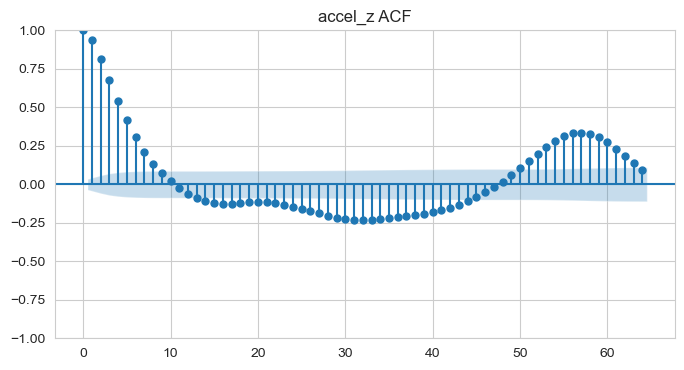


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: wh298
Estimated φ̂ = [ 1.4831 -0.5791]
φ = [ 1.4831 -0.5791]
  Root 1: 0.7416+0.1708j | |z|=0.7610
  Root 2: 0.7416-0.1708j | |z|=0.7610
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


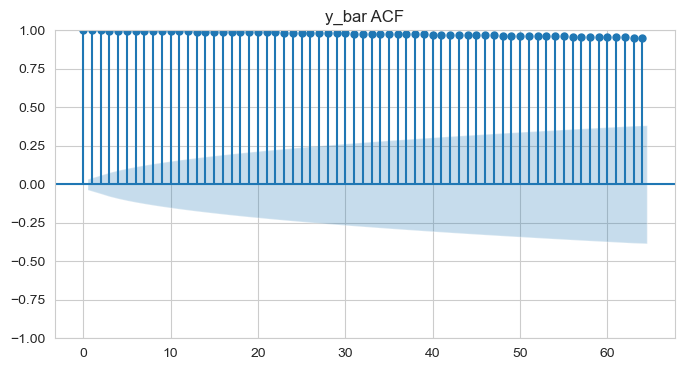


📘 Y_BAR | Estimating φ̂ | AR(2) | User: wh298
Estimated φ̂ = [ 1.9973 -0.9973]
φ = [ 1.9973 -0.9973]
  Root 1: 0.9986+0.0037j | |z|=0.9987
  Root 2: 0.9986-0.0037j | |z|=0.9987
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.74259431, -0.79800652]),
  'roots': array([0.87129715+0.19709842j, 0.87129715-0.19709842j]),
  'moduli': array([0.8933121, 0.8933121]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.54006964, -0.64658604]),
  'roots': array([0.77003482+0.23158674j, 0.77003482-0.23158674j]),
  'moduli': array([0.80410574, 0.80410574]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.48312247, -0.57908782]),
  'roots': array([0.74156124+0.17080618j, 0.74156124-0.17080618j]),
  'moduli': array([0.7609782, 0.7609782]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.99729687, -0.99731221]),
  'roots': array([0.99864843+0.00367614j, 0.99864843-0.00367614j]),
  'moduli': array([0.9986552, 0.9986552]),
  'stationary': False}}

In [243]:
arma_stationarity_user(df_allMeansTrimmed, activity_walk,random=True)

# Test removing seasonality

In [1007]:
# --- 1) Seasonal lag estimator from ACF (per window)
def estimate_seasonal_lag_acf(x, sample_rate=32, min_sec=0.6, max_sec=1.2, min_prom=0.1):
    """
    Estimate seasonal lag s from the first prominent ACF peak in [min_sec, max_sec].
    Returns None if no clear seasonal peak.
    """
    x = np.asarray(x, float)
    if len(x) < int(max_sec*sample_rate)+5:
        return None
    # unbiased=False keeps behavior fast and stable for windowed data
    max_lag = int(max_sec * sample_rate)
    ac = acf(x, nlags=max_lag, fft=True)
    # search range
    lo = max(1, int(min_sec * sample_rate))
    hi = max(2, int(max_sec * sample_rate))
    seg = ac[lo:hi+1]
    if seg.size == 0:
        return None
    k = lo + np.argmax(seg)
    peak = ac[k]
    # simple prominence check against local baseline (lag 1)
    baseline = ac[1] if len(ac) > 2 else 0.0
    if peak - baseline < min_prom:
        return None
    return int(k)

# --- 2) Seasonal + ordinary differencing on one 1D array
def seasonal_diff_array(x, s=None, ordinary_order=0):
    y = np.asarray(x, float)
    if s is not None and s >= 1 and s < len(y):
        y = y[s:] - y[:-s]
    if ordinary_order and len(y) > ordinary_order:
        y = np.diff(y, n=ordinary_order)
    return y

# --- 3) Process a single window row (arrays in columns)
def process_window_row(row, sample_rate=32, s_map=None,  # optional dict like {"Walking-flat-surface": 32}
                       min_sec=0.6, max_sec=1.2, min_prom=0.1,
                       ordinary_order=0, estimate_if_missing=True):
    """
    Apply (1 - B^s) then (1 - B)^d to accel_x/y/z/y_bar for one row.
    s chosen by:
      1) s_map[activity] if provided,
      2) ACF estimate per-signal (use accel_x as primary) if estimate_if_missing,
      3) None (skip seasonal) otherwise.
    Returns (processed_row_dict, s_used)
    """
    activity = row["activity"]
    # prefer a fixed s by activity if supplied
    s_used = s_map.get(activity) if (s_map is not None and activity in s_map) else None

    # if not supplied, estimate from accel_x (most gait-dominant)
    if s_used is None and estimate_if_missing:
        s_used = estimate_seasonal_lag_acf(row["accel_x"], sample_rate, min_sec, max_sec, min_prom)

    out = dict(row)
    for col in ["accel_x", "accel_y", "accel_z", "y_bar"]:
        out[col] = seasonal_diff_array(out[col], s=s_used, ordinary_order=ordinary_order)
    out["s_used"] = s_used
    return out

# --- 4) Ray remote worker
@ray.remote
def process_window_row_remote(row_dict, sample_rate=32, s_map=None,
                              min_sec=0.6, max_sec=1.2, min_prom=0.1,
                              ordinary_order=0, estimate_if_missing=True):
    return process_window_row(row_dict, sample_rate, s_map, min_sec, max_sec, min_prom,
                              ordinary_order, estimate_if_missing)

# --- 5) Apply to an entire windows DataFrame in parallel
def seasonal_difference_all_windows(df_windows, sample_rate=32,
                                    s_map=None,           # e.g., {"Walking-flat-surface": 32}
                                    min_sec=0.6, max_sec=1.2, min_prom=0.1,
                                    ordinary_order=0,     # 0, 1, or 2; do seasonal first
                                    estimate_if_missing=True):
    """
    df_windows columns expected:
      user, activity, session_id, label, ts_start, ts_end,
      accel_x, accel_y, accel_z, y_bar  (arrays per row)
    Returns a new DataFrame with arrays seasonally differenced (and then ordinary differencing).
    Adds s_used per row.
    """
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)

    # Convert each row to dict for Ray
    rows = [r._asdict() if hasattr(r, "_asdict") else r.to_dict() for _, r in df_windows.iterrows()]
    futures = [
        process_window_row_remote.remote(
            row, sample_rate, s_map, min_sec, max_sec, min_prom, ordinary_order, estimate_if_missing
        )
        for row in rows
    ]
    processed = ray.get(futures)

    # Drop rows where arrays got too short after differencing
    keep = []
    for r in processed:
        ax = np.asarray(r["accel_x"])
        ay = np.asarray(r["accel_y"])
        az = np.asarray(r["accel_z"])
        br = np.asarray(r["y_bar"])
        if min(len(ax), len(ay), len(az), len(br)) >= 8:  # keep short but usable windows
            keep.append(r)
    if not keep:
        return pd.DataFrame(columns=df_windows.columns.tolist() + ["s_used"])

    return pd.DataFrame(keep)

In [1010]:
df_windows_seas = seasonal_difference_all_windows(
    df_windows,
    sample_rate=32,
    s_map=None,              # no fixed seasonality — auto-estimate per window
    min_sec=0.6,
    max_sec=1.2,
    min_prom=0.1,
    ordinary_order=0,        # only seasonal differencing (you can later do +1 for regular differencing)
    estimate_if_missing=True
)
df_windows_seas

,user,activity,session_id,label,ts_start,ts_end,accel_x,accel_y,accel_z,y_bar,s_used
0,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.41012898, -0.42442918, -0.4482537, -0.4387...","[-0.59539276, -0.6192039, -0.59539396, -0.5477...","[9.893749, 9.9602, 9.912735, 9.884255, 9.90798...","[1001.991366052565, 1001.9914551359675, 1001.9...",NaN
1,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.49138388, -0.45327488, -0.46757117, -0.453...","[-0.5620831, -0.5858938, -0.571608, -0.6097048...","[9.9744215, 9.926955, 9.917462, 9.950687, 9.92...","[1001.9945016363172, 1001.9945955960554, 1001....",NaN
2,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.43917343, -0.4963468, -0.4344172, -0.44394...","[-0.62877035, -0.5668639, -0.5621022, -0.55257...","[9.941181, 9.88897, 9.898462, 9.96966, 10.0028...","[1001.9990209678789, 1001.9991344709576, 1001....",NaN
3,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.46320048, -0.45844033, -0.43462363, -0.425...","[-0.6145036, -0.62402815, -0.51926285, -0.5716...","[9.874716, 9.903194, 9.926927, 9.960152, 9.912...","[1002.0028448795376, 1002.002887665007, 1002.0...",NaN
4,vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12,"[-0.51043534, -0.5104379, -0.48185563, -0.4913...","[-0.5430344, -0.57160705, -0.5668452, -0.53351...","[9.888985, 9.888985, 9.92221, 9.893729, 9.9317...","[1002.0050782423136, 1002.0051123518765, 1002....",NaN
...,...,...,...,...,...,...,...,...,...,...,...
112680,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.641078, 2.6464617, 2.6799614, 2.7038896, 2....","[-9.415757, -9.410972, -9.387043, -9.387043, -...","[-0.20279172, -0.13100705, -0.083748795, -0.02...","[1004.4823946348376, 1004.482649566673, 1004.4...",NaN
112681,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[5.5262237, 6.1944194, 6.1770716, 5.624928, 4....","[-9.863813, -9.635299, -9.369097, -9.134601, -...","[2.324029, 1.2903296, 0.401396, -0.36729828, -...","[1004.5333368729985, 1004.5343228713247, 1004....",NaN
112682,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.5674987, 2.772085, 3.0921252, 2.7625136, 2....","[-9.714262, -9.058628, -7.9908314, -8.016554, ...","[0.6628119, 1.1659029, 1.8005991, 1.6151553, 1...","[1004.5673750930287, 1004.5677514785841, 1004....",NaN
112683,xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12,"[2.7511477, 2.7469604, 2.742773, 2.7332017, 2....","[-9.809975, -9.785448, -9.812965, -9.807582, -...","[-0.12023934, 0.19501504, 0.50069815, 0.681954...","[1004.5872392553915, 1004.5892310460314, 1004....",NaN



🎲 Random window selected from activity: Walking-flat-surface
🎲 Randomly selected user: jl2855

📈 ACF for ACCEL_X | 64 lags (auto)


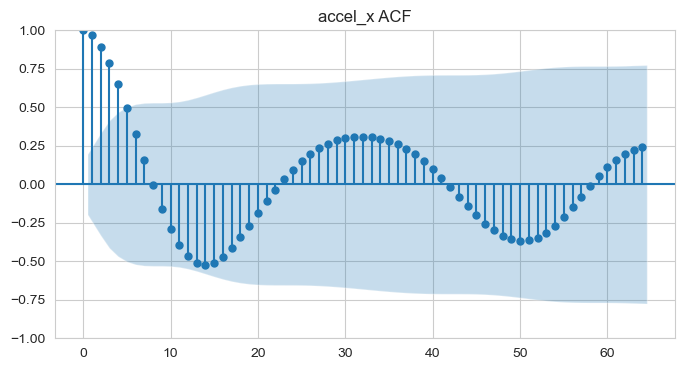


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: jl2855
Estimated φ̂ = [ 1.8442 -0.89  ]

📈 ACF for ACCEL_Y | 64 lags (auto)


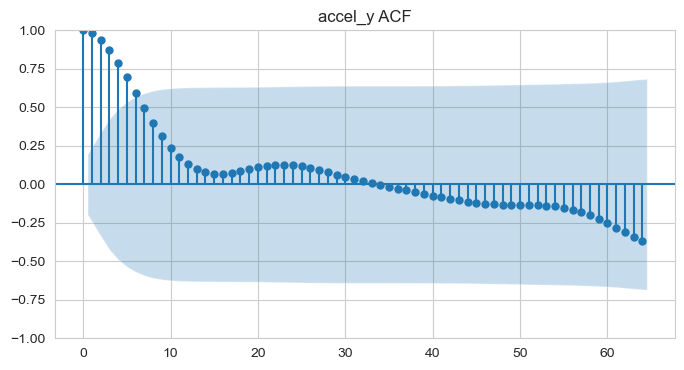


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: jl2855
Estimated φ̂ = [ 1.9721 -0.9988]

📈 ACF for ACCEL_Z | 64 lags (auto)


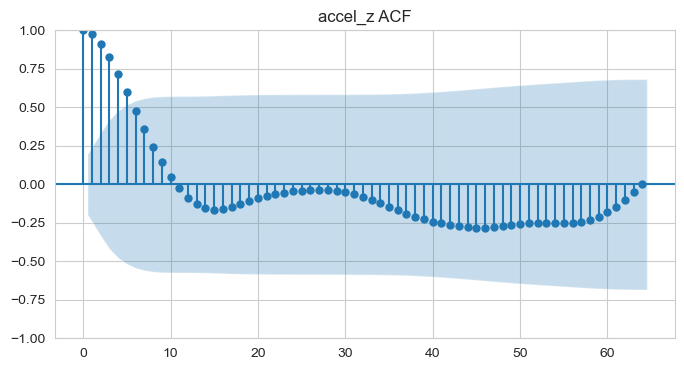


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: jl2855
Estimated φ̂ = [ 1.8609 -0.901 ]

📈 ACF for Y_BAR | 64 lags (auto)


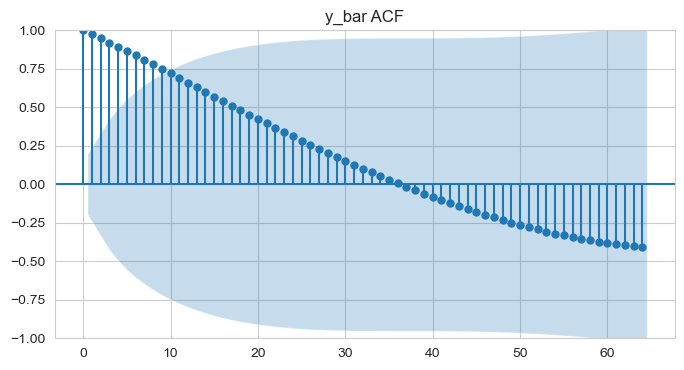


📘 Y_BAR | Estimating φ̂ | AR(2) | User: jl2855
Estimated φ̂ = [ 2.0256 -1.0259]


{'accel_x': {'roots': array([0.92212089+0.1992519j, 0.92212089-0.1992519j]),
  'moduli': array([0.94340249, 0.94340249]),
  'stationary': False},
 'accel_y': {'roots': array([0.98606756+0.16257764j, 0.98606756-0.16257764j]),
  'moduli': array([0.99938017, 0.99938017]),
  'stationary': False},
 'accel_z': {'roots': array([0.93045366+0.18767261j, 0.93045366-0.18767261j]),
  'moduli': array([0.94919177, 0.94919177]),
  'stationary': False},
 'y_bar': {'roots': array([1.01277905+0.01503484j, 1.01277905-0.01503484j]),
  'moduli': array([1.01289064, 1.01289064]),
  'stationary': True}}

In [1179]:
results = arma_stationarity_random_window(df_windows_seas, p=2)
results

# Test with Differencing

In [940]:
# --- 1️⃣ Difference one window (row-wise on arrays) ---
def difference_window_arrays(row, order=1):
    """Apply n-th order differencing to the array columns in one window row."""
    diffed = {}
    for col in ["accel_x", "accel_y", "accel_z", "y_bar"]:
        arr = np.asarray(row[col])
        if arr.ndim == 1 and len(arr) > order:
            diffed[col] = np.diff(arr, n=order)
        else:
            diffed[col] = np.array([])
    diffed["user"] = row["user"]
    diffed["activity"] = row["activity"]
    diffed["session_id"] = row["session_id"]
    diffed["label"] = row["label"]
    diffed["ts_start"] = row["ts_start"]
    diffed["ts_end"] = row["ts_end"]
    return diffed


# --- 2️⃣ Ray remote worker ---
@ray.remote
def difference_window_arrays_remote(row, order=1):
    return difference_window_arrays(row, order)


# --- 3️⃣ Parallel differencing across all windows ---
def difference_all_windows(df_windows, order=1):
    """
    Parallel differencing for array-style windowed data.
    Each window row is processed independently.
    """
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)

    rows = df_windows.to_dict("records")
    futures = [difference_window_arrays_remote.remote(row, order=order) for row in rows]
    results = ray.get(futures)
    valid = [r for r in results if all(len(r[c]) > 0 for c in ["accel_x", "accel_y", "accel_z", "y_bar"])]

    df_diff = pd.DataFrame(valid)
    print(f"✅ Differenced {len(df_diff)} windows | order={order}")
    return df_diff

In [1044]:
# First difference
df_diff1 = difference_all_windows(df_windows_seas, order=1)
df_diff1 

✅ Differenced 112685 windows | order=1


,accel_x,accel_y,accel_z,y_bar,user,activity,session_id,label,ts_start,ts_end
0,"[-0.01430020000000004, -0.02382451999999996, 0...","[-0.023811140000000064, 0.02380994000000003, 0...","[0.0664510000000007, -0.04746500000000076, -0....","[8.908340248581226e-05, 8.957698514677759e-05,...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
1,"[0.038109000000000004, -0.01429628999999999, 0...","[-0.023810700000000073, 0.014285800000000015, ...","[-0.04746650000000052, -0.009492999999999086, ...","[9.395973825121473e-05, 9.6837415412665e-05, 9...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
2,"[-0.05717337, 0.061929599999999974, -0.0095321...","[0.06190645000000006, 0.00476169999999998, 0.0...","[-0.052210999999999785, 0.009491999999999834, ...","[0.00011350307875090948, 0.0001092897730359254...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
3,"[0.0047601500000000185, 0.023816700000000024, ...","[-0.009524549999999965, 0.10476529999999995, -...","[0.02847799999999978, 0.023733000000000004, 0....","[4.2785469418049615e-05, 3.9055244542396395e-0...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
4,"[-2.5599999999847967e-06, 0.02858227000000002,...","[-0.028572649999999977, 0.004761849999999956, ...","[0.0, 0.03322499999999984, -0.0284809999999993...","[3.4109562875528354e-05, 4.301715500787395e-05...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
...,...,...,...,...,...,...,...,...,...,...
112680,"[0.005383700000000324, 0.03349969999999969, 0....","[0.004785000000000039, 0.02392899999999898, 0....","[0.07178467, 0.04725825500000001, 0.057427745,...","[0.0002549318353430863, 0.00030409503210648836...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112681,"[0.6681957000000001, -0.01734780000000047, -0....","[0.22851400000000055, 0.2662019999999998, 0.23...","[-1.0336994, -0.8889336, -0.76869428, -0.54795...","[0.000985998326200388, 0.0009816302371064012, ...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112682,"[0.20458630000000033, 0.3200401999999998, -0.3...","[0.6556339999999992, 1.0677966000000003, -0.02...","[0.5030910000000001, 0.6346961999999998, -0.18...","[0.00037638555545527197, 0.0003303049004443892...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112683,"[-0.004187300000000338, -0.00418739999999973, ...","[0.024526999999999077, -0.02751699999999957, 0...","[0.31525438, 0.3056831099999999, 0.18125629000...","[0.0019917906398632113, 0.002070664832217517, ...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12



🎲 Random window selected from activity: Walking-down-stairs
🎲 Randomly selected user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


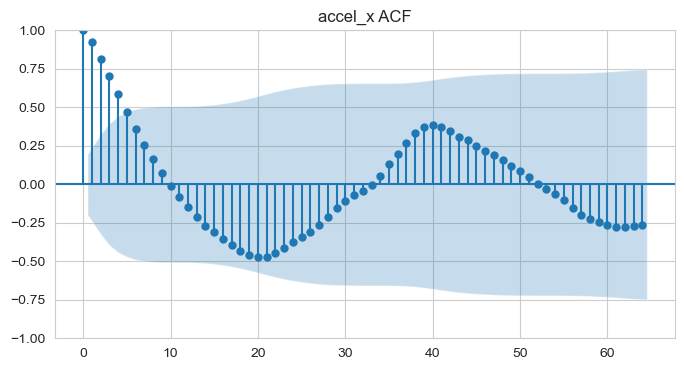


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3072 -0.3853]

📈 ACF for ACCEL_Y | 64 lags (auto)


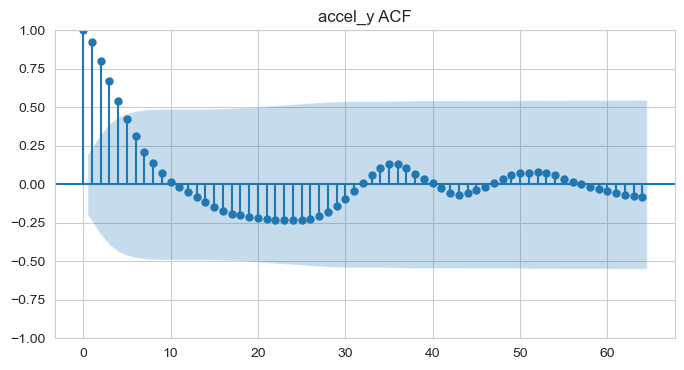


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.5746 -0.6409]

📈 ACF for ACCEL_Z | 64 lags (auto)


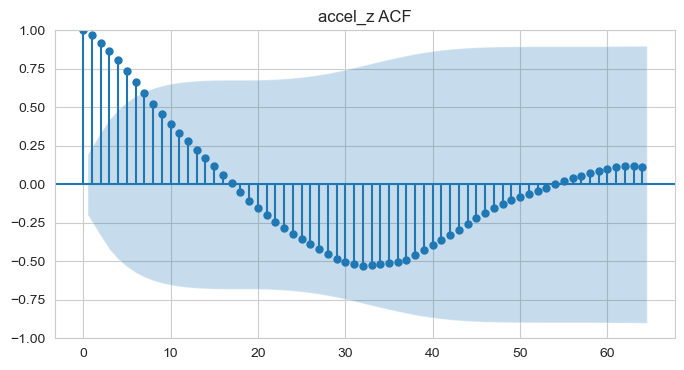


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3799 -0.4199]

📈 ACF for Y_BAR | 64 lags (auto)


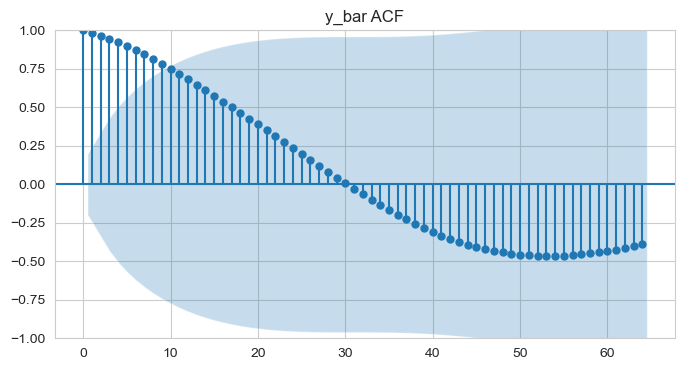


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9856 -0.9879]


{'accel_x': {'roots': array([0.85823066, 0.44896981]),
  'moduli': array([0.85823066, 0.44896981]),
  'stationary': False},
 'accel_y': {'roots': array([0.78729739+0.14501716j, 0.78729739-0.14501716j]),
  'moduli': array([0.80054179, 0.80054179]),
  'stationary': False},
 'accel_z': {'roots': array([0.92673282, 0.45312608]),
  'moduli': array([0.92673282, 0.45312608]),
  'stationary': False},
 'y_bar': {'roots': array([0.9927812+0.04770171j, 0.9927812-0.04770171j]),
  'moduli': array([0.99392654, 0.99392654]),
  'stationary': False}}

In [1114]:
results = arma_stationarity_random_window(df_diff1, p=2)
results

In [1115]:
df_diff2 = difference_all_windows(df_windows_seas, order=2)
df_diff2 

✅ Differenced 112685 windows | order=2


,accel_x,accel_y,accel_z,y_bar,user,activity,session_id,label,ts_start,ts_end
0,"[-0.00952431999999992, 0.03334889999999996, -0...","[0.04762108000000009, 0.023810479999999967, -0...","[-0.11391600000000146, 0.018985000000000696, 0...","[4.935826609653304e-07, 4.935826609653304e-07,...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
1,"[-0.05240528999999999, 0.02858480999999996, 0....","[0.03809650000000009, -0.052382649999999975, 0...","[0.03797350000000144, 0.042717999999998923, -0...","[2.877677161450265e-06, 2.734657982728095e-06,...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
2,"[0.11910296999999997, -0.07146174, -0.01905633...","[-0.05714475000000008, 0.004762049999999962, 0...","[0.06170299999999962, 0.06170599999999915, -0....","[-4.213305714984017e-06, -4.213305714984017e-0...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
3,"[0.019056550000000005, -0.014292350000000065, ...","[0.11428984999999992, -0.15714847999999992, 0....","[-0.004744999999999777, 0.00949200000000161, -...","[-3.730224875653221e-06, -3.730224761966383e-0...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
4,"[0.028584830000000006, -0.03811308000000002, 0...","[0.033334499999999934, 0.028572450000000083, -...","[0.03322499999999984, -0.06170599999999915, 0....","[8.907592132345599e-06, 8.907591904971923e-06,...",vbagdi,Stationary,vbagdi_Stationary_session1,1,1.761522e+12,1.761522e+12
...,...,...,...,...,...,...,...,...,...,...
112680,"[0.028115999999999364, -0.0095714999999994, -0...","[0.01914399999999894, -0.02392899999999898, 0....","[-0.024526414999999982, 0.01016948999999999, -...","[4.9163196763402084e-05, 4.916319687708892e-05...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112681,"[-0.6855435000000005, -0.5347957999999995, -0....","[0.03768799999999928, -0.03170599999999979, -0...","[0.14476579999999994, 0.12023932000000004, 0.2...","[-4.368089093986782e-06, -4.3680889802999445e-...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112682,"[0.11545389999999944, -0.6496517999999996, 0.4...","[0.41216260000000116, -1.0935191999999994, -0....","[0.13160519999999976, -0.8201399999999996, -0....","[-4.6080655010882765e-05, -5.822343007366726e-...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12
112683,"[-9.99999993922529e-08, -0.005383900000000441,...","[-0.05204399999999865, 0.03289999999999971, -0...","[-0.009571270000000076, -0.12442681999999983, ...","[7.88741923543057e-05, 6.68297536776663e-05, 3...",xichen,Elevator-down,xichen_Elevator-down_session2,7,1.760986e+12,1.760986e+12



🎲 Random window selected from activity: Elevator-up
🎲 Randomly selected user: yaw006

📈 ACF for ACCEL_X | 64 lags (auto)


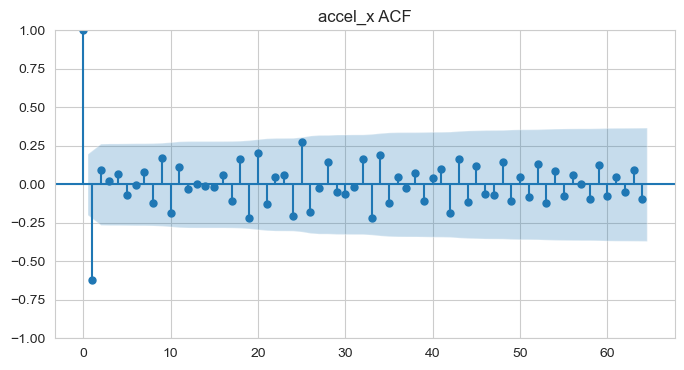


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [-0.9217 -0.48  ]

📈 ACF for ACCEL_Y | 64 lags (auto)


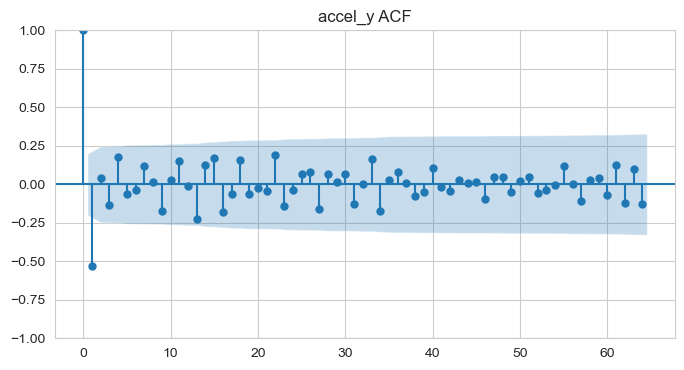


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [-0.697  -0.3326]

📈 ACF for ACCEL_Z | 64 lags (auto)


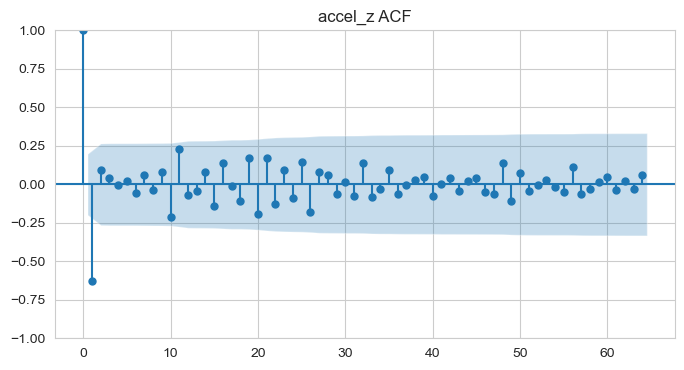


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [-0.9491 -0.5026]

📈 ACF for Y_BAR | 64 lags (auto)


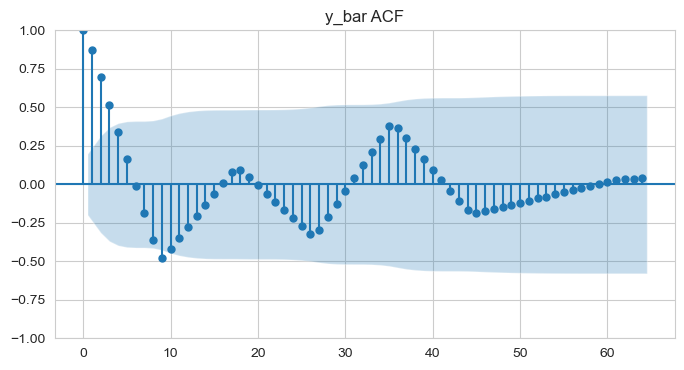


📘 Y_BAR | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [ 1.1052 -0.2683]


{'accel_x': {'roots': array([-0.46086001+0.51729134j, -0.46086001-0.51729134j]),
  'moduli': array([0.69280754, 0.69280754]),
  'stationary': False},
 'accel_y': {'roots': array([-0.34851201+0.45952305j, -0.34851201-0.45952305j]),
  'moduli': array([0.57673395, 0.57673395]),
  'stationary': False},
 'accel_z': {'roots': array([-0.47455022+0.52665141j, -0.47455022-0.52665141j]),
  'moduli': array([0.70891439, 0.70891439]),
  'stationary': False},
 'y_bar': {'roots': array([0.74495926, 0.36019475]),
  'moduli': array([0.74495926, 0.36019475]),
  'stationary': False}}

In [1154]:
results = arma_stationarity_random_window(df_diff2, p=2)
results

## Test all windows

In [ ]:
## 

## Test all adjusted for seasonality

In [245]:
@ray.remote
def difference_user(df, activity_name, user_id, order):
    """Helper run remotely for one user."""
    sensors = ["accel_x", "accel_y", "accel_z", "y_bar"]
    df_user = df[(df["user"] == user_id) & (df["activity"] == activity_name)].copy()
    if df_user.empty:
        return pd.DataFrame()
    for sig in sensors:
        df_user[sig] = df_user[sig].diff(order)
    df_user = df_user.dropna(subset=sensors).reset_index(drop=True)
    return df_user


def difference_all_users(df, activity_name="Walking-flat-surface", order=1):
    """
    Apply differencing across all users who performed the given activity.
    - order=1 → first difference
    - order=2 → second difference
    Returns one combined DataFrame ready for re-testing.
    """
    users = df[df["activity"] == activity_name]["user"].unique().tolist()
    print(f"📊 Differencing order {order} for {len(users)} users ({activity_name})")

    # Run in parallel with Ray
    futures = [difference_user.remote(df, activity_name, user, order) for user in users]
    df_list = ray.get(futures)

    # Combine all results
    df_diff_all = pd.concat(df_list, ignore_index=True)
    print(f"✅ Done! Combined shape: {df_diff_all.shape}")
    return df_diff_all

In [247]:
# 1st difference for all users
df_diff1_all = difference_all_users(df_allMeansTrimmed, activity_name=activity_walk, order=1)
df_diff1_all

📊 Differencing order 1 for 31 users (Walking-flat-surface)
✅ Done! Combined shape: (675017, 8)


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.760635e+12,-0.024527,-0.066999,0.024527,-0.000017,2,Grack,Walking-flat-surface
1,1.760635e+12,-0.029312,-0.052642,0.019143,-0.000021,2,Grack,Walking-flat-surface
2,1.760635e+12,-0.034097,-0.085543,0.024526,-0.000024,2,Grack,Walking-flat-surface
3,1.760635e+12,-0.020339,-0.081356,-0.009571,-0.000028,2,Grack,Walking-flat-surface
4,1.760635e+12,-0.014955,-0.071785,-0.013759,-0.000031,2,Grack,Walking-flat-surface
...,...,...,...,...,...,...,...,...
675012,1.760636e+12,-0.159721,-0.150748,-0.042473,-0.000023,2,yinuoinno,Walking-flat-surface
675013,1.760636e+12,-0.015553,-0.101097,0.071785,-0.000017,2,yinuoinno,Walking-flat-surface
675014,1.760636e+12,0.135195,-0.127418,0.151944,-0.000004,2,yinuoinno,Walking-flat-surface
675015,1.760636e+12,-0.135195,-0.147159,0.232702,0.000009,2,yinuoinno,Walking-flat-surface


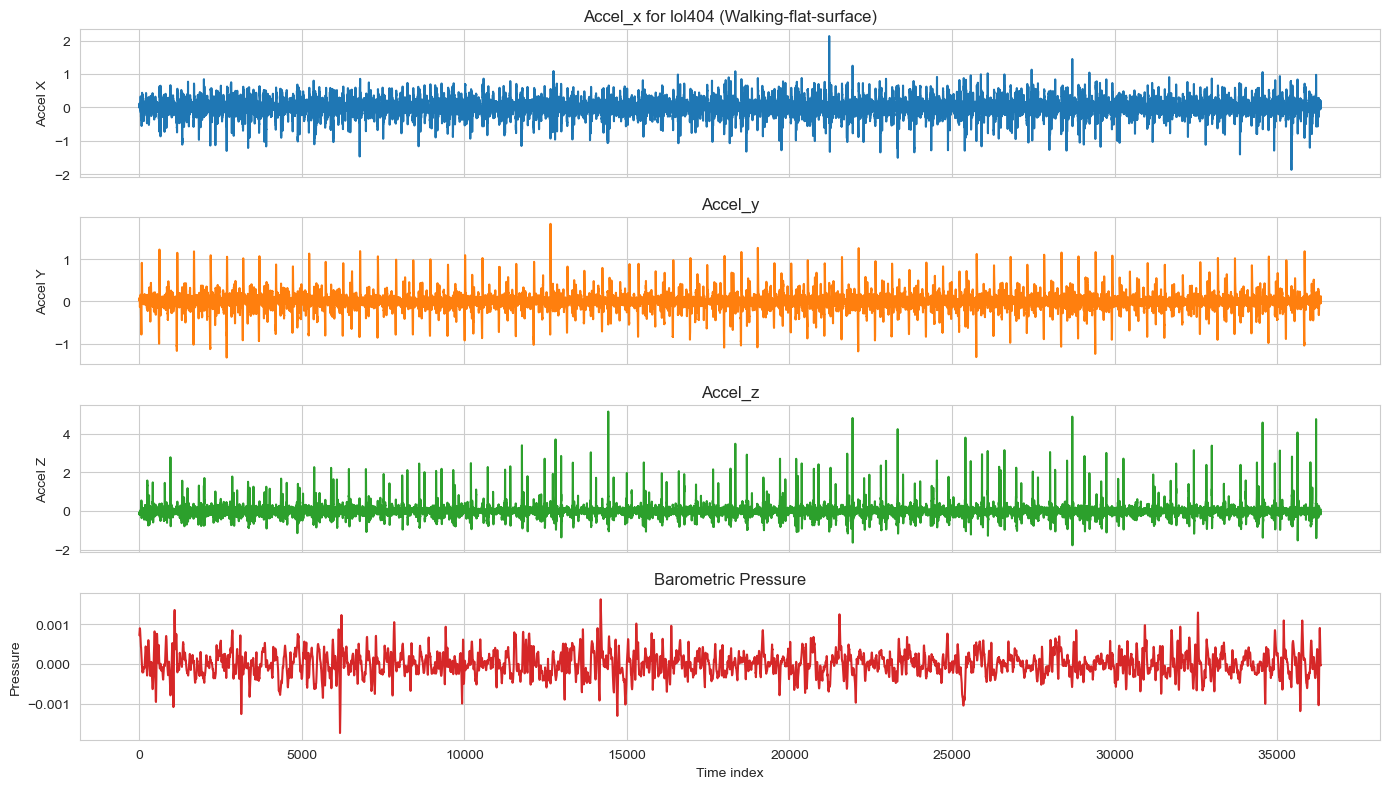

In [248]:
plot_user_activity(df_diff1_all, activity_name=activity_walk, user_id=my_netid, random=False)

🎲 Randomly selected user: mlc299


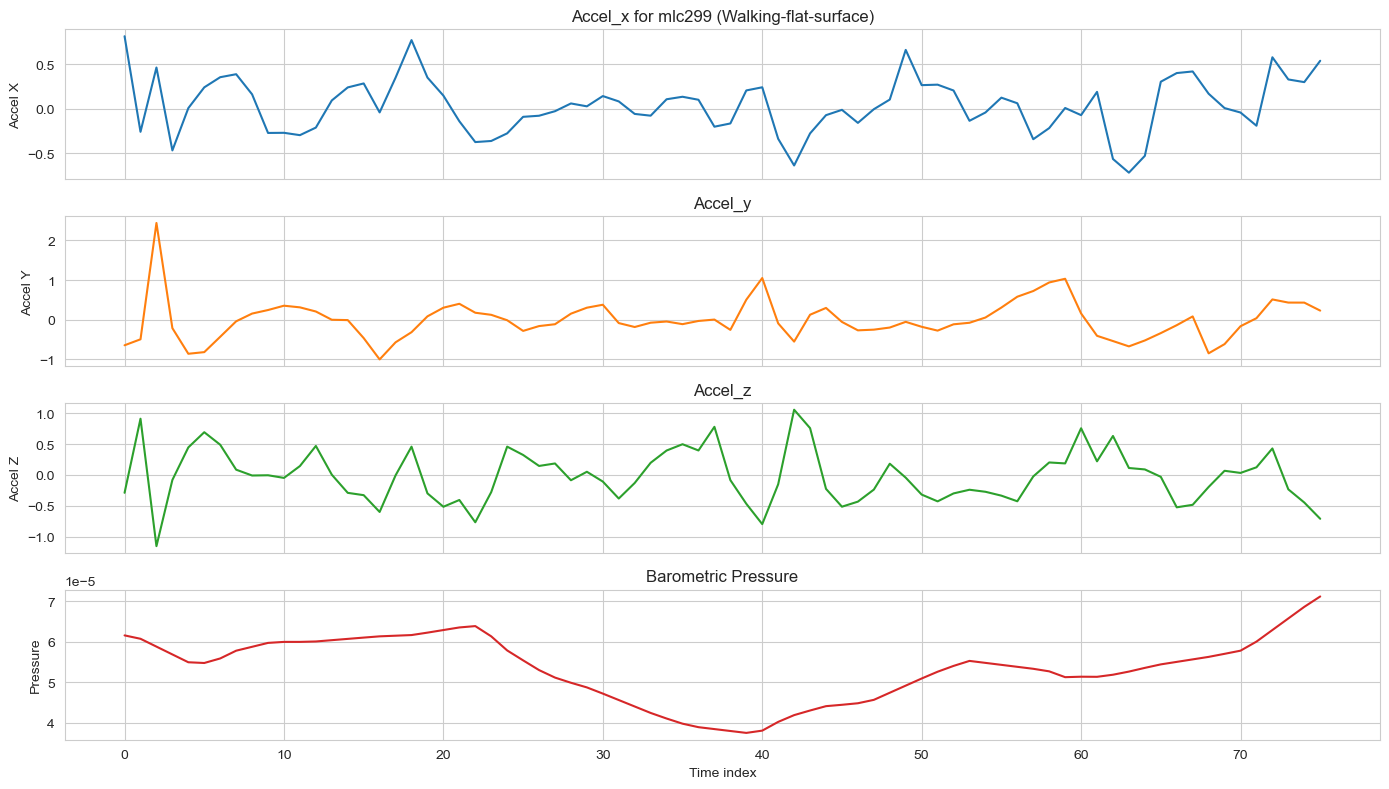

In [566]:
plot_user_activity(df_diff1_all, activity_name=activity_walk, random=True)

👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


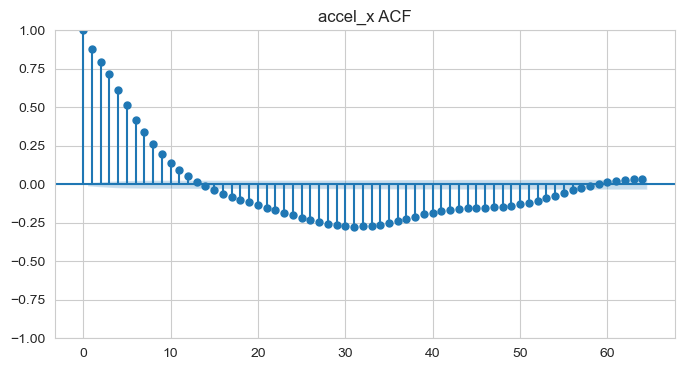


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [0.7902 0.0991]
φ = [0.7902 0.0991]
  Root 1: 0.9003 | |z|=0.9003
  Root 2: -0.1101 | |z|=0.1101
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


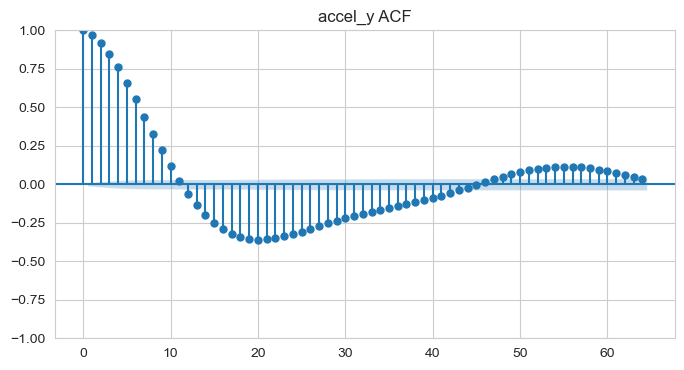


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.2276 -0.27  ]
φ = [ 1.2276 -0.27  ]
  Root 1: 0.9404 | |z|=0.9404
  Root 2: 0.2872 | |z|=0.2872
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


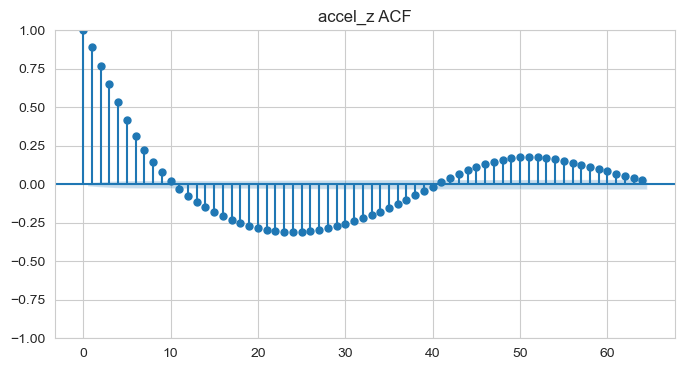


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.0158 -0.1373]
φ = [ 1.0158 -0.1373]
  Root 1: 0.8553 | |z|=0.8553
  Root 2: 0.1605 | |z|=0.1605
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


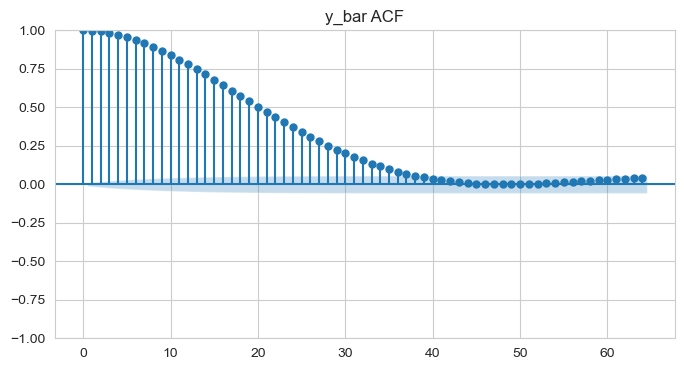


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9562 -0.9599]
φ = [ 1.9562 -0.9599]
  Root 1: 0.9781+0.0573j | |z|=0.9798
  Root 2: 0.9781-0.0573j | |z|=0.9798
⚠️ Non-stationary


{'accel_x': {'phi': array([0.79024877, 0.09911897]),
  'roots': array([ 0.90033944, -0.11009067]),
  'moduli': array([0.90033944, 0.11009067]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.2275782 , -0.27004885]),
  'roots': array([0.9404207, 0.2871575]),
  'moduli': array([0.9404207, 0.2871575]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.01576092, -0.13726303]),
  'roots': array([0.85527006, 0.16049086]),
  'moduli': array([0.85527006, 0.16049086]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.95617637, -0.95994167]),
  'roots': array([0.97808818+0.05731648j, 0.97808818-0.05731648j]),
  'moduli': array([0.97976613, 0.97976613]),
  'stationary': False}}

In [259]:
arma_stationarity_user(df_diff1_all,activity_walk,my_netid,random=False,p=2)

🎲 Randomly selected user: jps394

📈 ACF for ACCEL_X | 64 lags (auto)


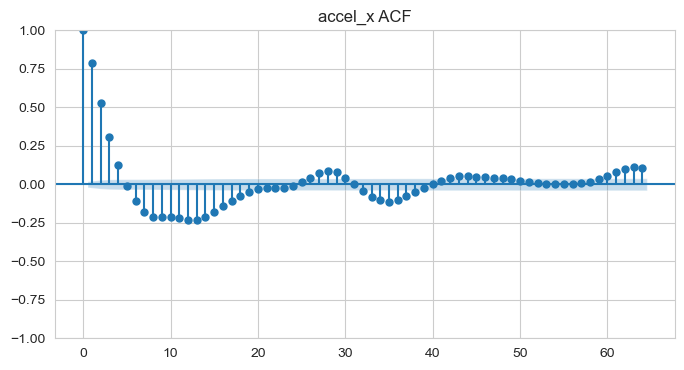


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [ 0.9583 -0.2216]
φ = [ 0.9583 -0.2216]
  Root 1: 0.5687 | |z|=0.5687
  Root 2: 0.3896 | |z|=0.3896
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


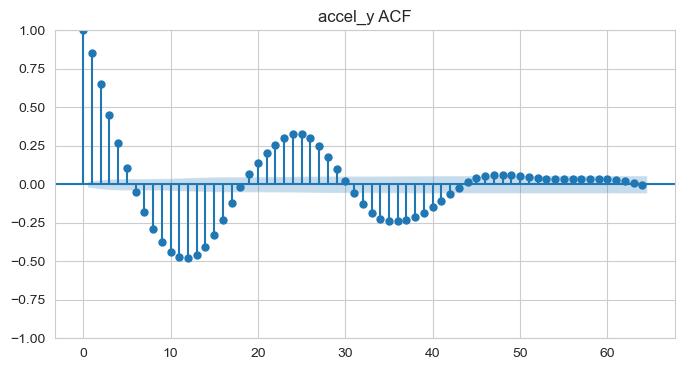


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [ 1.1213 -0.3105]
φ = [ 1.1213 -0.3105]
  Root 1: 0.6228 | |z|=0.6228
  Root 2: 0.4985 | |z|=0.4985
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


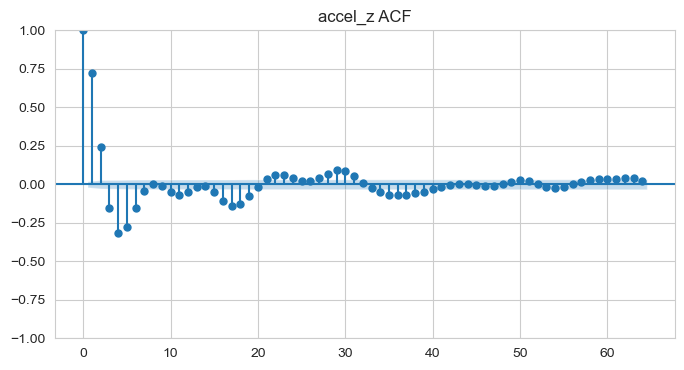


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [ 1.1353 -0.576 ]
φ = [ 1.1353 -0.576 ]
  Root 1: 0.5676+0.5038j | |z|=0.7590
  Root 2: 0.5676-0.5038j | |z|=0.7590
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


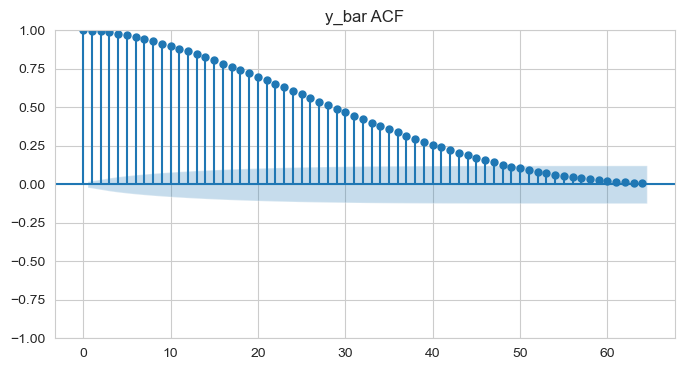


📘 Y_BAR | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [ 1.9305 -0.9333]
φ = [ 1.9305 -0.9333]
  Root 1: 0.9653+0.0396j | |z|=0.9661
  Root 2: 0.9653-0.0396j | |z|=0.9661
⚠️ Non-stationary


{'accel_x': {'phi': array([ 0.95833283, -0.22158403]),
  'roots': array([0.56870092, 0.38963191]),
  'moduli': array([0.56870092, 0.38963191]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.12129452, -0.31046644]),
  'roots': array([0.6227674 , 0.49852712]),
  'moduli': array([0.6227674 , 0.49852712]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.13525689, -0.57600558]),
  'roots': array([0.56762845+0.50378917j, 0.56762845-0.50378917j]),
  'moduli': array([0.75895031, 0.75895031]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.93052351, -0.93329817]),
  'roots': array([0.96526175+0.0395969j, 0.96526175-0.0395969j]),
  'moduli': array([0.96607358, 0.96607358]),
  'stationary': False}}

In [262]:
arma_stationarity_user(df_diff1_all, activity_walk, random=True)

In [263]:
df_diff2_all = difference_all_users(df_allMeansTrimmed, activity_name=activity_walk, order=2)
df_diff2_all


📊 Differencing order 2 for 31 users (Walking-flat-surface)
✅ Done! Combined shape: (674986, 8)


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.760635e+12,-0.053839,-0.119642,0.043669,-0.000038,2,Grack,Walking-flat-surface
1,1.760635e+12,-0.063409,-0.138185,0.043669,-0.000046,2,Grack,Walking-flat-surface
2,1.760635e+12,-0.054436,-0.166899,0.014955,-0.000052,2,Grack,Walking-flat-surface
3,1.760635e+12,-0.035294,-0.153141,-0.023330,-0.000058,2,Grack,Walking-flat-surface
4,1.760635e+12,-0.030508,-0.153141,-0.041875,-0.000065,2,Grack,Walking-flat-surface
...,...,...,...,...,...,...,...,...
674981,1.760636e+12,-0.393620,-0.218345,-0.199203,-0.000049,2,yinuoinno,Walking-flat-surface
674982,1.760636e+12,-0.175274,-0.251845,0.029312,-0.000041,2,yinuoinno,Walking-flat-surface
674983,1.760636e+12,0.119641,-0.228515,0.223729,-0.000022,2,yinuoinno,Walking-flat-surface
674984,1.760636e+12,0.000000,-0.274577,0.384646,0.000004,2,yinuoinno,Walking-flat-surface


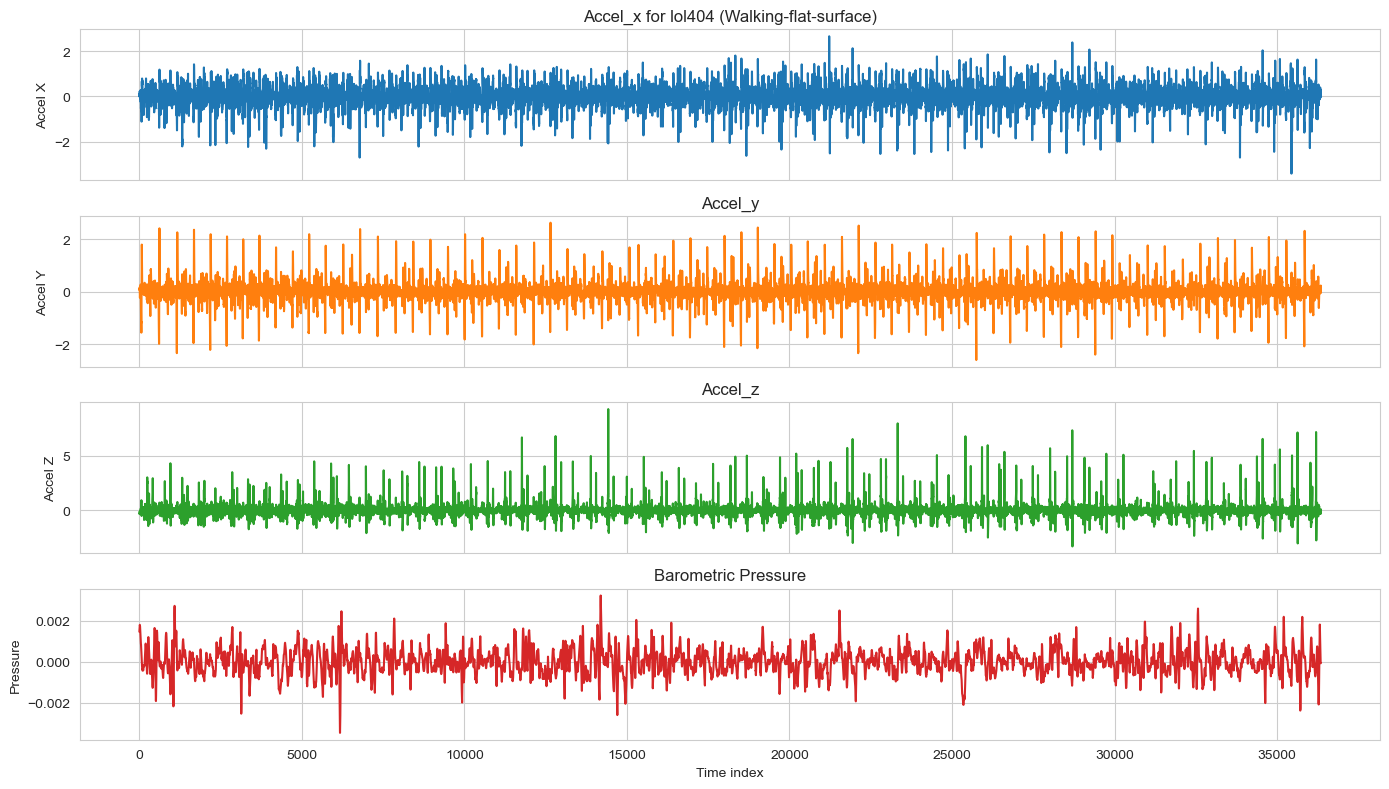

In [ ]:
plot_user_activity(df_diff2_all, activity_name=activity_walk, user_id=my_netid, random=False)

🎲 Randomly selected user: jude


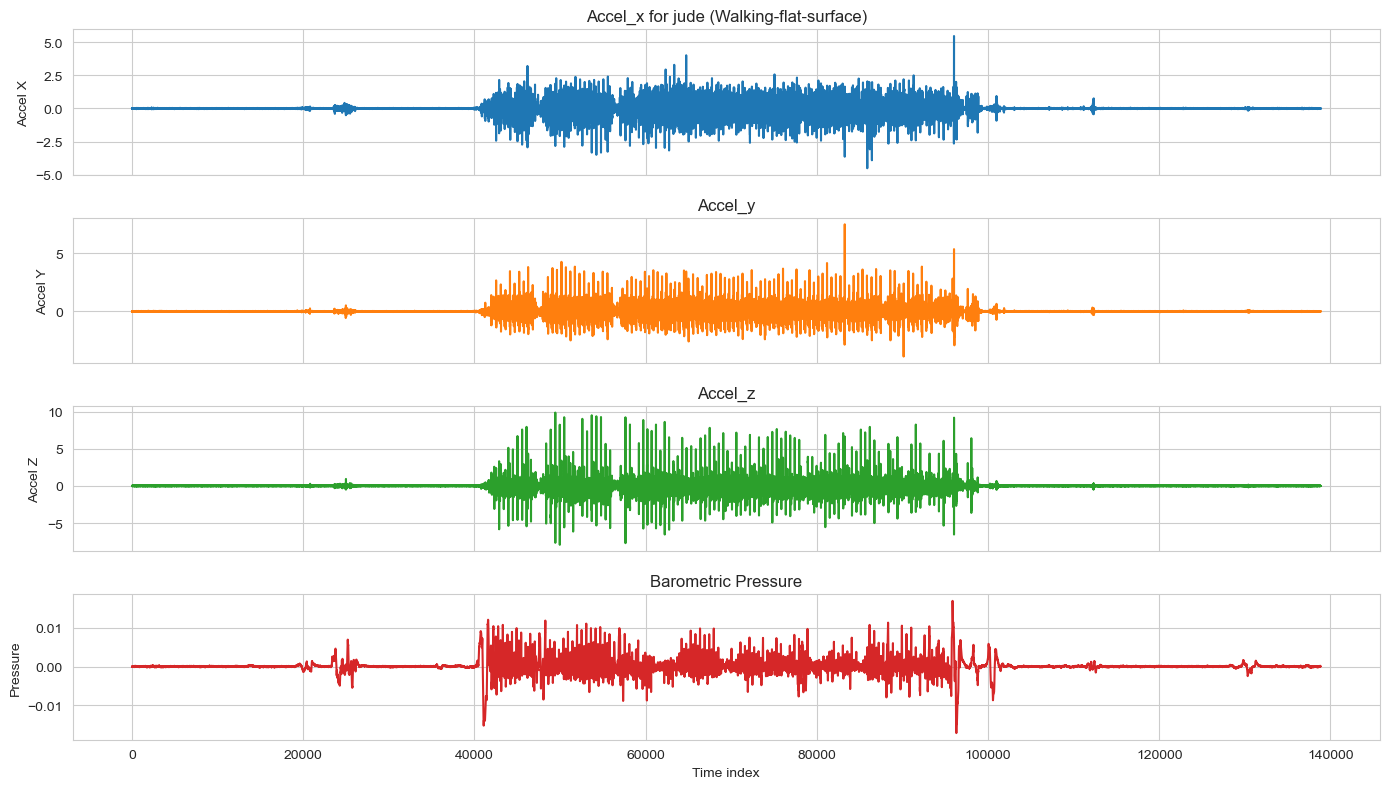

In [278]:
plot_user_activity(df_diff2_all, activity_name=activity_walk, random=True)

👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


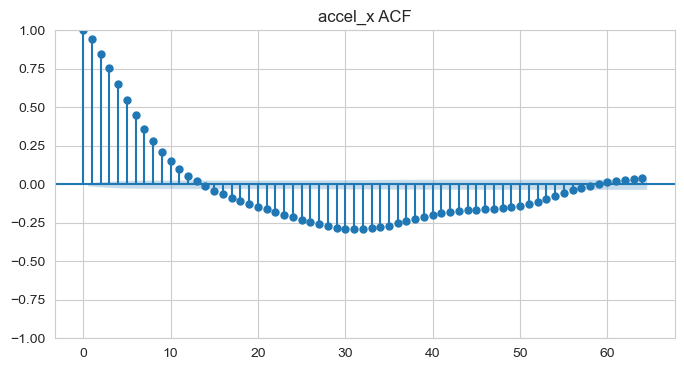


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3559 -0.4352]
φ = [ 1.3559 -0.4352]
  Root 1: 0.8339 | |z|=0.8339
  Root 2: 0.5219 | |z|=0.5219
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


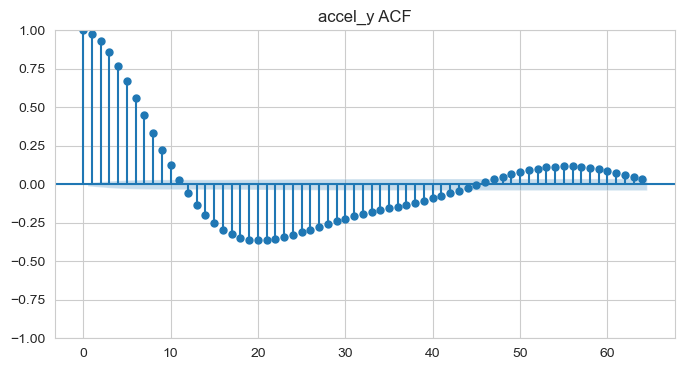


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.6969 -0.7337]
φ = [ 1.6969 -0.7337]
  Root 1: 0.8484+0.1177j | |z|=0.8566
  Root 2: 0.8484-0.1177j | |z|=0.8566
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


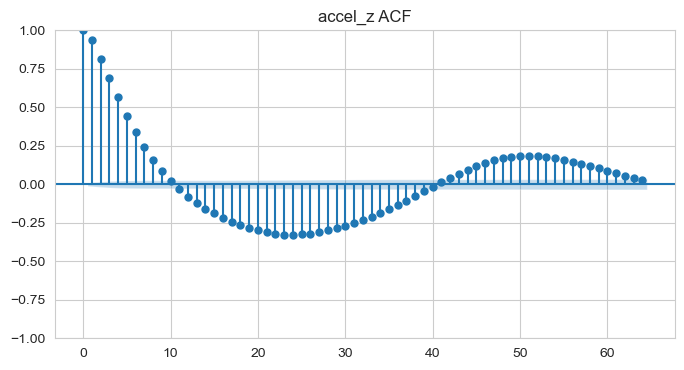


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.4721 -0.5674]
φ = [ 1.4721 -0.5674]
  Root 1: 0.7361+0.1599j | |z|=0.7532
  Root 2: 0.7361-0.1599j | |z|=0.7532
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


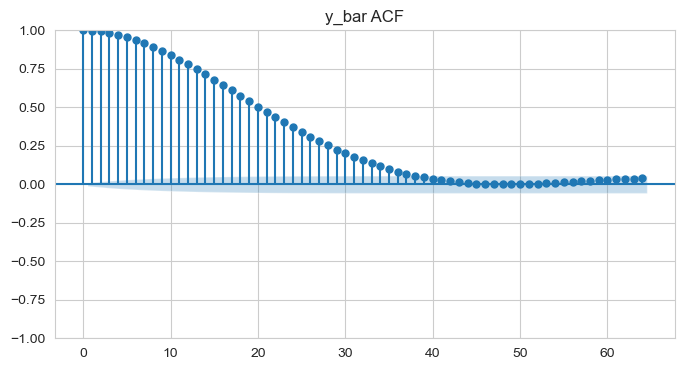


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9723 -0.976 ]
φ = [ 1.9723 -0.976 ]
  Root 1: 0.9861+0.0594j | |z|=0.9879
  Root 2: 0.9861-0.0594j | |z|=0.9879
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.35585369, -0.43524429]),
  'roots': array([0.83394133, 0.52191236]),
  'moduli': array([0.83394133, 0.52191236]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.69689669, -0.73371286]),
  'roots': array([0.84844835+0.11767867j, 0.84844835-0.11767867j]),
  'moduli': array([0.85657041, 0.85657041]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.47213383, -0.56735287]),
  'roots': array([0.73606691+0.15986985j, 0.73606691-0.15986985j]),
  'moduli': array([0.7532283, 0.7532283]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.97227022, -0.97598969]),
  'roots': array([0.98613511+0.0593905j, 0.98613511-0.0593905j]),
  'moduli': array([0.9879219, 0.9879219]),
  'stationary': False}}

In [279]:
arma_stationarity_user(df_diff2_all, activity_walk, user_id=my_netid, random=False)

🎲 Randomly selected user: yaw006

📈 ACF for ACCEL_X | 64 lags (auto)


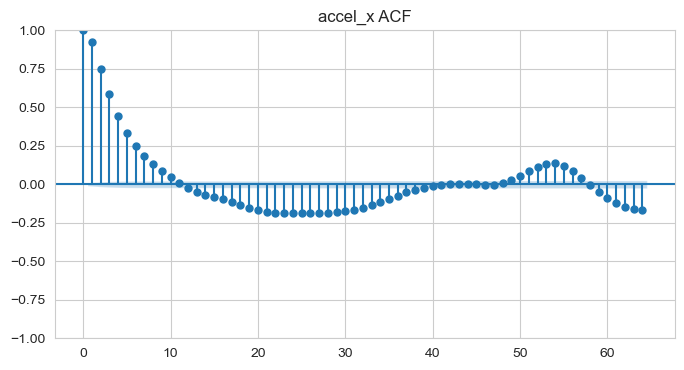


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [ 1.5037 -0.6332]
φ = [ 1.5037 -0.6332]
  Root 1: 0.7519+0.2606j | |z|=0.7958
  Root 2: 0.7519-0.2606j | |z|=0.7958
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


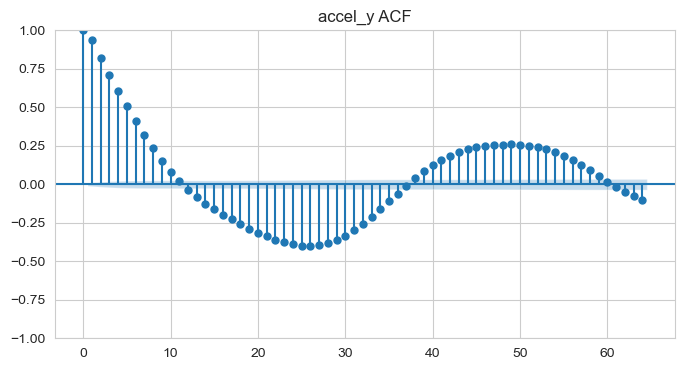


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [ 1.4557 -0.5485]
φ = [ 1.4557 -0.5485]
  Root 1: 0.7279+0.1367j | |z|=0.7406
  Root 2: 0.7279-0.1367j | |z|=0.7406
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


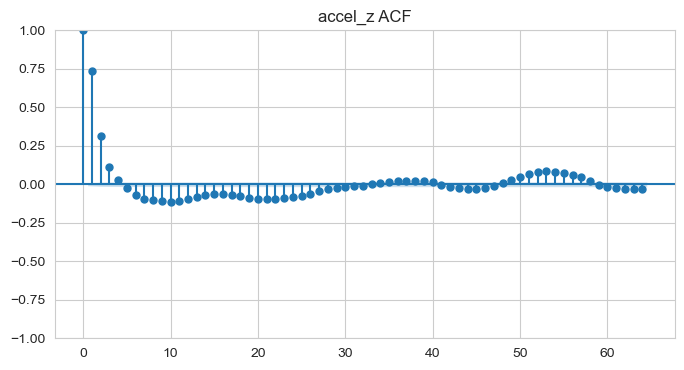


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [ 1.0953 -0.4897]
φ = [ 1.0953 -0.4897]
  Root 1: 0.5476+0.4356j | |z|=0.6998
  Root 2: 0.5476-0.4356j | |z|=0.6998
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


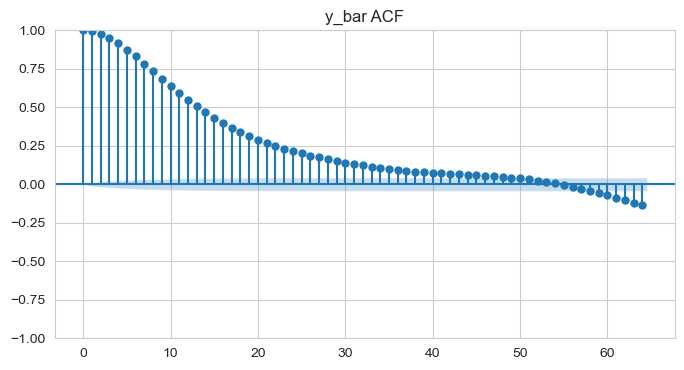


📘 Y_BAR | Estimating φ̂ | AR(2) | User: yaw006
Estimated φ̂ = [ 1.9346 -0.9462]
φ = [ 1.9346 -0.9462]
  Root 1: 0.9673+0.1022j | |z|=0.9727
  Root 2: 0.9673-0.1022j | |z|=0.9727
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.50374128, -0.63322648]),
  'roots': array([0.75187064+0.26060894j, 0.75187064-0.26060894j]),
  'moduli': array([0.79575529, 0.79575529]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.45570792, -0.54847065]),
  'roots': array([0.72785396+0.13674525j, 0.72785396-0.13674525j]),
  'moduli': array([0.74058804, 0.74058804]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.09526437, -0.4896694 ]),
  'roots': array([0.54763218+0.43562414j, 0.54763218-0.43562414j]),
  'moduli': array([0.69976382, 0.69976382]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.93464577, -0.9461614 ]),
  'roots': array([0.96732288+0.10221467j, 0.96732288-0.10221467j]),
  'moduli': array([0.97270828, 0.97270828]),
  'stationary': False}}

In [280]:
arma_stationarity_user(df_diff2_all, activity_walk, random=True)

In [ ]:
# ✅ Ray-safe trim function (redeclared locally)
def trim_edges(df, trim_frac=0.1):
    """
    Trim a fraction (default 10%) off both start and end of a user's data segment.
    Works with wide-format data (ts, accel_x, accel_y, accel_z, y_bar, label, user, activity).
    """
    n = len(df)
    if n < 10:
        return df
    start = int(n * trim_frac)
    end = int(n * (1 - trim_frac))
    return df.iloc[start:end].reset_index(drop=True)


# ✅ Estimate walking cycle period (dominant frequency)
def estimate_walking_period(session, fs=32, sensor_cols=["accel_x", "accel_y", "accel_z"]):
    """Estimate dominant walking cycle period using acceleration magnitude peaks."""
    acc_mag = np.sqrt(np.sum(session[sensor_cols].to_numpy()**2, axis=1))
    peaks, _ = find_peaks(acc_mag, distance=fs/2, prominence=np.std(acc_mag)*0.1)
    if len(peaks) < 2:
        return fs  # fallback ≈ 1s
    avg_period = np.mean(np.diff(peaks))
    return int(np.clip(avg_period, 10, 100))  # reasonable walking range


# ✅ Apply seasonal differencing for one session
def apply_seasonal_difference(session, period, sensor_cols=["accel_x", "accel_y", "accel_z", "y_bar"]):
    """Apply seasonal differencing with given period for each sensor."""
    df_diff = session.copy()
    for sig in sensor_cols:
        df_diff[sig] = df_diff[sig] - df_diff[sig].shift(period)
    return df_diff.dropna().reset_index(drop=True)


# ✅ Full per-user seasonal pipeline
def process_user_seasonal(df, activity_name="Walking-flat-surface",
                          user_id=None, random=True,
                          sample_rate=32, trim_frac=0.1):
    """
    Full pipeline for one user:
    1. Split walking data into sessions (using split_sessions)
    2. Trim edges
    3. Estimate walking period
    4. Apply seasonal differencing
    5. Combine sessions
    """
    sessions, user_id = split_sessions(df, activity_name, user_id, random, sample_rate=sample_rate)
    sensor_cols = ["accel_x", "accel_y", "accel_z", "y_bar"]
    processed = []

    for i, session in enumerate(sessions, 1):
        session = trim_edges(session, trim_frac=trim_frac)
        if len(session) < 50:
            continue

        period = estimate_walking_period(session, fs=sample_rate, sensor_cols=sensor_cols)
        print(f"   👣 User {user_id} | Session {i}: estimated walking period ≈ {period} samples ({period/sample_rate:.2f}s)")

        df_seasonal = apply_seasonal_difference(session, period, sensor_cols=sensor_cols)
        df_seasonal["session_id"] = i
        processed.append(df_seasonal)

    if not processed:
        print(f"⚠️ No usable sessions for {user_id}")
        return pd.DataFrame()

    user_df = pd.concat(processed, ignore_index=True)
    user_df["user"] = user_id
    user_df["activity"] = activity_name
    return user_df


# ✅ Ray remote wrapper (Ray subprocess can now see trim_edges)
@ray.remote
def process_user_remote(df, activity_name, user_id):
    return process_user_seasonal(df, activity_name=activity_name, user_id=user_id, random=False)


def prepare_all_users_seasonal(df, activity_name="Walking-flat-surface", sample_rate=32):
    """Run seasonal differencing for all users (parallelized)."""
    users = df[df["activity"] == activity_name]["user"].unique()
    print(f"⚙️ Processing {len(users)} users...")

    futures = [process_user_remote.remote(df, activity_name, u) for u in users]
    results = ray.get(futures)

    df_all = pd.concat([r for r in results if not r.empty], ignore_index=True)
    print(f"📊 Combined {len(users)} users → {len(df_all)} total samples after seasonal differencing")
    return df_all



In [535]:
df_seasonal = prepare_all_users_seasonal(df_raw, activity_name="Walking-flat-surface", sample_rate=32, d=2)
df_seasonal

⚙️ Processing 31 users... (d=2)
📊 Combined 31 users → 1444039 total samples after differencing (d=2)


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity,session_id
0,1.761523e+12,-0.238209,-0.423825,0.308524,0.001267,2,vbagdi,Walking-flat-surface,1
1,1.761523e+12,-0.004769,-0.066671,1.366998,0.001097,2,vbagdi,Walking-flat-surface,1
2,1.761523e+12,-0.166744,-0.223818,0.745204,0.000842,2,vbagdi,Walking-flat-surface,1
3,1.761523e+12,-0.142920,-0.166673,-0.066451,0.000587,2,vbagdi,Walking-flat-surface,1
4,1.761523e+12,-0.023819,0.080955,-0.365482,0.000332,2,vbagdi,Walking-flat-surface,1
...,...,...,...,...,...,...,...,...,...
1444034,1.760985e+12,1.504487,0.484547,2.826522,0.002078,2,xichen,Walking-flat-surface,1
1444035,1.760985e+12,2.449054,-0.135194,4.272983,0.002434,2,xichen,Walking-flat-surface,1
1444036,1.760985e+12,2.909075,0.524028,3.916453,0.002945,2,xichen,Walking-flat-surface,1
1444037,1.760985e+12,1.645065,0.861416,-0.398405,0.003470,2,xichen,Walking-flat-surface,1


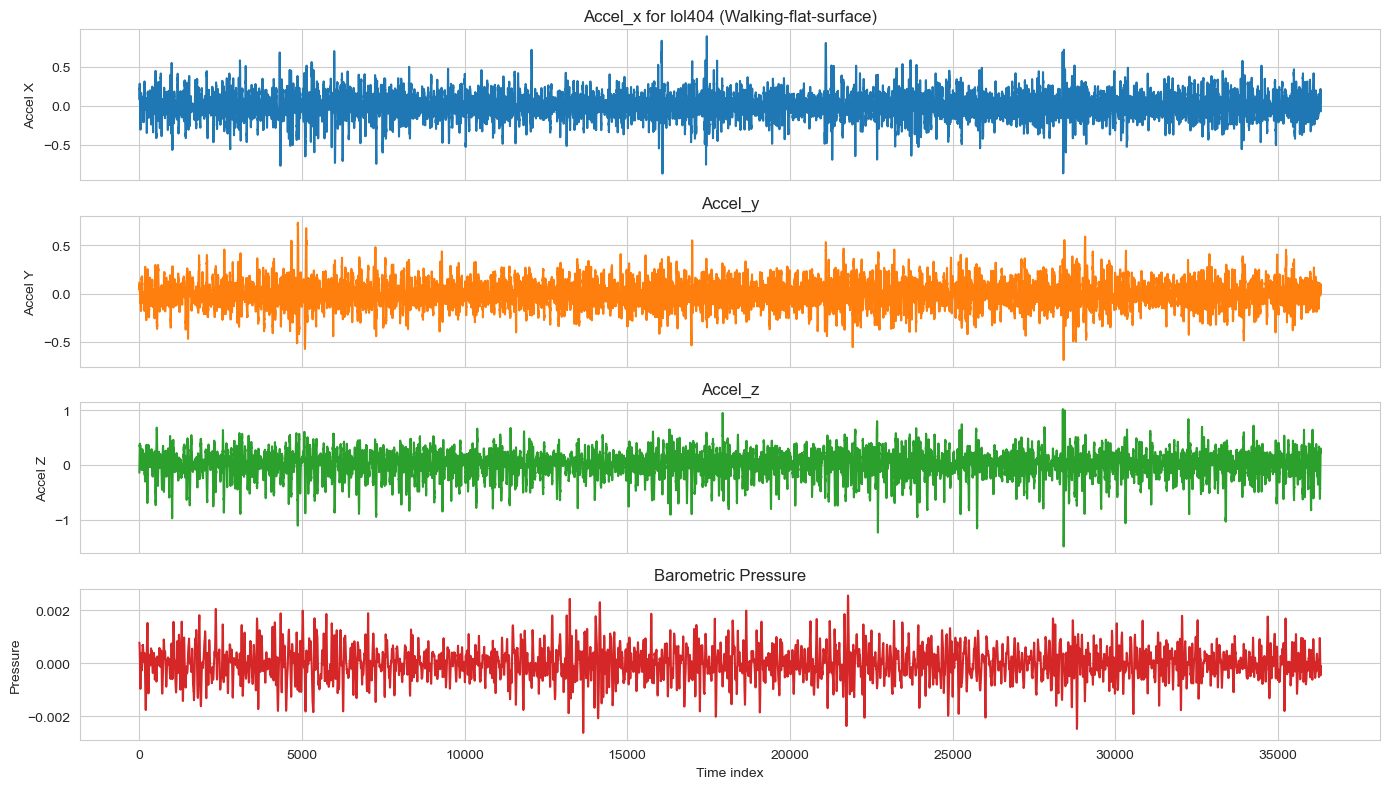

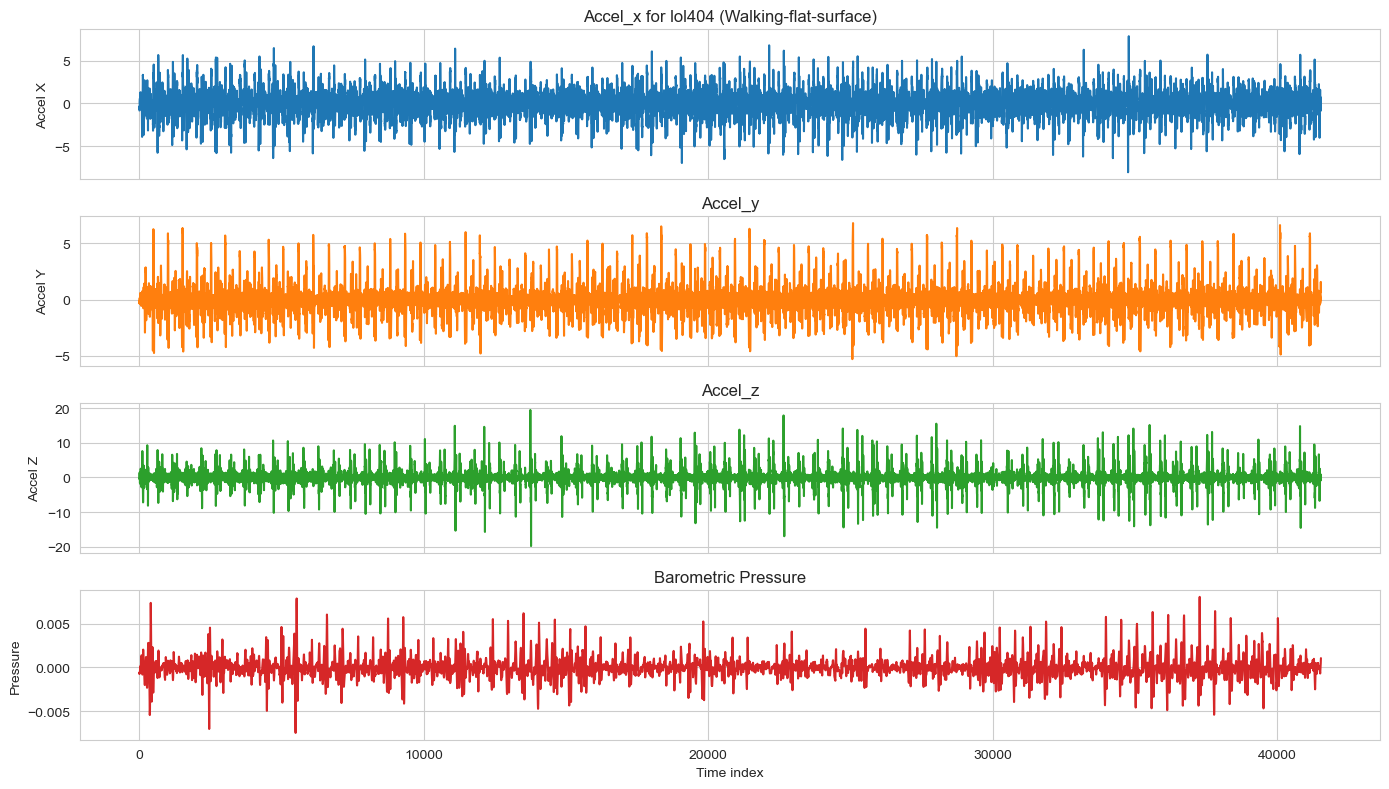

In [536]:
for session in df_seasonal[df_seasonal["user"] == "lol404"]["session_id"].unique():
    df_session = df_seasonal[(df_seasonal["user"] == "lol404") & 
                             (df_seasonal["session_id"] == session)]
    plot_user_activity(df_session, user_id="lol404", random=False)

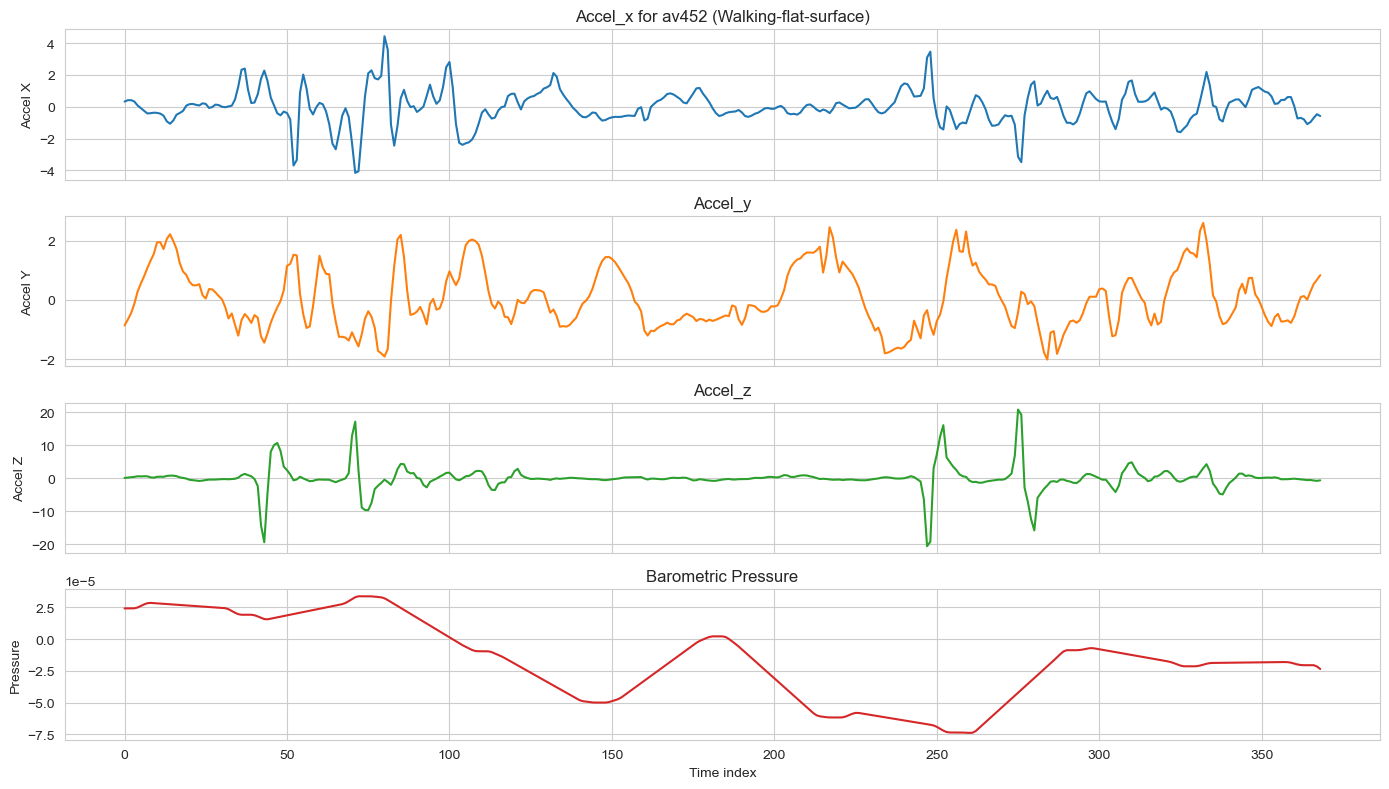

In [564]:
sid = np.random.choice(df_seasonal["session_id"].unique())
df_rand = df_seasonal[df_seasonal["session_id"] == sid]
plot_user_activity(df_rand, user_id=df_rand.user.iat[0], activity_name=df_rand.activity.iat[0], random=False)

In [565]:
df_trimmedSessions["activity"].value_counts()

activity
Walking-flat-surface    1444622
Stationary               992552
Walking-up-stairs        766324
Walking-down-stairs      755221
Running                  673191
Elevator-up              512202
Elevator-down            473243
GYM-Treadmill-6mph        20071
GYM-Treadmill-3mph        13415
GYM-Treadmill-4.5mph      13415
Name: count, dtype: int64


👤 lol404 – Session 1
👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


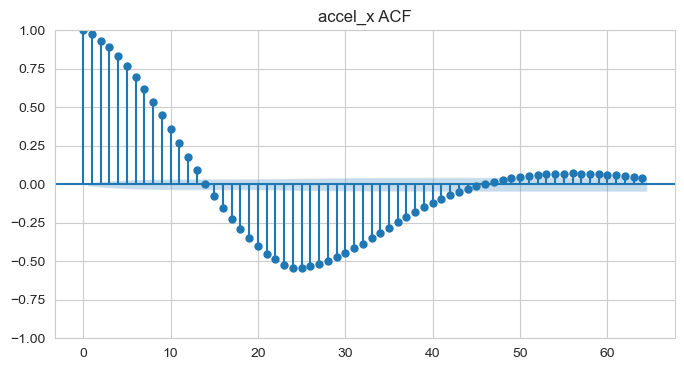


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3283 -0.3623]
φ = [ 1.3283 -0.3623]
  Root 1: 0.9449 | |z|=0.9449
  Root 2: 0.3834 | |z|=0.3834
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


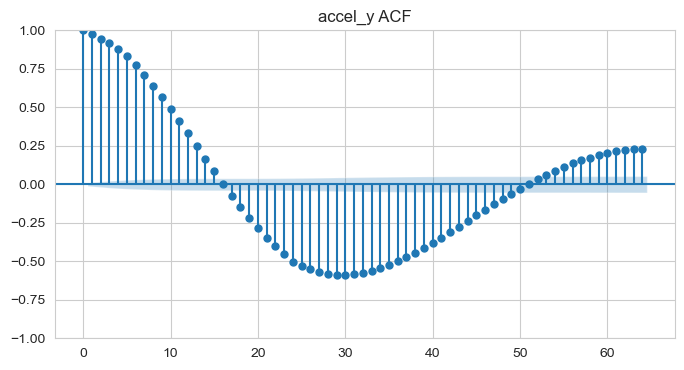


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.1029 -0.1317]
φ = [ 1.1029 -0.1317]
  Root 1: 0.9667 | |z|=0.9667
  Root 2: 0.1362 | |z|=0.1362
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


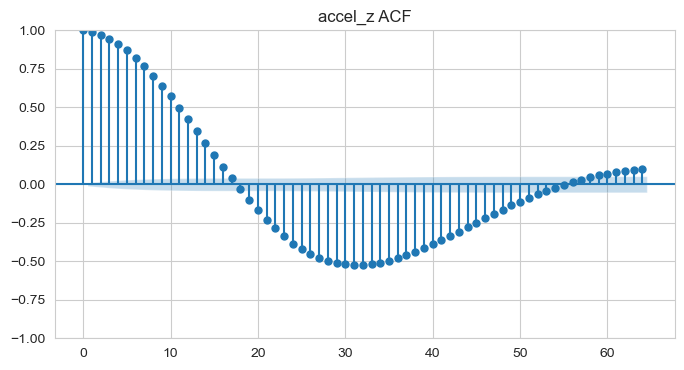


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3206 -0.3374]
φ = [ 1.3206 -0.3374]
  Root 1: 0.9743 | |z|=0.9743
  Root 2: 0.3463 | |z|=0.3463
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


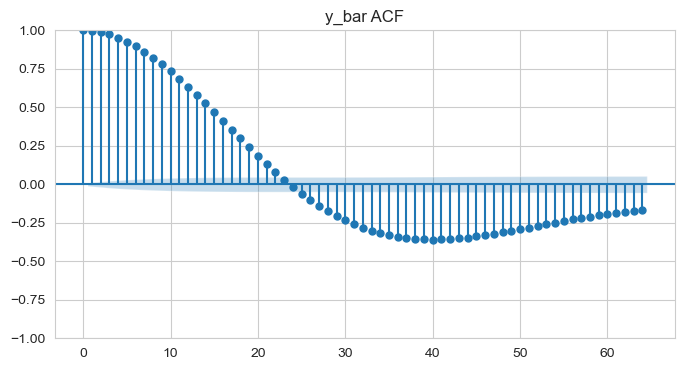


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9771 -0.9832]
φ = [ 1.9771 -0.9832]
  Root 1: 0.9886+0.0774j | |z|=0.9916
  Root 2: 0.9886-0.0774j | |z|=0.9916
⚠️ Non-stationary

👤 lol404 – Session 2
👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


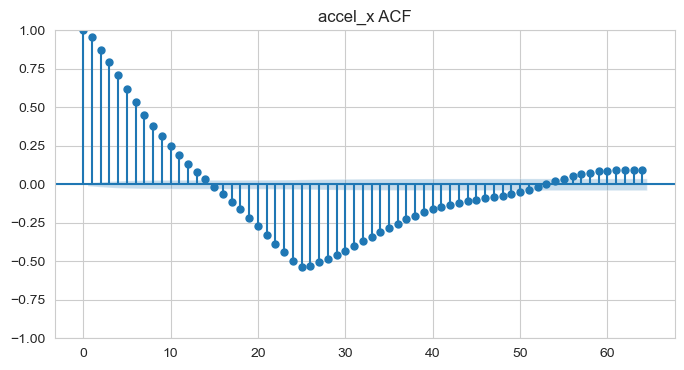


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.3638 -0.4292]
φ = [ 1.3638 -0.4292]
  Root 1: 0.8711 | |z|=0.8711
  Root 2: 0.4926 | |z|=0.4926
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


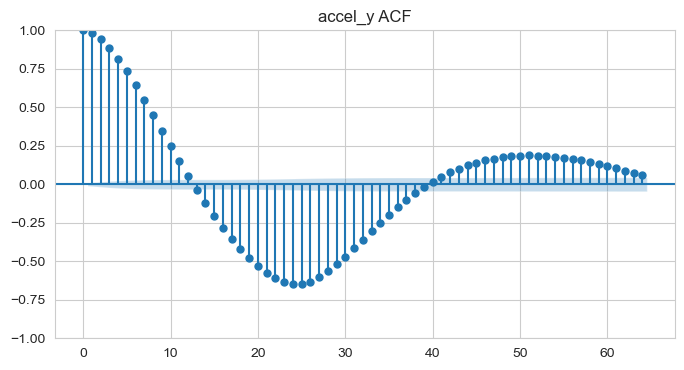


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.7154 -0.7443]
φ = [ 1.7154 -0.7443]
  Root 1: 0.8577+0.0930j | |z|=0.8627
  Root 2: 0.8577-0.0930j | |z|=0.8627
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


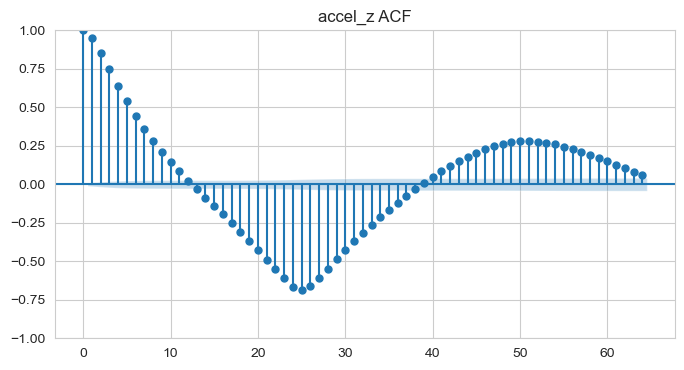


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.4897 -0.5664]
φ = [ 1.4897 -0.5664]
  Root 1: 0.7448+0.1076j | |z|=0.7526
  Root 2: 0.7448-0.1076j | |z|=0.7526
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


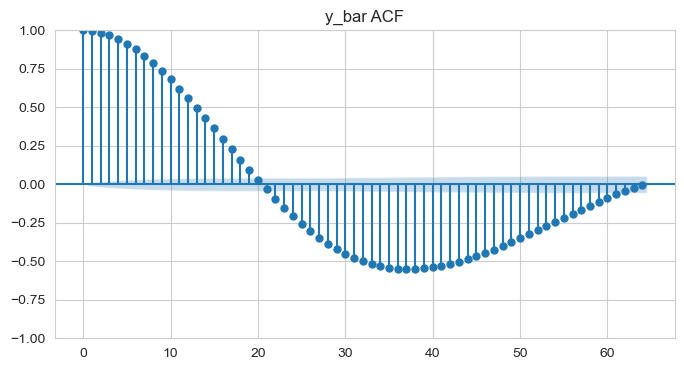


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9762 -0.9835]
φ = [ 1.9762 -0.9835]
  Root 1: 0.9881+0.0849j | |z|=0.9917
  Root 2: 0.9881-0.0849j | |z|=0.9917
⚠️ Non-stationary


In [364]:
for session in df_seasonal[df_seasonal["user"] == "lol404"]["session_id"].unique():
    df_session = df_seasonal[(df_seasonal["user"] == "lol404") &
                             (df_seasonal["session_id"] == session)]
    print(f"\n👤 lol404 – Session {session}")
    arma_stationarity_user(df_session, activity_name="Walking-flat-surface",
                           user_id="lol404", random=False)


🎲 Random user: bl4521 – Session 1
👤 Using specified user: bl4521

📈 ACF for ACCEL_X | 64 lags (auto)


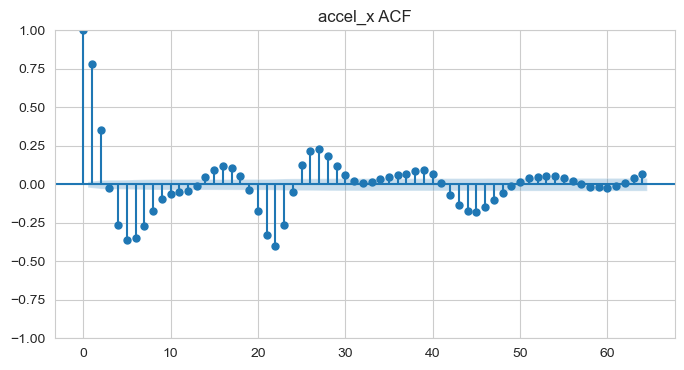


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: bl4521
Estimated φ̂ = [ 1.3115 -0.6749]
φ = [ 1.3115 -0.6749]
  Root 1: 0.6558+0.4948j | |z|=0.8215
  Root 2: 0.6558-0.4948j | |z|=0.8215
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


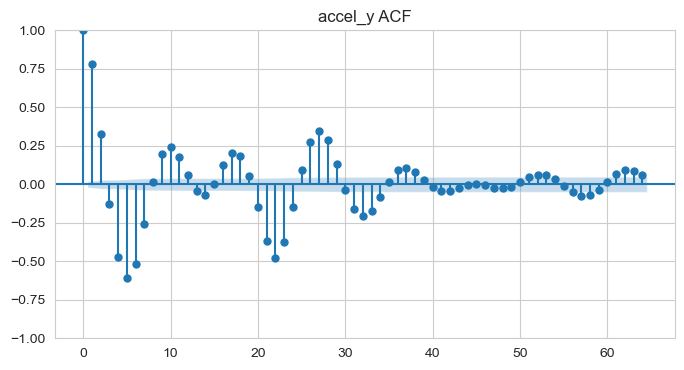


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: bl4521
Estimated φ̂ = [ 1.3679 -0.7446]
φ = [ 1.3679 -0.7446]
  Root 1: 0.6839+0.5261j | |z|=0.8629
  Root 2: 0.6839-0.5261j | |z|=0.8629
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


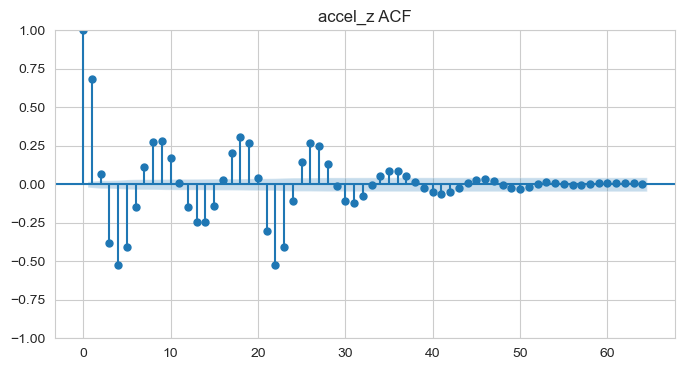


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: bl4521
Estimated φ̂ = [ 1.1846 -0.7409]
φ = [ 1.1846 -0.7409]
  Root 1: 0.5923+0.6245j | |z|=0.8607
  Root 2: 0.5923-0.6245j | |z|=0.8607
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


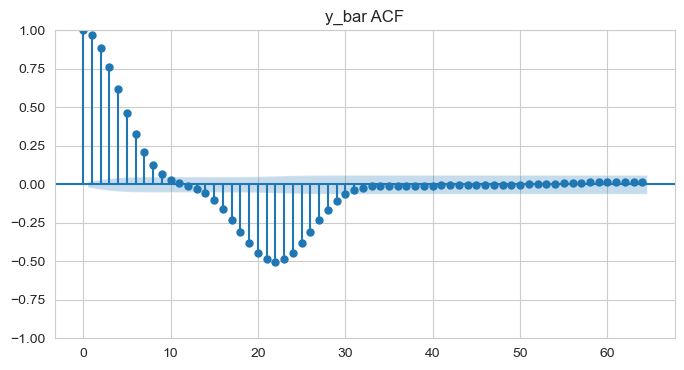


📘 Y_BAR | Estimating φ̂ | AR(2) | User: bl4521
Estimated φ̂ = [ 1.8588 -0.917 ]
φ = [ 1.8588 -0.917 ]
  Root 1: 0.9294+0.2308j | |z|=0.9576
  Root 2: 0.9294-0.2308j | |z|=0.9576
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.31153116, -0.67485649]),
  'roots': array([0.65576558+0.49480096j, 0.65576558-0.49480096j]),
  'moduli': array([0.82149649, 0.82149649]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.36788881, -0.74456943]),
  'roots': array([0.6839444+0.52610786j, 0.6839444-0.52610786j]),
  'moduli': array([0.86288437, 0.86288437]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.18462171, -0.74088426]),
  'roots': array([0.59231086+0.62454152j, 0.59231086-0.62454152j]),
  'moduli': array([0.86074634, 0.86074634]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.85878239, -0.91704933]),
  'roots': array([0.9293912+0.23082749j, 0.9293912-0.23082749j]),
  'moduli': array([0.95762692, 0.95762692]),
  'stationary': False}}

In [371]:
# --- Run Brockwell test for one random user/session ---
user_rand = np.random.choice(df_seasonal["user"].unique())
session_rand = np.random.choice(df_seasonal[df_seasonal["user"] == user_rand]["session_id"].unique())
df_rand = df_seasonal[(df_seasonal["user"] == user_rand) &
                      (df_seasonal["session_id"] == session_rand)]

print(f"\n🎲 Random user: {user_rand} – Session {session_rand}")
arma_stationarity_user(df_rand, activity_name="Walking-flat-surface",
                       user_id=user_rand, random=False)


👤 lol404 – Session 1
👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


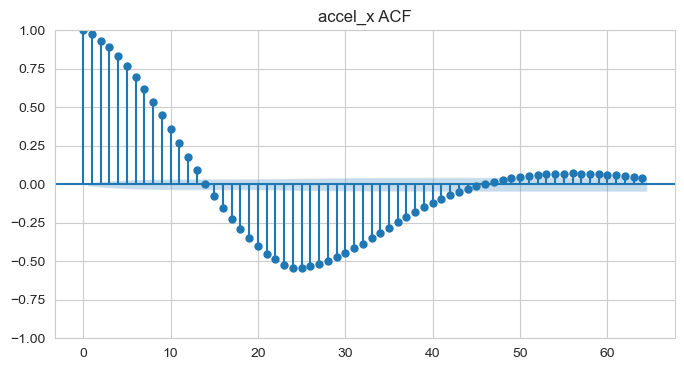


📘 ACCEL_X | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.3856 -0.6405  0.5885 -0.3767]
φ = [ 1.3856 -0.6405  0.5885 -0.3767]
  Root 1: -0.1771+0.6799j | |z|=0.7026
  Root 2: -0.1771-0.6799j | |z|=0.7026
  Root 3: 0.8699+0.0801j | |z|=0.8736
  Root 4: 0.8699-0.0801j | |z|=0.8736
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


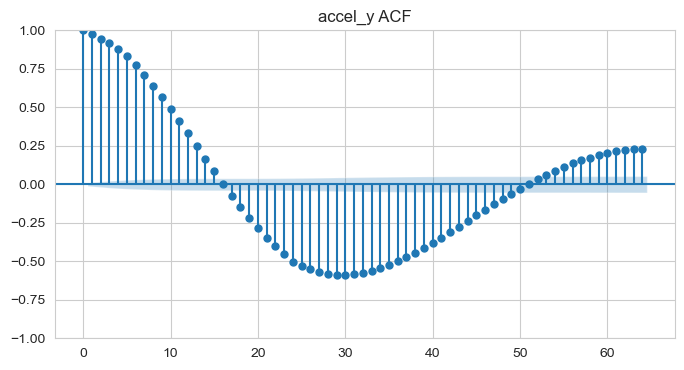


📘 ACCEL_Y | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.1942 -0.4473  0.6318 -0.4125]
φ = [ 1.1942 -0.4473  0.6318 -0.4125]
  Root 1: -0.2492+0.7210j | |z|=0.7629
  Root 2: -0.2492-0.7210j | |z|=0.7629
  Root 3: 0.9323+0.0000j | |z|=0.9323
  Root 4: 0.7603+0.0000j | |z|=0.7603
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


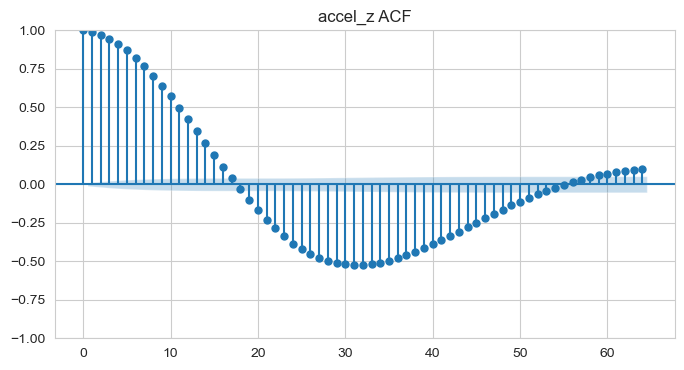


📘 ACCEL_Z | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.3399 -0.5403  0.6395 -0.4631]
φ = [ 1.3399 -0.5403  0.6395 -0.4631]
  Root 1: 0.9035+0.0499j | |z|=0.9049
  Root 2: 0.9035-0.0499j | |z|=0.9049
  Root 3: -0.2336+0.7149j | |z|=0.7521
  Root 4: -0.2336-0.7149j | |z|=0.7521
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


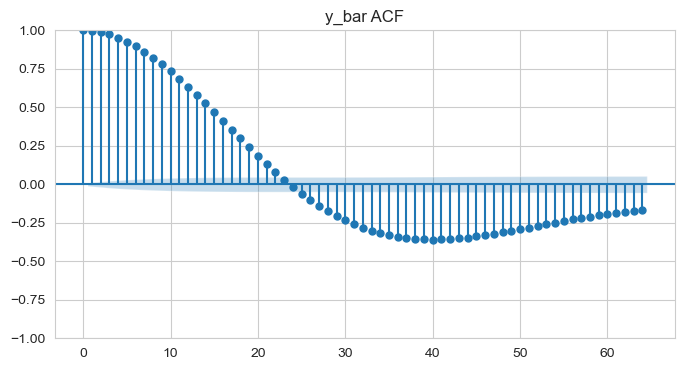


📘 Y_BAR | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 2.6699 -2.687   1.335  -0.3218]
φ = [ 2.6699 -2.687   1.335  -0.3218]
  Root 1: 0.9830+0.0759j | |z|=0.9860
  Root 2: 0.9830-0.0759j | |z|=0.9860
  Root 3: 0.3519+0.4551j | |z|=0.5753
  Root 4: 0.3519-0.4551j | |z|=0.5753
⚠️ Non-stationary

👤 lol404 – Session 2
👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


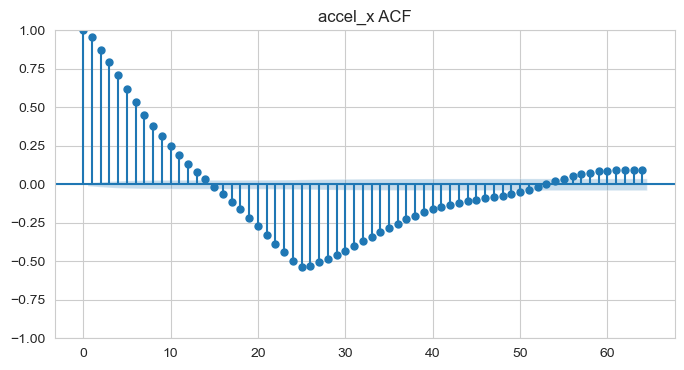


📘 ACCEL_X | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.5349 -0.9827  0.7238 -0.3445]
φ = [ 1.5349 -0.9827  0.7238 -0.3445]
  Root 1: -0.0634+0.6966j | |z|=0.6995
  Root 2: -0.0634-0.6966j | |z|=0.6995
  Root 3: 0.8309+0.1173j | |z|=0.8391
  Root 4: 0.8309-0.1173j | |z|=0.8391
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


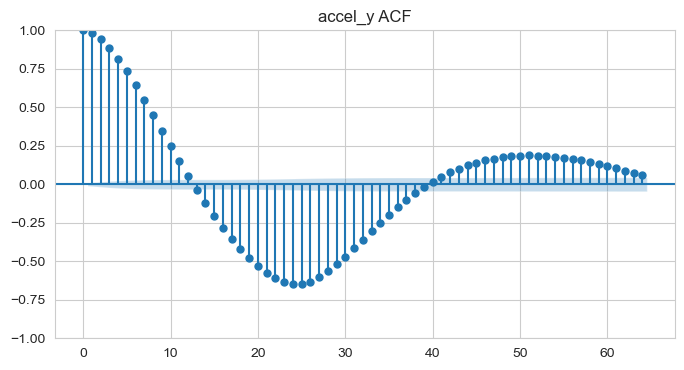


📘 ACCEL_Y | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.8176 -1.255   0.7985 -0.3979]
φ = [ 1.8176 -1.255   0.7985 -0.3979]
  Root 1: 0.9302+0.1406j | |z|=0.9408
  Root 2: 0.9302-0.1406j | |z|=0.9408
  Root 3: -0.0214+0.6701j | |z|=0.6705
  Root 4: -0.0214-0.6701j | |z|=0.6705
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


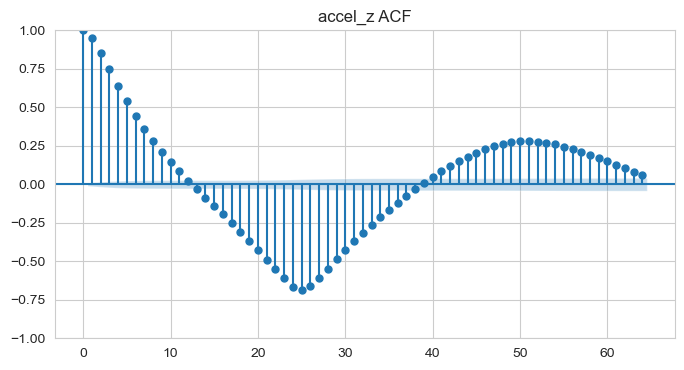


📘 ACCEL_Z | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 1.739  -1.3005  0.8081 -0.3194]
φ = [ 1.739  -1.3005  0.8081 -0.3194]
  Root 1: 0.8265+0.1520j | |z|=0.8404
  Root 2: 0.8265-0.1520j | |z|=0.8404
  Root 3: 0.0430+0.6711j | |z|=0.6724
  Root 4: 0.0430-0.6711j | |z|=0.6724
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


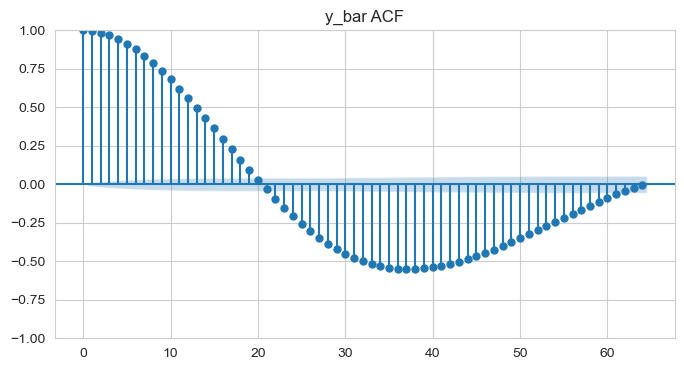


📘 Y_BAR | Estimating φ̂ | AR(4) | User: lol404
Estimated φ̂ = [ 2.7995 -3.0905  1.7556 -0.4693]
φ = [ 2.7995 -3.0905  1.7556 -0.4693]
  Root 1: 0.9858+0.0836j | |z|=0.9893
  Root 2: 0.9858-0.0836j | |z|=0.9893
  Root 3: 0.4140+0.5551j | |z|=0.6924
  Root 4: 0.4140-0.5551j | |z|=0.6924
⚠️ Non-stationary


In [370]:
for session in df_seasonal[df_seasonal["user"] == "lol404"]["session_id"].unique():
    df_session = df_seasonal[(df_seasonal["user"] == "lol404") &
                             (df_seasonal["session_id"] == session)]
    print(f"\n👤 lol404 – Session {session}")
    arma_stationarity_user(df_session, activity_name="Walking-flat-surface",
                           user_id="lol404", random=False, p=4)


🎲 Random user: cgp46 – Session 5
👤 Using specified user: cgp46

📈 ACF for ACCEL_X | 64 lags (auto)


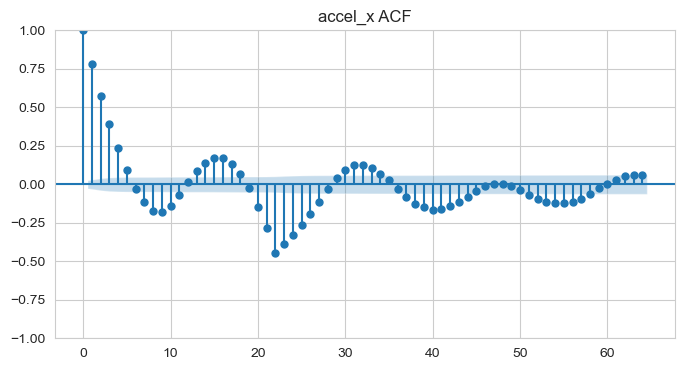


📘 ACCEL_X | Estimating φ̂ | AR(10) | User: cgp46
Estimated φ̂ = [ 0.8145 -0.0187 -0.0223  0.0034 -0.0099 -0.0638 -0.0063 -0.042  -0.0329
  0.0685]
φ = [ 0.8145 -0.0187 -0.0223  0.0034 -0.0099 -0.0638 -0.0063 -0.042  -0.0329
  0.0685]
  Root 1: 0.7977+0.3229j | |z|=0.8606
  Root 2: 0.7977-0.3229j | |z|=0.8606
  Root 3: 0.7338+0.0000j | |z|=0.7338
  Root 4: 0.3336+0.6986j | |z|=0.7742
  Root 5: 0.3336-0.6986j | |z|=0.7742
  Root 6: -0.1522+0.7283j | |z|=0.7441
  Root 7: -0.1522-0.7283j | |z|=0.7441
  Root 8: -0.5891+0.4426j | |z|=0.7369
  Root 9: -0.5891-0.4426j | |z|=0.7369
  Root 10: -0.6994+0.0000j | |z|=0.6994
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


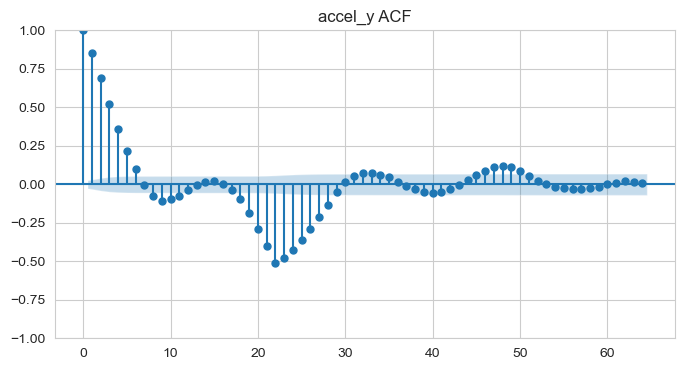


📘 ACCEL_Y | Estimating φ̂ | AR(10) | User: cgp46
Estimated φ̂ = [ 9.167e-01 -6.500e-03 -2.310e-02 -9.130e-02  2.810e-02  2.010e-02
 -5.500e-02 -6.210e-02 -8.000e-04  6.640e-02]
φ = [ 9.167e-01 -6.500e-03 -2.310e-02 -9.130e-02  2.810e-02  2.010e-02
 -5.500e-02 -6.210e-02 -8.000e-04  6.640e-02]
  Root 1: 0.8014+0.3120j | |z|=0.8600
  Root 2: 0.8014-0.3120j | |z|=0.8600
  Root 3: 0.8034+0.0000j | |z|=0.8034
  Root 4: 0.3657+0.7037j | |z|=0.7930
  Root 5: 0.3657-0.7037j | |z|=0.7930
  Root 6: -0.2219+0.7004j | |z|=0.7347
  Root 7: -0.2219-0.7004j | |z|=0.7347
  Root 8: -0.5498+0.4280j | |z|=0.6967
  Root 9: -0.5498-0.4280j | |z|=0.6967
  Root 10: -0.6777+0.0000j | |z|=0.6777
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


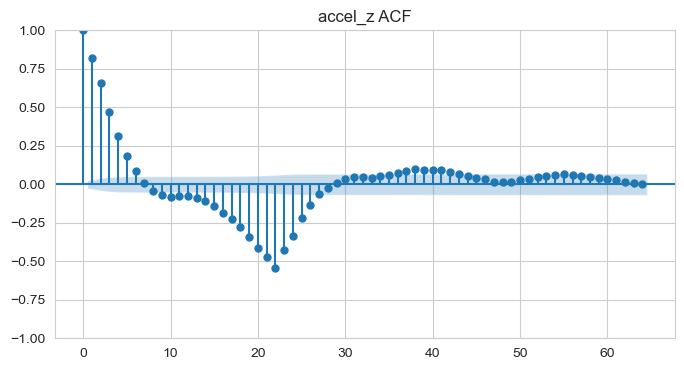


📘 ACCEL_Z | Estimating φ̂ | AR(10) | User: cgp46
Estimated φ̂ = [ 0.8282  0.111  -0.1222 -0.0471 -0.0011  0.0172 -0.0083 -0.0409  0.0037
  0.0124]
φ = [ 0.8282  0.111  -0.1222 -0.0471 -0.0011  0.0172 -0.0083 -0.0409  0.0037
  0.0124]
  Root 1: 0.7602+0.2407j | |z|=0.7974
  Root 2: 0.7602-0.2407j | |z|=0.7974
  Root 3: 0.3464+0.5812j | |z|=0.6766
  Root 4: 0.3464-0.5812j | |z|=0.6766
  Root 5: 0.5757+0.0000j | |z|=0.5757
  Root 6: -0.2085+0.6118j | |z|=0.6463
  Root 7: -0.2085-0.6118j | |z|=0.6463
  Root 8: -0.5181+0.2835j | |z|=0.5906
  Root 9: -0.5181-0.2835j | |z|=0.5906
  Root 10: -0.5076+0.0000j | |z|=0.5076
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


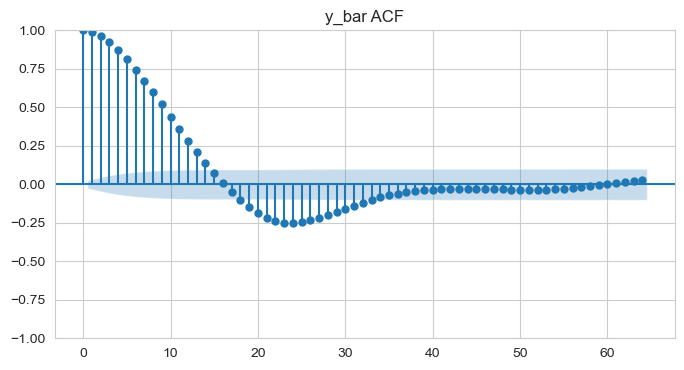


📘 Y_BAR | Estimating φ̂ | AR(10) | User: cgp46
Estimated φ̂ = [ 2.1382 -1.4476  0.3796 -0.1182  0.1067 -0.3633  0.4907 -0.1325 -0.1052
  0.0358]
φ = [ 2.1382 -1.4476  0.3796 -0.1182  0.1067 -0.3633  0.4907 -0.1325 -0.1052
  0.0358]
  Root 1: 0.9547+0.1113j | |z|=0.9611
  Root 2: 0.9547-0.1113j | |z|=0.9611
  Root 3: 0.7027+0.4202j | |z|=0.8187
  Root 4: 0.7027-0.4202j | |z|=0.8187
  Root 5: 0.0683+0.8288j | |z|=0.8316
  Root 6: 0.0683-0.8288j | |z|=0.8316
  Root 7: -0.6096+0.4630j | |z|=0.7655
  Root 8: -0.6096-0.4630j | |z|=0.7655
  Root 9: -0.4275+0.0000j | |z|=0.4275
  Root 10: 0.3337+0.0000j | |z|=0.3337
⚠️ Non-stationary


{'accel_x': {'phi': array([ 0.81454026, -0.01867121, -0.02232938,  0.00344793, -0.0098824 ,
         -0.06379165, -0.00629307, -0.04201389, -0.03292419,  0.06848599]),
  'roots': array([ 0.79774599+0.32288388j,  0.79774599-0.32288388j,
          0.73383723+0.j        ,  0.33360328+0.69858561j,
          0.33360328-0.69858561j, -0.15219239+0.72832758j,
         -0.15219239-0.72832758j, -0.58908115+0.44264871j,
         -0.58908115-0.44264871j, -0.69944842+0.j        ]),
  'moduli': array([0.8606118 , 0.8606118 , 0.73383723, 0.77415309, 0.77415309,
         0.74405887, 0.74405887, 0.73685445, 0.73685445, 0.69944842]),
  'stationary': False},
 'accel_y': {'phi': array([ 9.16716080e-01, -6.52608115e-03, -2.31256661e-02, -9.12838128e-02,
          2.80709520e-02,  2.01291696e-02, -5.49700992e-02, -6.21493855e-02,
         -7.83418081e-04,  6.63551363e-02]),
  'roots': array([ 0.80139793+0.31200831j,  0.80139793-0.31200831j,
          0.80344411+0.j        ,  0.36573722+0.70366919j,
        

In [341]:
# --- Run Brockwell test for one random user/session ---
user_rand = np.random.choice(df_seasonal["user"].unique())
session_rand = np.random.choice(df_seasonal[df_seasonal["user"] == user_rand]["session_id"].unique())
df_rand = df_seasonal[(df_seasonal["user"] == user_rand) &
                      (df_seasonal["session_id"] == session_rand)]

print(f"\n🎲 Random user: {user_rand} – Session {session_rand}")
arma_stationarity_user(df_rand, activity_name="Walking-flat-surface",
                       user_id=user_rand, random=False, p=10)

In [380]:

# --- Brockwell root condition (exact from your version)
def brockwell_root_condition(phi):
    phi = np.asarray(phi, float)
    coeffs = np.concatenate(([1], -phi))
    roots = np.roots(coeffs)
    moduli = np.abs(roots)
    stationary = np.all(moduli > 1)
    return {"roots": roots, "moduli": moduli, "stationary": stationary}

# --- Ray worker: fit ARIMA(p,0,q) and compute φ roots
@ray.remote
def fit_arma_roots_remote(series, p, q):
    """Fit ARIMA(p,0,q) and return Brockwell roots for AR component."""
    try:
        if len(series) < max(p, q) + 5:
            return None
        model = ARIMA(series, order=(p, 0, q)).fit(method="innovations_mle")
        phi = model.arparams if hasattr(model, "arparams") else np.array([])
        if len(phi) == 0:
            return None
        res = brockwell_root_condition(phi)
        return {
            "phi": phi.tolist(),
            "min_root_mod": float(np.min(np.abs(res["moduli"]))),
            "stationary": bool(res["stationary"]),
        }
    except Exception:
        return None

# --- Main tuner (parallel grid)
def tune_arma_by_roots(
    df,
    activity_name="Walking-flat-surface",
    user_id=None,
    random=True,
    p_list=(1, 2, 3, 4, 5),
    q_list=(0, 1, 2, 3),
    sensors=("accel_x", "accel_y", "accel_z", "y_bar"),
):
    """
    Parallel Brockwell tuner: each (p,q) row, sensors as columns.
    Computes min root modulus & stationarity for each sensor.
    """
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True, log_to_driver=False)

    # Pick user
    if random or user_id is None:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"🎲 Randomly selected user: {user_id}")
    else:
        print(f"👤 Using specified user: {user_id}")

    dsub = df[(df["user"] == user_id) & (df["activity"] == activity_name)]
    results = []

    for p in p_list:
        for q in q_list:
            futures = {}
            for sig in sensors:
                series = dsub[sig].dropna().values
                futures[sig] = fit_arma_roots_remote.remote(series, p, q)
            sensor_results = ray.get(list(futures.values()))

            row = {"user": user_id, "activity": activity_name, "p": p, "q": q}
            for sig, res in zip(sensors, sensor_results):
                if res is None:
                    row[f"{sig}_root"] = np.nan
                    row[f"{sig}_stationary"] = False
                else:
                    row[f"{sig}_root"] = res["min_root_mod"]
                    row[f"{sig}_stationary"] = res["stationary"]
            results.append(row)

    df_out = pd.DataFrame(results)
    print(f"✅ Finished {len(df_out)} (p,q) tests for {user_id}")
    return df_out


In [381]:
lst_p = [1, 2, 3, 4, 5]
lst_q = [0, 1, 2, 3]

df_qTune = tune_arma_by_roots(
                                df_seasonal,
                                activity_name="Walking-flat-surface",
                                user_id=my_netid,
                                p_list=lst_p,
                                q_list=lst_q,
                                random=False
)
df_qTune

👤 Using specified user: lol404
✅ Finished 20 (p,q) tests for lol404


,user,activity,p,q,accel_x_root,accel_x_stationary,accel_y_root,accel_y_stationary,accel_z_root,accel_z_stationary,y_bar_root,y_bar_stationary
0,lol404,Walking-flat-surface,1,0,0.954480,False,0.983351,False,0.951510,False,0.996400,False
1,lol404,Walking-flat-surface,1,1,0.899145,False,0.973910,False,0.914788,False,0.999997,False
2,lol404,Walking-flat-surface,1,2,0.919415,False,0.964755,False,0.890508,False,0.999998,False
3,lol404,Walking-flat-surface,1,3,0.916224,False,0.957328,False,0.890187,False,0.994329,False
4,lol404,Walking-flat-surface,2,0,0.491482,False,0.858066,False,0.751839,False,0.991526,False
5,lol404,Walking-flat-surface,2,1,0.109142,False,0.296641,False,0.158319,False,0.984844,False
6,lol404,Walking-flat-surface,2,2,0.070046,False,0.982146,False,0.960445,False,0.980185,False
7,lol404,Walking-flat-surface,2,3,0.968673,False,0.977236,False,0.955160,False,0.981515,False
8,lol404,Walking-flat-surface,3,0,0.487150,False,0.118021,False,0.557240,False,0.573946,False
9,lol404,Walking-flat-surface,3,1,0.128911,False,0.438037,False,0.068238,False,0.180047,False


In [383]:
df_qTune = tune_arma_by_roots(
    df_seasonal,
    activity_name="Walking-flat-surface",
    p_list=lst_p,
    q_list=lst_q,
    random=True
)
df_qTune

🎲 Randomly selected user: nk428
✅ Finished 20 (p,q) tests for nk428


,user,activity,p,q,accel_x_root,accel_x_stationary,accel_y_root,accel_y_stationary,accel_z_root,accel_z_stationary,y_bar_root,y_bar_stationary
0,nk428,Walking-flat-surface,1,0,0.808270,False,0.760273,False,0.709065,False,0.996003,False
1,nk428,Walking-flat-surface,1,1,0.592182,False,0.389592,False,0.369814,False,0.994683,False
2,nk428,Walking-flat-surface,1,2,0.648733,False,0.712788,False,0.537430,False,0.992775,False
3,nk428,Walking-flat-surface,1,3,0.581592,False,0.617087,False,0.495057,False,0.990163,False
4,nk428,Walking-flat-surface,2,0,0.661882,False,0.525614,False,0.589143,False,0.950828,False
5,nk428,Walking-flat-surface,2,1,0.096745,False,0.352913,False,0.160277,False,0.941995,False
6,nk428,Walking-flat-surface,2,2,0.771978,False,0.282884,False,0.458389,False,0.933676,False
7,nk428,Walking-flat-surface,2,3,0.860152,False,0.926625,False,0.860056,False,0.925705,False
8,nk428,Walking-flat-surface,3,0,0.558392,False,0.520574,False,0.553962,False,0.111499,False
9,nk428,Walking-flat-surface,3,1,0.274423,False,0.236928,False,0.246873,False,0.609548,False


TO DO
 
Do you see any interesting trends while observing signals from different activities (like walking, running stationary) ? Explain what you see. 
Can you think of any specific feature that might help us to differentiate among different activities? You will write a paragraph on this.

Comparing walking to running, the accelerometer signal during running is much more jagged, while the walking signal appears smoother and more rhythmic. This suggests that measures of dispersion—such as the range between peaks and troughs—could help distinguish between these activities. In particular, variations along the z-axis (vertical motion) seem especially informative since running involves more pronounced vertical oscillations. I forgot to collect the stationary data, my mistake, I did all the others, but I expect it to show minimal variation and very low amplitude compared to the others.

In [ ]:
x_list_train = []
y_list_train = []
z_list_train = []
b_list_train = []
train_labels = []
train_participants = []

# TO DO
# Similarly create test list
x_list_test = []
y_list_test = []
z_list_test = []
b_list_test = []
test_labels = []
test_participants = []


# Setting window size of 100 datapoints with an overlap of 50%
window_size = 100
step_size = 50